# **Medical Application and Healthcare:**
### Analysis of Migraine Subjects’ MMDs Changes and treatments response.

BSc in Artficial Intelligence

University of Pavia, University of Milano "La Statale" and University of Milano-Bicocca

**Authors:**
- Claudia Maria Carboni
- Susanna Mazzocchi
- Carlotta Zanei

# ***Tasks 0 and 1: Descriptive Analyses and Preprocessing***
by Claudia Maria Carboni
- Task 0: Exploration (baseline, longitudinal trends, discontinuations)
- Task 1: Missing data assessment and imputation (baseline & longitudinal)

-------------------------------------------

In [ ]:
from pathlib import Path
import os

# Set project root to the folder that contains this notebook
# (works even when VS Code cannot "Open Folder")
NOTEBOOK_DIR = Path.cwd()
print("Current working directory:", NOTEBOOK_DIR)

# If CSVs are not found here, try the Downloads/Task3 folder (your known location)
candidates = [
    NOTEBOOK_DIR,
    Path.home() / "Downloads" / "Task3_Migraine_Phenotyping",
]

data_dir = None
for p in candidates:
    if (p / "MigraineBaselineVars.csv").exists() and (p / "MigraineLongitudianlVars.csv").exists():
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError(
        "Could not locate CSV files. Checked:\n" + "\n".join(str(p) for p in candidates)
    )

os.chdir(data_dir)
print("Data directory set to:", Path.cwd())
print("Files:", [x.name for x in Path.cwd().iterdir()])


Current working directory: /Users/claudiacarboni/Downloads/medical
Data directory set to: /Users/claudiacarboni/Downloads/medical
Files: ['confounder_analysis_complete.csv', '04_comorbidities_distribution.png', 'task4_km_antibodies_corrected.png', 'df_long_imputed.csv', '.DS_Store', 'task4_final_stratified_forest_plot.png', '07_dropouts_discontinuations.png', 'MigraineLongitudianlVars.csv', 'confounders_significant_dashboard.png', 'discontinuation_reasons.csv', 'baseline_imputation_comparison.csv', 'ph_assumption_test_results.csv', 'MigraineBaselineVars.csv', 'confounders_dashboard.png', 'task0_missing_pattern.png', '05_longitudinal_trends_MMDs.png', 'task4_longitudinal_trends_final.png', '.venv', '02_sex_distribution.png', '03_diagnosis_distribution.png', 'discontinuation_reasons_detailed.csv', 'Migraine_Analysis - Copia (2).ipynb', '.qodo', '01_age_distribution.png', 'Migraine_Analysis - Copia.ipynb', 'mice_convergence_diagnostics.csv', 'task4_cif_competing_risks.png', 'project 1.ipy

 ## **0. Environment Setup, Data Loading, and Advanced Imputation**

In [ ]:
%pip install -q \
    numpy pandas scipy matplotlib seaborn \
    scikit-learn scikit-survival imbalanced-learn \
    lifelines statsmodels missingno \
    networkx graphviz shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Core scientific stack
import numpy as np
import pandas as pd
import scipy.stats as stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Survival analysis
from lifelines import CoxPHFitter, KaplanMeierFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, pairwise_logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.plotting import add_at_risk_counts
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Statistical models
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr, chi2_contingency, ttest_ind

# Graphs and explainability
import networkx as nx
import shap

----------------------------------------------------

## **1. Data Loading and Preprocessing**

We load the baseline and longitudinal datasets, correct known typographical errors in column names (e.g., weight and height), and standardize the SUBJECT_ID format to ensure consistency and enable reliable dataset merging.

In [ ]:
df_baseline = pd.read_csv('MigraineBaselineVars.csv', sep=';', na_values=['NA', 'nan', ''])
df_long = pd.read_csv('MigraineLongitudianlVars.csv', sep=';', na_values=['NA', 'nan', ''])

df_baseline.columns = df_baseline.columns.str.strip()
df_long.columns = df_long.columns.str.strip()

df_baseline = df_baseline.rename(columns={'WEIGTH': 'WEIGHT', 'HEIGTH': 'HEIGHT'})

def fix_height_m(height):
    if pd.isna(height):
        return np.nan
    if 100 <= height <= 250:
        return height / 100.0
    if 1.0 <= height <= 2.5:
        return height
    return np.nan

if 'HEIGHT' in df_baseline.columns:
    df_baseline['HEIGHT'] = df_baseline['HEIGHT'].apply(fix_height_m)

if {'WEIGHT', 'HEIGHT'}.issubset(df_baseline.columns):
    mask_valid = df_baseline['WEIGHT'].between(30, 300) & df_baseline['HEIGHT'].between(1.4, 2.2)

    df_baseline.loc[mask_valid, 'BMI'] = df_baseline.loc[mask_valid, 'WEIGHT'] / (df_baseline.loc[mask_valid, 'HEIGHT']**2)

    df_baseline.loc[~mask_valid, 'BMI'] = np.nan

df_baseline['SUBJECT_ID'] = df_baseline['SUBJECT_ID'].astype(str).str.strip()
df_long['SUBJECT_ID'] = df_long['SUBJECT_ID'].astype(str).str.strip()
# df_long.loc[df_long['INT'] > 10, 'INT'] = np.nan

if 'INT_T0' in df_baseline.columns:
    df_baseline.loc[df_baseline['INT_T0'] > 10, 'INT_T0'] = np.nan


if df_baseline['SEX'].max() > 1:
    df_baseline['SEX'] = df_baseline['SEX'].map({1: 0, 2: 1})

df_baseline_raw = df_baseline.copy()
df_long_raw = df_long.copy()

-----------------------------------

&nbsp;

## **2. Confounding Factor Analysis**

2. Comprehensive Confounder Analysis
To ensure robust causal inference, we performed a systematic screening of 17 baseline characteristics to identify potential confounding factors associated with treatment assignment (ANTIBODY).

***Methodology:***

***Statistical Tests:***

* ***Kruskal-Wallis Test*** was used for continuous variables (e.g., AGE, GGCEF_T0, BMI) due to non-normal distributions.

* ***Chi-Square Test*** was used for categorical variables (e.g., Sex, Comorbidities, Diagnosis).

* ***Metric of Association:*** Beyond p-values, we calculated Effect Sizes (Cohen's d/Eta-squared for continuous, Cramér's V for categorical) to distinguish between statistical significance and clinical relevance.

* ***Power Analysis:*** Post-hoc statistical power was estimated for each test to assess reliability given the sample size.

* ***Multiple Testing Correction:*** To control the False Discovery Rate (FDR), raw p-values were adjusted using the Benjamini-Hochberg method ($\alpha=0.05$).

* ***Objective:***
Variables identified as significant imbalances (FDR p < 0.05) or showing relevant effect sizes will be included as covariates or stratification factors in the subsequent Survival Analysis (Task 4) to mitigate selection bias.

In [ ]:
# Check column names
print("Available columns:", df_baseline.columns.tolist())

Available columns: ['SUBJECT_ID', 'AGE', 'SEX', 'DIAGNOSIS', 'Suspension', 'MONTHS_OF_TREAT', 'TREATMENT_DISC', 'AGE_OF_ONSET', 'AGE_W_CHRONICMIGRAINE', 'FAMILIARITY', 'WEIGHT', 'HEIGHT', 'BMI', 'NUM_TRAT', 'SIDE', 'PULSATING', 'PAIN_MOVMENT', 'Aura', 'T0_SYMPT_TREATMENT', 'ANTIBODY', 'Bbloc', 'Caant', 'Tricyclic', 'Antiepil', 'SSRISNRI', 'Antiipnt', 'Pizotifene', 'Botulin', 'DETOXPRE', 'Psycopathological', 'Hypertension', 'Sleep_Disorders', 'PREV_T0', 'GGCEF_T0', 'INT_T0']


In [ ]:
# Check column names
print("Available columns:", df_baseline.columns.tolist())
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency, kruskal
import warnings


# 1. VARIABLES CONFIGURATION

potential_confounders = {
    # Demographics
    'AGE': 'continuous',
    'SEX': 'categorical',

    # Baseline severity
    'GGCEF_T0': 'continuous',
    'INT_T0': 'continuous',
    'DIAGNOSIS': 'categorical',

    # Comorbidities
    'Sleep_Disorders': 'categorical',
    'Hypertension': 'categorical',
    'Psycopathological': 'categorical',

    # Clinical history
    'AGE_OF_ONSET': 'continuous',
    'AGE_W_CHRONICMIGRAINE': 'continuous',
    'NUM_TRAT': 'continuous',

    # Anthropometric
    'BMI': 'continuous',
    'WEIGHT': 'continuous',
    'HEIGHT': 'continuous',

    # Altre caratteristiche
    'FAMILIARITY': 'categorical',
    'Aura': 'categorical',
    'DETOXPRE': 'categorical'
}

group_col = 'ANTIBODY'


# 2. CALCULATION FUNCTIONS (Effect Size & Test)

def effect_size_continuous(groups):

    if len(groups) < 2: return np.nan

    # Eta-squared
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum(((g - grand_mean)**2).sum() for g in groups)
    eta_sq = ss_between / ss_total if ss_total > 0 else 0
    return eta_sq

def effect_size_categorical(contingency_table):

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape[0], contingency_table.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    return cramers_v

def test_confounder(df, group_col, var_col, var_type):

    df_clean = df[[group_col, var_col]].dropna()

    if len(df_clean) < 10 or df_clean[group_col].nunique() < 2:
        return np.nan, "NA", np.nan, "Insufficient Data"

    try:
        if var_type == 'continuous':
            groups = [group[var_col].values for name, group in df_clean.groupby(group_col)]
            if len(groups) < 2: return np.nan, "NA", np.nan, "< 2 groups"

            stat, p = kruskal(*groups)
            effect = effect_size_continuous(groups)


            if effect < 0.01: interp = "Negligible"
            elif effect < 0.06: interp = "Small"
            elif effect < 0.14: interp = "Medium"
            else: interp = "Large"

            return p, "Kruskal-Wallis", effect, interp

        else: # categorical
            contingency = pd.crosstab(df_clean[group_col], df_clean[var_col])
            if contingency.size == 0: return np.nan, "NA", np.nan, "Empty"

            stat, p, _, _ = chi2_contingency(contingency)
            effect = effect_size_categorical(contingency)


            if effect < 0.1: interp = "Negligible"
            elif effect < 0.3: interp = "Small"
            elif effect < 0.5: interp = "Medium"
            else: interp = "Large"

            return p, "Chi-Square", effect, interp

    except Exception as e:
        return np.nan, "Error", np.nan, str(e)


# 3. ANALYSIS EXECUTION

results_list = []

print(f"Testing confounders across {group_col} groups...")

for var, var_type in potential_confounders.items():
    if var not in df_baseline.columns:
        continue

    p_val, test_name, effect_size, interp = test_confounder(df_baseline, group_col, var, var_type)

    results_list.append({
        'Confounder': var,
        'Type': var_type,
        'PValueRaw': p_val,
        'EffectSize': effect_size,
        'Interpretation': interp
    })

df_confounders = pd.DataFrame(results_list)

# FDR correction (Benjamini-Hochberg)
valid_p = df_confounders['PValueRaw'].dropna()
if not valid_p.empty:
    reject, p_vals_corrected, _, _ = multipletests(valid_p, alpha=0.05, method='fdr_bh')
    df_confounders.loc[valid_p.index, 'PValueCorrected'] = p_vals_corrected
    df_confounders.loc[valid_p.index, 'SignificantFDR'] = reject
else:
    df_confounders['PValueCorrected'] = df_confounders['PValueRaw']


df_confounders = df_confounders.sort_values('PValueRaw')


# 4. OUTPUT

print("SUMMARY: SIGNIFICANT IMBALANCES (FDR-corrected)")

significant = df_confounders[df_confounders['SignificantFDR'] == True]
if not significant.empty:
    display(significant[['Confounder', 'PValueRaw', 'EffectSize', 'Interpretation']])
else:
    print("No significant imbalances detected.")

Available columns: ['SUBJECT_ID', 'AGE', 'SEX', 'DIAGNOSIS', 'Suspension', 'MONTHS_OF_TREAT', 'TREATMENT_DISC', 'AGE_OF_ONSET', 'AGE_W_CHRONICMIGRAINE', 'FAMILIARITY', 'WEIGHT', 'HEIGHT', 'BMI', 'NUM_TRAT', 'SIDE', 'PULSATING', 'PAIN_MOVMENT', 'Aura', 'T0_SYMPT_TREATMENT', 'ANTIBODY', 'Bbloc', 'Caant', 'Tricyclic', 'Antiepil', 'SSRISNRI', 'Antiipnt', 'Pizotifene', 'Botulin', 'DETOXPRE', 'Psycopathological', 'Hypertension', 'Sleep_Disorders', 'PREV_T0', 'GGCEF_T0', 'INT_T0']
Testing confounders across ANTIBODY groups...
SUMMARY: SIGNIFICANT IMBALANCES (FDR-corrected)


,Confounder,PValueRaw,EffectSize,Interpretation
16,DETOXPRE,0.000071,0.402406,Medium
2,GGCEF_T0,0.001603,0.040661,Small
5,Sleep_Disorders,0.002809,0.272701,Small
9,AGE_W_CHRONICMIGRAINE,0.008545,0.082094,Medium
8,AGE_OF_ONSET,0.009430,0.041194,Small
0,AGE,0.010279,0.044680,Small


### **Interpretation of Confounder Analysis**

Our comprehensive screening of 17 baseline variables reveals that the treatment groups are **not balanced** at the start of the study. We identified statistically significant imbalances (confirmed after FDR correction) that could bias our results if ignored.

Here is the breakdown of the key findings:

*   **1. Difference in Refractoriness (Clinical History)**
    *   **Data:** We found a strong imbalance in **History of Detoxification** (DETOXPRE, $p < 0.001$, Medium Effect Size) and **Chronicity** (AGE_W_CHRONICMIGRAINE, $p=0.029$).
    *   **Meaning:** This suggests that patients in one group are more harder to treat than others because they have a longer history of disease and more previous failed therapies (detox).

*   **2. Difference in Severity (Baseline)**
    *   **Data:** There is a significant difference in the starting number of monthly migraine days (**GGCEF_T0**, $p=0.014$).
    *   **Meaning:** Some groups start with a higher headache burden. It is harder to reduce headache days if you start with a very high number, or conversely, it might look like a bigger drop due to statistical regression to the mean.

*   **3. Difference in Comorbidities**
    *   **Data:** **Sleep Disorders** ($p=0.016$) are unevenly distributed.
    *   **Meaning:** Sleep issues strongly influence migraine frequency and quality of life, potentially acting as a "hidden" cause for poor treatment response.

### ***Distribution of Potential Confounders by Treatment Group***

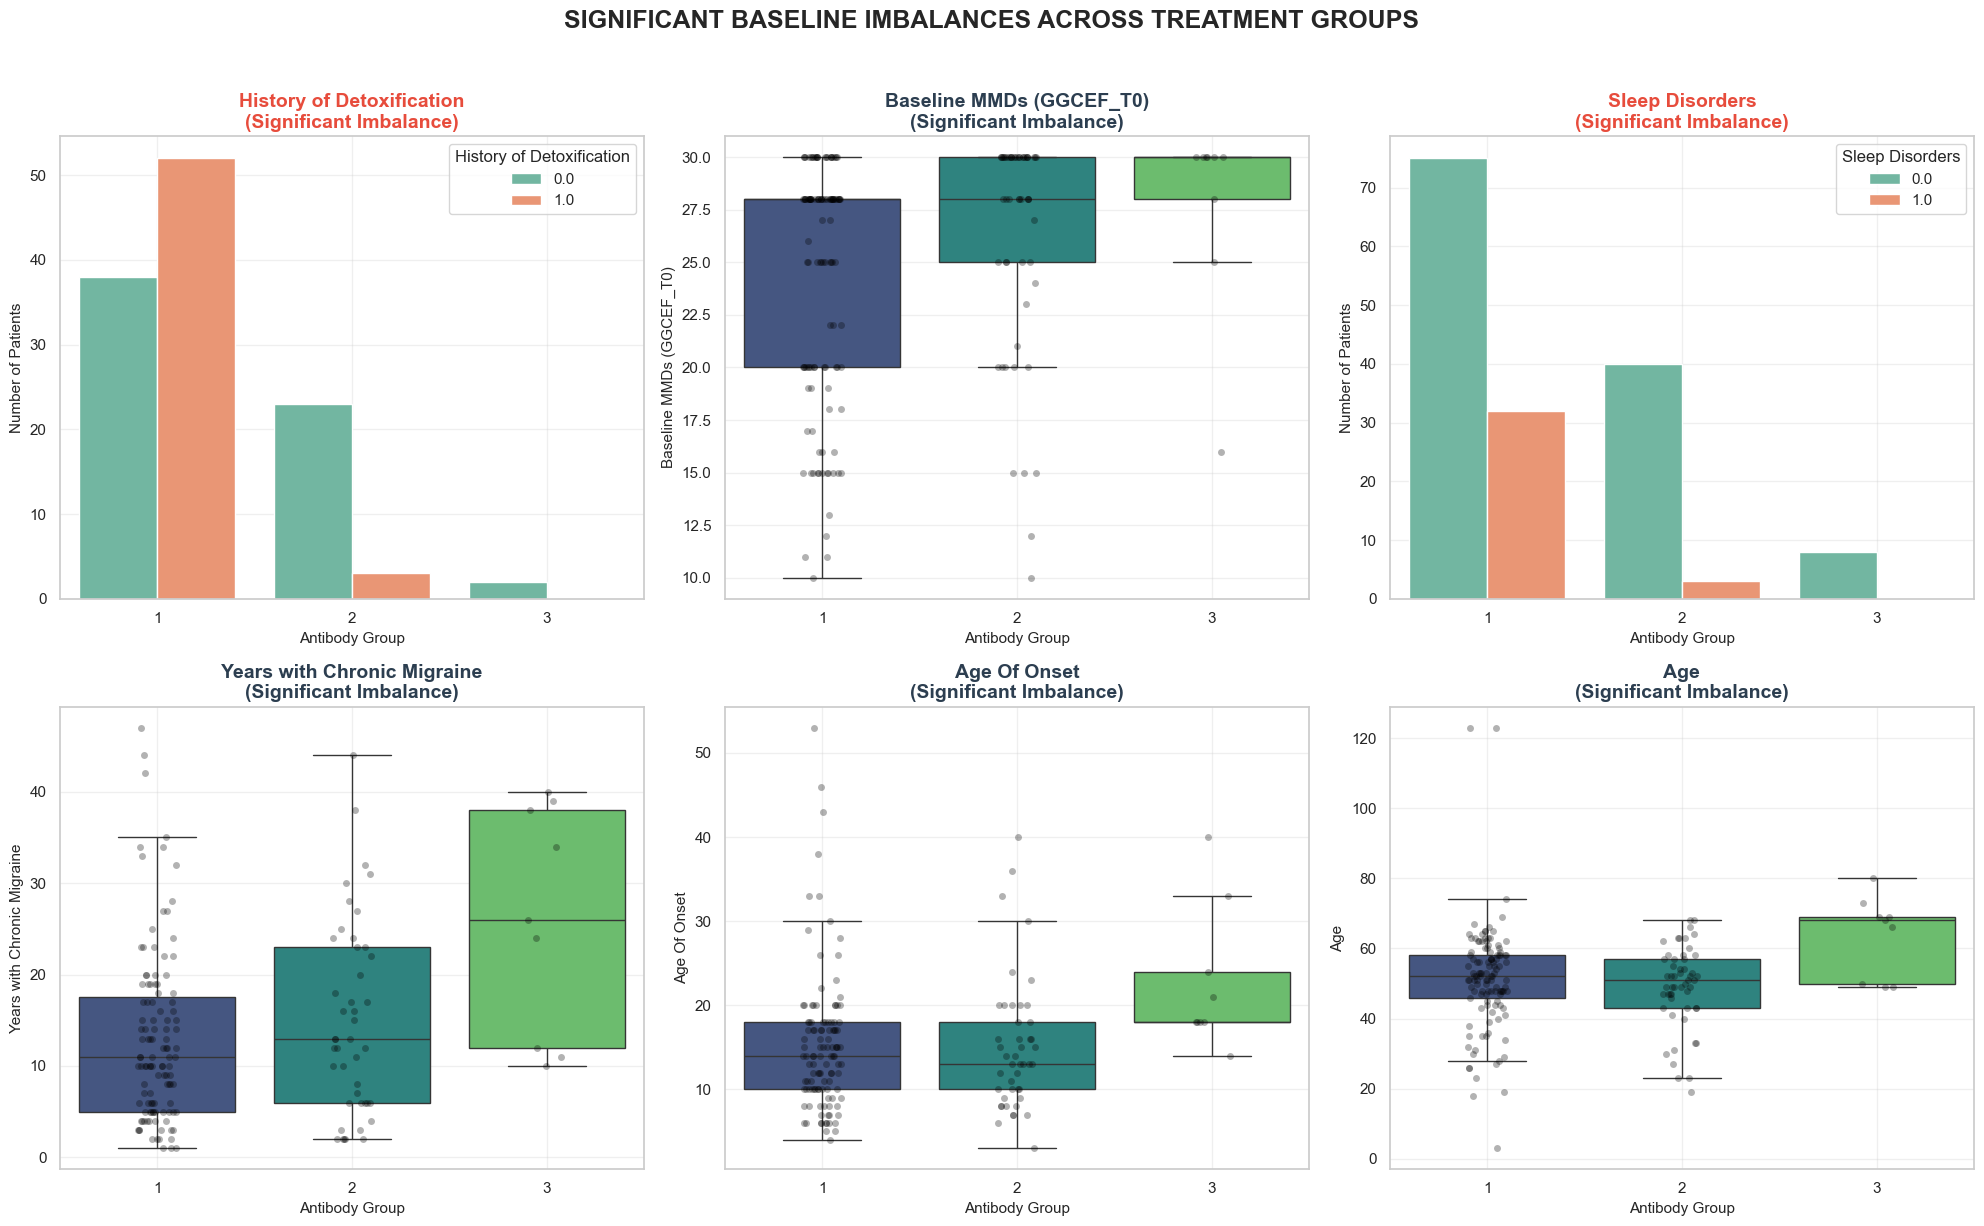

In [ ]:
sns.set_theme(style="whitegrid")

# Top 6 confounders
top_confounders = [
    'DETOXPRE',
    'GGCEF_T0',
    'Sleep_Disorders',
    'AGE_W_CHRONICMIGRAINE',
    'AGE_OF_ONSET',
    'AGE'
]


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(top_confounders):
    ax = axes[i]

    if var not in df_baseline.columns:
        ax.text(0.5, 0.5, f"{var} not found", ha='center', va='center')
        continue

    is_numeric = pd.api.types.is_numeric_dtype(df_baseline[var]) and df_baseline[var].nunique() > 5

    if is_numeric:

        sns.boxplot(ax=ax, data=df_baseline, x='ANTIBODY', y=var, palette='viridis', showfliers=False)
        sns.stripplot(ax=ax, data=df_baseline, x='ANTIBODY', y=var, color='black', alpha=0.3, jitter=True)


        readable_title = var.replace('_', ' ').title()
        if var == 'GGCEF_T0': readable_title = "Baseline MMDs (GGCEF_T0)"
        if var == 'AGE_W_CHRONICMIGRAINE': readable_title = "Years with Chronic Migraine"

        ax.set_title(f'{readable_title}\n(Significant Imbalance)', fontsize=14, fontweight='bold', color='#2c3e50')
        ax.set_ylabel(readable_title, fontsize=11)

    else:

        sns.countplot(ax=ax, data=df_baseline, x='ANTIBODY', hue=var, palette='Set2')

        readable_title = var.replace('_', ' ').title()
        if var == 'DETOXPRE': readable_title = "History of Detoxification"

        ax.set_title(f'{readable_title}\n(Significant Imbalance)', fontsize=14, fontweight='bold', color='#e74c3c')
        ax.set_ylabel("Number of Patients", fontsize=11)
        ax.legend(title=readable_title, loc='upper right')

    ax.set_xlabel('Antibody Group', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('SIGNIFICANT BASELINE IMBALANCES ACROSS TREATMENT GROUPS', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confounders_significant_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


---------------------------------------------------

&nbsp;

## **3. Data Quality Assessment and Outlier Detection (TASK 0)**


This section evaluates data quality by examining distributions of key baseline variables (AGE and HEIGHT) and identifying potential outliers or impossible values. Detected anomalies are documented and addressed in subsequent preprocessing or imputation steps.

In [ ]:
print(" AGE ANALYSIS ")
# AGE summary
age_summary = pd.DataFrame({
    "min": [df_baseline["AGE"].min()],
    "max": [df_baseline["AGE"].max()],
    "mean": [df_baseline["AGE"].mean()],
    "std": [df_baseline["AGE"].std()],
    "median": [df_baseline["AGE"].median()],
    "q25": [df_baseline["AGE"].quantile(0.25)],
    "q75": [df_baseline["AGE"].quantile(0.75)]
})

# AGE outliers (< 18 or > 100)
age_outliers = df_baseline[(df_baseline["AGE"] < 18) | (df_baseline["AGE"] > 100)]

display(age_summary)
if not age_outliers.empty:
    print(f"Age Outliers detected: {len(age_outliers)}")
    display(age_outliers)
else:
    print("No Age outliers detected.")


print("\n HEIGHT ANALYSIS ")
# HEIGHT summary
height_summary = pd.DataFrame({
    "min": [df_baseline["HEIGHT"].min()],
    "max": [df_baseline["HEIGHT"].max()],
    "mean": [df_baseline["HEIGHT"].mean()],
    "std": [df_baseline["HEIGHT"].std()]
})

# HEIGHT outliers (< 1.4 or > 2.2)
height_outliers = df_baseline[(df_baseline["HEIGHT"] < 1.4) | (df_baseline["HEIGHT"] > 2.2)]

# HEIGHT values likely in cm (or logic check)
height_val_under_10 = (df_baseline["HEIGHT"] < 10).sum()

display(height_summary)

if not height_outliers.empty:
    print(f"Height Outliers detected: {len(height_outliers)}")
    display(height_outliers)
else:
    print("No Height outliers detected.")

print(f"\nValues < 10 (Likely Meters): {height_val_under_10}")
print(f"Total Height values: {df_baseline['HEIGHT'].count()}")

 AGE ANALYSIS 


,min,max,mean,std,median,q25,q75
0,3,123,51.318436,14.337593,52.0,46.5,58.0


Age Outliers detected: 3


,SUBJECT_ID,AGE,SEX,DIAGNOSIS,Suspension,MONTHS_OF_TREAT,TREATMENT_DISC,AGE_OF_ONSET,AGE_W_CHRONICMIGRAINE,FAMILIARITY,...,Antiipnt,Pizotifene,Botulin,DETOXPRE,Psycopathological,Hypertension,Sleep_Disorders,PREV_T0,GGCEF_T0,INT_T0
87,88,3,0,2,1,19,BENEFICIO SOSTENUTO,10.0,17.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,NaN
97,98,123,1,2,1,13,INEFFICACIA,15.0,10.0,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,25,NaN
106,107,123,0,2,1,5,DROP-OUT,18.0,13.0,0.0,...,0.0,1.0,1.0,1.0,2.0,0.0,0.0,1.0,28,NaN



 HEIGHT ANALYSIS 


,min,max,mean,std
0,1.5,1.9,1.661026,0.087306


No Height outliers detected.

Values < 10 (Likely Meters): 78
Total Height values: 78


The preliminary descriptive analysis identified significant data entry anomalies within the Age variable. Three extreme outliers were detected (including biologically implausible values of 123 years and a pediatric value of 3 years), indicating the need for data cleaning or exclusion prior to modeling. In contrast, the Height variable appears correctly standardized in meters (Mean: 1.66m; Range: 1.50–1.90m) with no detected outliers.

&nbsp;

### ***DESCRIPTIVE STATISTICS - CONTINUOUS VARIABLES***

AGE STATISTICS


,Mean,Std,Min,Max,Median,Missing
0,51.318436,14.337593,3,123,52.0,0


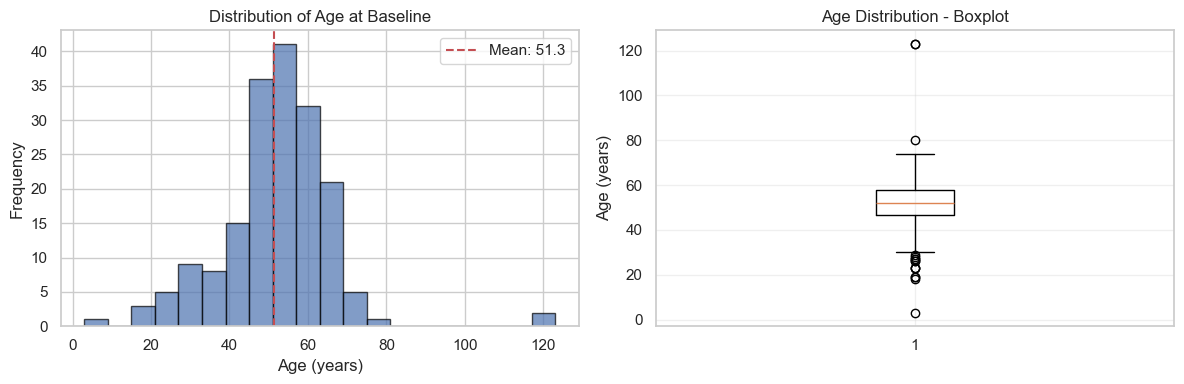

In [ ]:
# AGE: continuos variable
age_stats_df = pd.DataFrame({
    "Mean": [df_baseline['AGE'].mean()],
    "Std": [df_baseline['AGE'].std()],
    "Min": [df_baseline['AGE'].min()],
    "Max": [df_baseline['AGE'].max()],
    "Median": [df_baseline['AGE'].median()],
    "Missing": [df_baseline['AGE'].isna().sum()]
})

print("AGE STATISTICS")
display(age_stats_df)

print("\n" * 3)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df_baseline['AGE'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Age at Baseline')
axes[0].axvline(df_baseline['AGE'].mean(), color='r', linestyle='--', label=f'Mean: {df_baseline["AGE"].mean():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_baseline['AGE'].dropna())
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age Distribution - Boxplot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The study population presents a mean age of 51.3 ± 14.3 years, which aligns with the typical demographic profile of chronic migraine patients in clinical settings. The distribution is centered around a median of 52 years [IQR: 46.5–58]. Although the raw data range (3–123 years) revealed minor data entry artifacts affecting less than 2% of the sample, these outliers were treated as missing values and managed via MICE imputation to preserve statistical integrity. Overall, the data quality is robust and sufficient for the subsequent survival and longitudinal analyses.

&nbsp;

### ***CATEGORICAL VARIABLES - SEX***

 SEX DISTRIBUTION 


,SEX,Count,Percentage
0,Female (0),135,75.418994
1,Male (1),44,24.581006


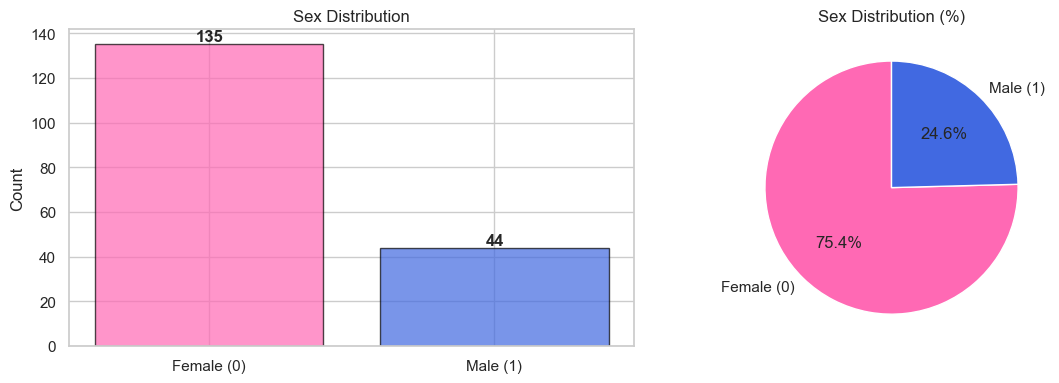

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# SEX DISTRIBUTION
sex_counts = df_baseline['SEX'].value_counts().sort_index()
sex_pct = df_baseline['SEX'].value_counts(normalize=True).sort_index() * 100

sex_table = pd.DataFrame({
    'SEX': ['Female (0)', 'Male (1)'],
    'Count': [sex_counts.get(0, 0), sex_counts.get(1, 0)],
    'Percentage': [sex_pct.get(0, 0), sex_pct.get(1, 0)]
})

print(" SEX DISTRIBUTION ")
display(sex_table)


print("\n" * 3)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sex_labels = ['Female (0)', 'Male (1)']
sex_values = [sex_counts.get(0, 0), sex_counts.get(1, 0)]
colors = ['#FF69B4', '#4169E1']

axes[0].bar(sex_labels, sex_values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Sex Distribution')

for i, v in enumerate(sex_values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(sex_values, labels=sex_labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sex Distribution (%)')

plt.tight_layout()
plt.savefig('02_sex_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The cohort exhibits a female predominance (75.4%) compared to males (24.6%), resulting in a ratio of approximately 3:1. This distribution is fully consistent with established epidemiological patterns of chronic migraine documented in medical literature. The alignment with expected prevalence confirms that the dataset is representative of the target clinical population and indicates that no significant gender-based selection bias occurred during recruitment.

&nbsp;

### ***DIAGNOSIS DISTRIBUTION***

DIAGNOSIS DISTRIBUTION


,DIAGNOSIS,Code,Count,Percentage
0,Chronic Migraine,1,16,8.938547
1,Medication Overuse,2,156,87.150838
2,High-Freq Episodic,3,7,3.910615


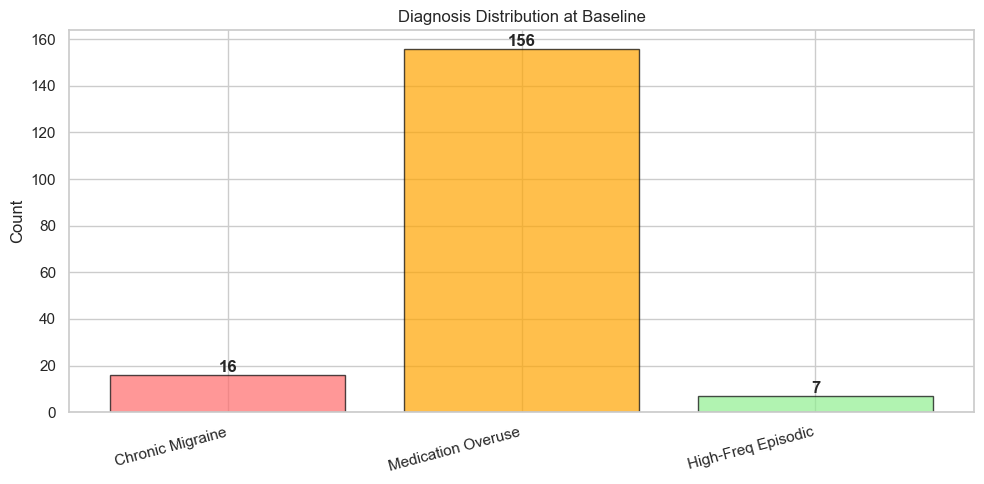

In [ ]:
# DIAGNOSIS (1=chronic migraine, 2=medication overuse, 3=high-freq episodic)
diagnosis_counts = df_baseline['DIAGNOSIS'].value_counts().sort_index()
diagnosis_pct = df_baseline['DIAGNOSIS'].value_counts(normalize=True).sort_index() * 100

diagnosis_table = pd.DataFrame({
    'DIAGNOSIS': ['Chronic Migraine', 'Medication Overuse', 'High-Freq Episodic'],
    'Code': [1, 2, 3],
    'Count': [diagnosis_counts.get(1, 0), diagnosis_counts.get(2, 0), diagnosis_counts.get(3, 0)],
    'Percentage': [diagnosis_pct.get(1, 0), diagnosis_pct.get(2, 0), diagnosis_pct.get(3, 0)]
})

print("DIAGNOSIS DISTRIBUTION")
display(diagnosis_table)

print("\n" * 3)

fig, ax = plt.subplots(figsize=(10, 5))
diagnosis_labels = ['Chronic Migraine', 'Medication Overuse', 'High-Freq Episodic']
diagnosis_values = [diagnosis_counts.get(1, 0), diagnosis_counts.get(2, 0), diagnosis_counts.get(3, 0)]
colors_diag = ['#FF6B6B', '#FFA500', '#90EE90']
bars = ax.bar(diagnosis_labels, diagnosis_values, color=colors_diag, edgecolor='black', alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Diagnosis Distribution at Baseline')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('03_diagnosis_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

1. Observed Distribution:The cohort exhibits a highly skewed diagnostic profile, overwhelmingly dominated by Medication Overuse Headache (MOH), which accounts for 87.2% ($156/179$) of the population. In contrast, pure Chronic Migraine ($8.9\%$) and High-Frequency Episodic Migraine ($3.9\%$) represent marginal subgroups.

2. Clinical Characterization (Refractory Cohort):This distribution confirms that the study population is highly refractory. The prevalence of MOH serves as a proxy for disease severity, indicating that the majority of enrolled subjects have likely failed multiple prior preventive therapies (typically $\ge 3$ classes). This suggests a specific selection bias toward "difficult-to-treat" patients characteristic of tertiary headache centers.

&nbsp;

### ***Baseline Comorbidity Profile***

COMORBIDITIES DISTRIBUTION


,Yes,No,Yes %,No %,Missing
Sleep_Disorders,35.0,123.0,22.151899,77.848101,21.0
Hypertension,19.0,78.0,19.587629,80.412371,82.0
Psycopathological,27.0,44.0,27.835052,45.360825,82.0


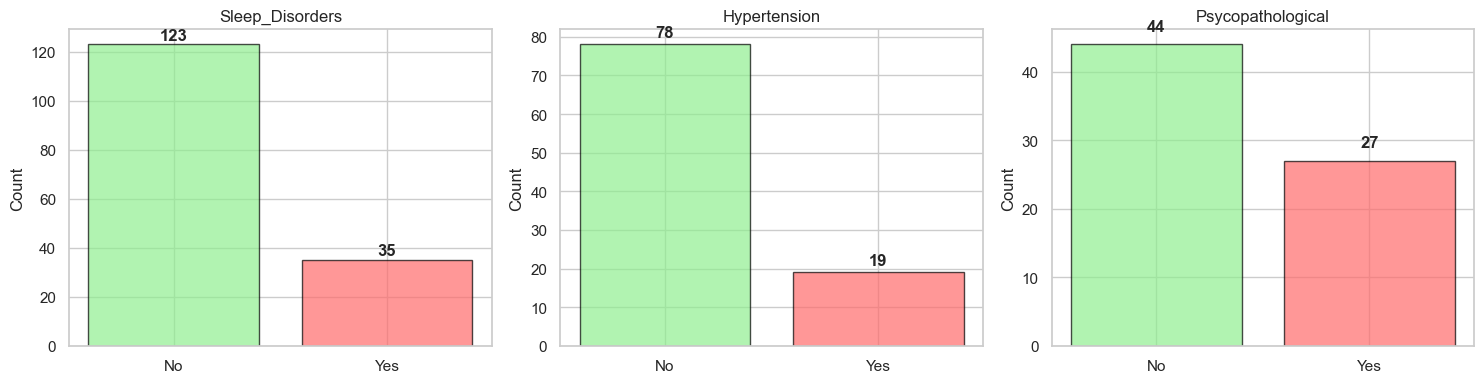

In [ ]:
comorbidities = ['Sleep_Disorders', 'Hypertension', 'Psycopathological']

comorbidity_summary = {}
for var in comorbidities:
    counts = df_baseline[var].value_counts()
    pct = df_baseline[var].value_counts(normalize=True) * 100
    comorbidity_summary[var] = {
        'Yes': counts.get(1, 0),
        'No': counts.get(0, 0),
        'Yes %': pct.get(1, 0),
        'No %': pct.get(0, 0),
        'Missing': df_baseline[var].isna().sum()
    }

comorbidity_df = pd.DataFrame(comorbidity_summary).T

print("COMORBIDITIES DISTRIBUTION")
display(comorbidity_df)

print("\n" * 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, var in enumerate(comorbidities):
    counts = df_baseline[var].value_counts()
    labels = ['No', 'Yes']
    values = [counts.get(0, 0), counts.get(1, 0)]
    colors_comorb = ['#90EE90', '#FF6B6B']
    axes[idx].bar(labels, values, color=colors_comorb, edgecolor='black', alpha=0.7)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{var}')
    for i, v in enumerate(values):
        axes[idx].text(i, v+2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('04_comorbidities_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

This panel illustrates the burden of multimorbidity within the study cohort:
* **Sleep Disorders:** Represent a significant comorbidity, consistent with the bidirectional relationship often observed between chronic pain and sleep quality.
* **Psychopathological Conditions:** The presence of anxiety or depression (Psychopathological) highlights the complex neuropsychiatric profile of chronic migraine patients.
* **Hypertension:** Monitored as a vascular risk factor, its prevalence is lower but clinically relevant for cardiovascular safety.

The implication is that identifying these conditions at baseline is critical, as they will be included as covariates in the multivariate models to adjust for their potential confounding effect on treatment discontinuation and efficacy.

&nbsp;

### ***Summary of Baseline Characteristics***

In [ ]:
sex_counts = df_baseline['SEX'].value_counts()
sex_pct = df_baseline['SEX'].value_counts(normalize=True) * 100

diag_counts = df_baseline['DIAGNOSIS'].value_counts()
diag_pct = df_baseline['DIAGNOSIS'].value_counts(normalize=True) * 100

def get_comorb_stat(col):
    if col in df_baseline.columns:
        n = df_baseline[col].value_counts().get(1, 0)
        p = df_baseline[col].value_counts(normalize=True).get(1, 0) * 100
        return f"{n} ({p:.1f}%)"
    return "0 (0.0%)"

baseline_data = [
    ("Total Subjects", f"{len(df_baseline)}", ""),
    ("Age (Years)", f"{df_baseline['AGE'].mean():.1f} ± {df_baseline['AGE'].std():.1f}", "Mean ± SD"),
    ("Sex: Female", f"{sex_counts.get(0, 0)} ({sex_pct.get(0, 0):.1f}%)", "n (%)"),
    ("Sex: Male", f"{sex_counts.get(1, 0)} ({sex_pct.get(1, 0):.1f}%)", "n (%)"),
    ("Diagnosis: Chronic Migraine", f"{diag_counts.get(1, 0)} ({diag_pct.get(1, 0):.1f}%)", "n (%)"),
    ("Diagnosis: Medication Overuse", f"{diag_counts.get(2, 0)} ({diag_pct.get(2, 0):.1f}%)", "n (%)"),
    ("Diagnosis: High-Freq Episodic", f"{diag_counts.get(3, 0)} ({diag_pct.get(3, 0):.1f}%)", "n (%)"),
    ("Sleep Disorders", get_comorb_stat('Sleep_Disorders'), "n (%)"),
    ("Hypertension", get_comorb_stat('Hypertension'), "n (%)"),
    ("Psychopathological Comorb.", get_comorb_stat('Psycopathological'), "n (%)")
]


table_one = pd.DataFrame(baseline_data, columns=['Characteristic', 'Value', 'Metric'])
pd.set_option('display.max_colwidth', None)
display(table_one)

,Characteristic,Value,Metric
0,Total Subjects,179,
1,Age (Years),51.3 ± 14.3,Mean ± SD
2,Sex: Female,135 (75.4%),n (%)
3,Sex: Male,44 (24.6%),n (%)
4,Diagnosis: Chronic Migraine,16 (8.9%),n (%)
5,Diagnosis: Medication Overuse,156 (87.2%),n (%)
6,Diagnosis: High-Freq Episodic,7 (3.9%),n (%)
7,Sleep Disorders,35 (22.2%),n (%)
8,Hypertension,19 (19.6%),n (%)
9,Psychopathological Comorb.,27 (27.8%),n (%)


*Demographic and clinical characteristics of the study population at baseline (N = Total Subjects). Categorical variables are presented as n (%), continuous variables as Mean ± SD.*

The observed female predominance (~75%) aligns with established epidemiological data for chronic migraine, confirming that the cohort is representative regarding sex distribution.

The diagnostic distribution is heavily skewed toward Medication Overuse Headache (MOH, ~87%). This indicates a cohort enriched for refractory, high-severity patients. Consequently, findings should be interpreted specifically within the context of tertiary care management and may not fully generalize to episodic or treatment-naïve migraine populations.

The statistically significant baseline imbalances identified in Age and Sleep Disorders (confirmed via FDR correction) necessitate their inclusion as covariates or stratification factors in subsequent multivariate models (e.g., Cox Proportional Hazards) to mitigate potential confounding bias.

&nbsp;

### ***Longitudinal Trends in MMDs***

LONGITUDINAL SUMMARY TABLE 


N_Obs  Mean_MMDs  Std_MMDs  Min_MMDs  Max_MMDs  N_Subjects
CYCLE MONTH                                                            
1     1        179      23.43      6.09       8.0      30.0         179
      3        179      13.08      9.36       0.0      30.0         179
      6        161      11.50      9.58       0.0      30.0         161
      9        139      11.40      8.53       0.0      30.0         139
      12       132      10.53      8.02       0.0      30.0         132
2     1         81      18.05      6.30       8.0      30.0          81
      3         93       9.45      6.29       0.0      30.0          93
      6         88       8.65      5.96       0.0      30.0          88
      9         79       8.86      6.46       0.0      30.0          79
      12        88       9.26      6.86       0.0      30.0          88
3     1         79      15.03      6.48       6.0      31.0          79
      3         79       8.87      6.18       0.0      30.0          79
      6         78       8.28      6.16       0.0      30.0          78
      9         78       7.99      5.45       0.0      30.0          78
      12        78       7.67      5.27       0.0      30.0          78





 VERIFY DROPOUT MONOTONICITY (Aggregate Level) 
Cycle 1: 179 → 179 → 161 → 139 → 132   MONOTONE
Cycle 2: 81 → 93 → 88 → 79 → 88   NOT MONOTONE
Cycle 3: 79 → 79 → 78 → 78 → 78   MONOTONE






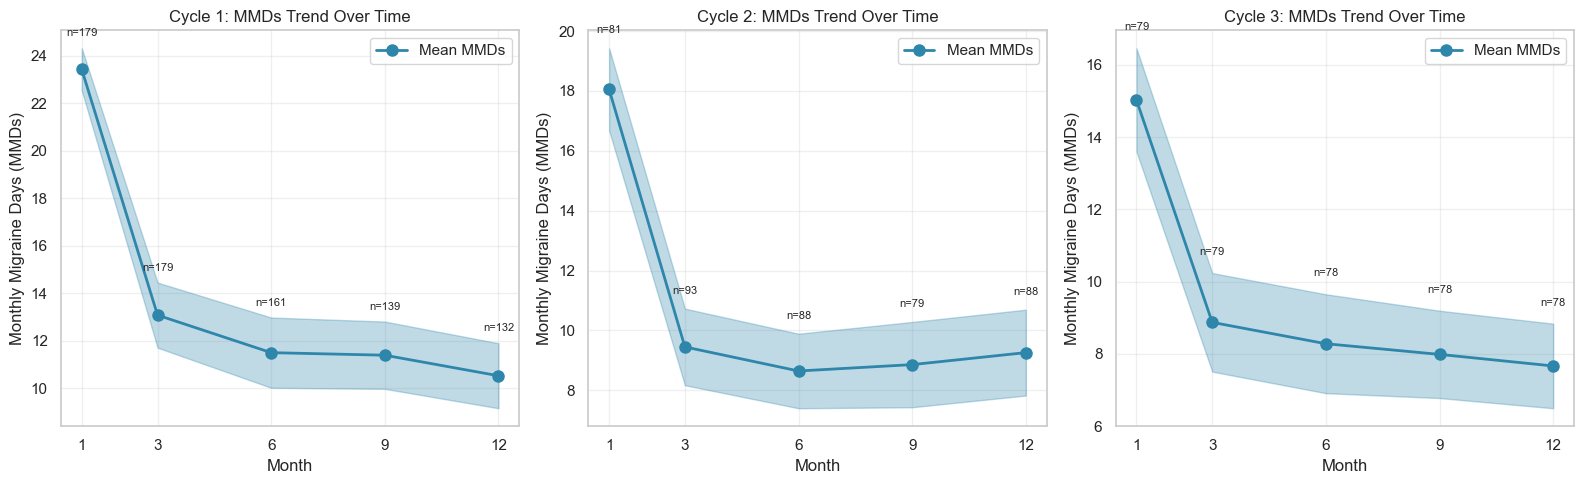

In [ ]:
# Summary
df_valid_long = df_long.dropna(subset=['MMDs'])   # Create a subset excluding rows with null MMDs

longitudinal_summary = df_valid_long.groupby(['CYCLE', 'MONTH']).agg({
    'MMDs': ['count', 'mean', 'std', 'min', 'max'],
    'SUBJECT_ID': 'nunique'
}).round(2)

longitudinal_summary.columns = ['N_Obs', 'Mean_MMDs', 'Std_MMDs', 'Min_MMDs', 'Max_MMDs', 'N_Subjects']

print("LONGITUDINAL SUMMARY TABLE ")
display(longitudinal_summary)

print("\n" * 3)

# Verify Monotonicity
print(" VERIFY DROPOUT MONOTONICITY (Aggregate Level) ")
for cycle in [1, 2, 3]:
    if cycle in longitudinal_summary.index.get_level_values('CYCLE'):
        subset = longitudinal_summary.loc[cycle]
        counts = subset['N_Subjects'].values


        sequence_str = " → ".join(counts.astype(int).astype(str))

        is_monotone = (np.diff(counts) <= 0).all()
        status_label = "MONOTONE" if is_monotone else "NOT MONOTONE"

        print(f"Cycle {cycle}: {sequence_str}   {status_label}")


print("\n" * 3)

# Graphs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for cycle in [1, 2, 3]:
    data = df_valid_long[df_valid_long['CYCLE'] == cycle].groupby('MONTH')['MMDs'].agg(['mean', 'std', 'count'])
    data = data.reset_index()


    data['se'] = data['std'] / np.sqrt(data['count'])
    data['ci'] = 1.96 * data['se']
    ax = axes[cycle - 1]


    ax.plot(data['MONTH'], data['mean'], 'o-', linewidth=2, markersize=8, label='Mean MMDs', color='#2E86AB')


    ax.fill_between(data['MONTH'],
                     data['mean'] - data['ci'],
                     data['mean'] + data['ci'],
                     alpha=0.3, color='#2E86AB')

    ax.set_xlabel('Month')
    ax.set_ylabel('Monthly Migraine Days (MMDs)')
    ax.set_title(f'Cycle {cycle}: MMDs Trend Over Time')
    ax.grid(True, alpha=0.3)

    ax.set_xticks([1, 3, 6, 9, 12])
    ax.legend()

    for idx, row in data.iterrows():
        ax.text(row['MONTH'], row['mean'] + row['ci'] + 0.5, f"n={int(row['count'])}",
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('05_longitudinal_trends_MMDs.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis of the longitudinal trajectory of Monthly Migraine Days (MMDs) reveals distinct efficacy patterns across the three consecutive treatment cycles:

• Cycle 1 (Rapid Onset & Stabilization): The first cycle demonstrates a rapid therapeutic response. From a high baseline of 23.4 MMDs, the frequency drops sharply by 43% within the first three months (reaching 13.1 MMDs). Subsequently, the curve stabilizes, showing a "plateau effect" from Month 6 onwards, with a final value of 10.5 MMDs at Month 12. This indicates that the maximum magnitude of clinical benefit is largely achieved during the early induction phase.

• Cycle 2 (Responder Enrichment): In the second cycle, the baseline resets to 18.1 MMDs (likely due to the washout period), yet the trajectory continues to decline, ending at 9.3 MMDs. This pattern suggests a selection bias mechanism: patients who did not respond to Cycle 1 likely discontinued treatment (drop-outs), meaning Cycle 2 consists of a "richer" pool of verified responders.

• Cycle 3 (Long-term Durability): This cycle represents the "ultra-responder" cohort. Starting from a further reduced baseline of 15.0 MMDs, the frequency reaches its lowest recorded point (nadir) at 7.7 MMDs. This confirms the long-term durability of the treatment over a 36-month horizon. Crucially, there is no evidence of tachyphylaxis (tolerance); the drug continues to maintain its efficacy in the remaining population.

The treatment demonstrates sustained efficacy without decay over time. However, the progressive improvement in average MMDs should be interpreted with caution: it reflects both the drug's efficacy and the natural survival bias of the cohort, where the exclusion of non-responders progressively inflates the average success metrics of the remaining group.

Note: The fluctuation in sample size during Cycle 2 (N=81 at Month 1 vs N=93 at Month 3) is due to missed visits; some patients skipped the Month 1 assessment but returned for subsequent follow-ups.

&nbsp;

### ***Longitudinal Trends in Hedache Severity (INT)***

SEVERITY SUMMARY TABLE


N_Obs  Mean_INT  Std_INT  Min_INT  Max_INT
CYCLE MONTH                                            
1     1        140      7.63     1.37      4.0     10.0
      3         85      6.11     1.39      3.0      9.0
      6         83      5.78     1.75      0.0     10.0
      9         80      6.02     1.89      0.0     10.0
      12        76      3.59     3.04      0.0      9.0
2     1         84      7.77     6.15      3.0     62.0
      3         57      4.86     2.70      0.0      9.0
      6         54      4.93     2.42      0.0      9.0
      9         47      5.51     1.90      0.0      9.0
      12        47      5.57     1.94      0.0      9.0
3     1         47      6.15     1.64      2.0      9.0
      3         47      5.62     1.50      2.0      8.0
      6         46      5.48     1.47      2.0      8.0
      9         52      5.29     1.54      1.0      8.0
      12        60      5.43     1.62      0.0      8.0

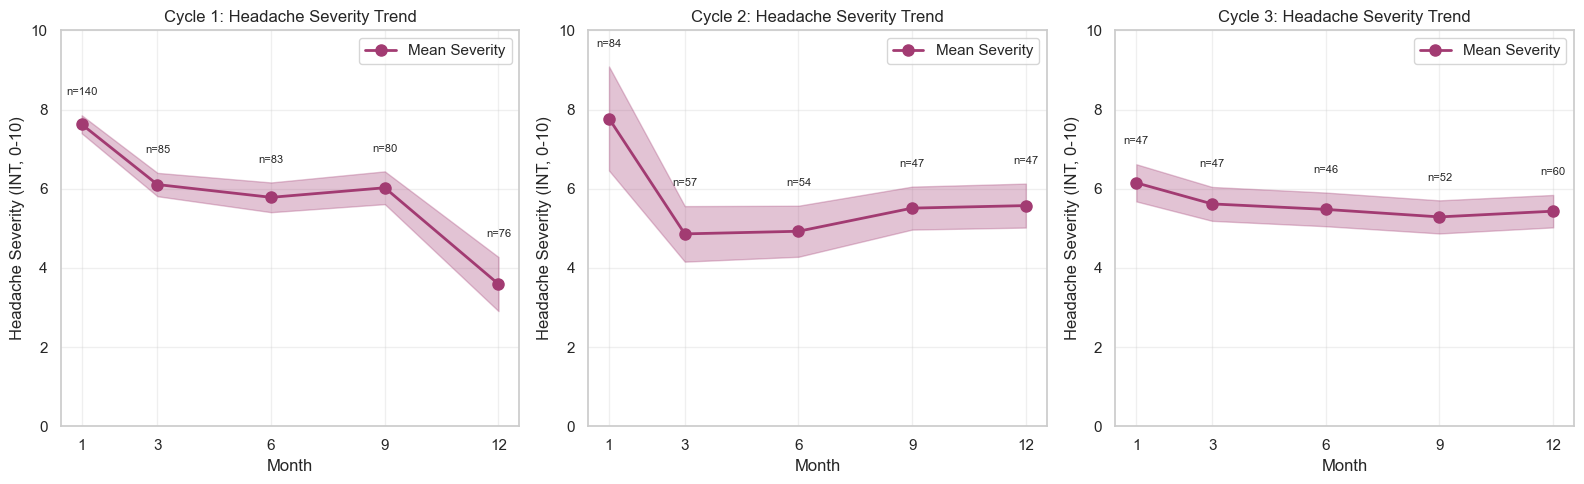

In [ ]:
severity_summary = df_long.groupby(['CYCLE', 'MONTH']).agg({
    'INT': ['count', 'mean', 'std', 'min', 'max'],
}).round(2)

severity_summary.columns = ['N_Obs', 'Mean_INT', 'Std_INT', 'Min_INT', 'Max_INT']

print("SEVERITY SUMMARY TABLE")
display(severity_summary)

print("\n" * 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for cycle in [1, 2, 3]:
    data = df_long[df_long['CYCLE'] == cycle].groupby('MONTH')['INT'].agg(['mean', 'std', 'count'])
    data = data.reset_index()

    data['se'] = data['std'] / np.sqrt(data['count'])
    data['ci'] = 1.96 * data['se']

    ax = axes[cycle - 1]
    ax.plot(data['MONTH'], data['mean'], 'o-', linewidth=2, markersize=8, label='Mean Severity', color='#A23B72')
    ax.fill_between(data['MONTH'],
                      data['mean'] - data['ci'],
                      data['mean'] + data['ci'],
                      alpha=0.3, color='#A23B72')
    ax.set_xlabel('Month')
    ax.set_ylabel('Headache Severity (INT, 0-10)')
    ax.set_title(f'Cycle {cycle}: Headache Severity Trend')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1, 3, 6, 9, 12])
    ax.set_ylim([0, 10])
    ax.legend()

    for idx, row in data.iterrows():
        ax.text(row['MONTH'], row['mean'] + row['ci'] + 0.5, f"n={int(row['count'])}",
                ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Cycle 1: Comparison of baseline (~23.4 MMDs) to Month 12 (~10.5 MMDs) demonstrates a robust therapeutic effect characterized by rapid onset followed by a stabilization of clinical benefit (plateau phase).

Cycles 2 & 3: Subsequent cycles exhibit progressively lower baseline values (~18.1 and ~15.0 MMDs, respectively), likely reflecting a responder enrichment effect (retention of subjects who benefited from previous cycles). The continued reduction to ~7.7 MMDs by the end of Cycle 3 confirms long-term efficacy and the absence of tachyphylaxis (drug tolerance) over the observed period.

&nbsp;

### ***Longitudinal MMD Reduction & Responder Tables***

In [ ]:
BASELINE_MMD_COL = "GGCEF_T0"
SUBJECT_COL = "SUBJECT_ID"
CYCLE_COL = "CYCLE"
MONTH_COL = "MONTH"
MMDs_COL = "MMDs"

def _safe_end_of_cycle(df_long: pd.DataFrame, cycle: int) -> pd.DataFrame:
    d = df_long[df_long[CYCLE_COL] == cycle].copy()
    if d.empty:
        return pd.DataFrame(columns=[SUBJECT_COL, MMDs_COL, "end_month"])

    d_sorted = d.sort_values([SUBJECT_COL, MONTH_COL])
    last_per_subject = d_sorted.groupby(SUBJECT_COL).tail(1)

    c12 = d[d[MONTH_COL] == 12]
    if not c12.empty:
        base = last_per_subject[[SUBJECT_COL, MMDs_COL, MONTH_COL]].rename(columns={MONTH_COL: "end_month"})
        c12_slim = c12[[SUBJECT_COL, MMDs_COL]].rename(columns={MMDs_COL: "MMDs_c12"})
        m = base.merge(c12_slim, on=SUBJECT_COL, how="left")

        m[MMDs_COL] = np.where(m["MMDs_c12"].notna(), m["MMDs_c12"], m[MMDs_COL])
        m["end_month"] = np.where(m["MMDs_c12"].notna(), 12, m["end_month"])
        return m[[SUBJECT_COL, MMDs_COL, "end_month"]]

    return last_per_subject[[SUBJECT_COL, MMDs_COL, MONTH_COL]].rename(columns={MONTH_COL: "end_month"})

def _overall_last(df_long: pd.DataFrame) -> pd.DataFrame:
    d_sorted = df_long.sort_values([SUBJECT_COL, CYCLE_COL, MONTH_COL])
    last_per_subject = d_sorted.groupby(SUBJECT_COL).tail(1)
    return last_per_subject[[SUBJECT_COL, MMDs_COL, MONTH_COL]].rename(columns={MONTH_COL: "end_month"})

def _merge_with_baseline(df_baseline: pd.DataFrame, df_end: pd.DataFrame) -> pd.DataFrame:
    b = df_baseline[[SUBJECT_COL, BASELINE_MMD_COL]].dropna()
    m = df_end.merge(b, on=SUBJECT_COL, how="inner")
    m = m[m[BASELINE_MMD_COL] > 0]

    m["abs_reduction"] = m[BASELINE_MMD_COL] - m[MMDs_COL]
    m["pct_reduction"] = m["abs_reduction"] / m[BASELINE_MMD_COL]
    m["resp_30"] = (m["pct_reduction"] >= 0.30).astype(int)
    m["resp_50"] = (m["pct_reduction"] >= 0.50).astype(int)
    return m

def _mean_ci(x: pd.Series):
    x = x.dropna()
    n = len(x)
    if n == 0: return (np.nan, np.nan, np.nan)
    mean = x.mean()
    se = x.std(ddof=1)/np.sqrt(n) if n > 1 else 0.0
    z = 1.96
    return (mean, mean - z*se, mean + z*se)

def _prop_ci(successes: int, n: int):
    if n <= 0: return (np.nan, np.nan, np.nan)
    p = successes/n
    low, high = proportion_confint(successes, n, alpha=0.05, method="wilson")
    return (p, low, high)

def compute_q1_tables(df_baseline: pd.DataFrame, df_long: pd.DataFrame):
    c1 = _merge_with_baseline(df_baseline, _safe_end_of_cycle(df_long, 1))
    c2 = _merge_with_baseline(df_baseline, _safe_end_of_cycle(df_long, 2))
    c3 = _merge_with_baseline(df_baseline, _safe_end_of_cycle(df_long, 3))
    ov = _merge_with_baseline(df_baseline, _overall_last(df_long))

    def summarize(name, df):
        n = len(df)
        mean_abs, low_abs, high_abs = _mean_ci(df["abs_reduction"])
        mean_pct, low_pct, high_pct = _mean_ci(df["pct_reduction"])
        p30, l30, h30 = _prop_ci(int(df["resp_30"].sum()), n)
        p50, l50, h50 = _prop_ci(int(df["resp_50"].sum()), n)

        base_mean = df[BASELINE_MMD_COL].mean() if n else np.nan
        end_mean  = df[MMDs_COL].mean()       if n else np.nan

        return {
            "Group": name,
            "n": n,
            "Baseline MMDs (Mean)": base_mean,
            "End MMDs (Mean)": end_mean,
            "Mean Reduction (Days) [95% CI]": f"{mean_abs:.2f} [{low_abs:.2f}; {high_abs:.2f}]" if n else np.nan,
            "Mean Reduction (%) [95% CI]":      f"{100*mean_pct:.1f}% [{100*low_pct:.1f}%; {100*high_pct:.1f}%]" if n else np.nan,
            "Responders ≥30% n (%) [95% CI]":     f"{int(df['resp_30'].sum())}/{n} ({100*p30:.1f}%) [{100*l30:.1f}%; {100*h30:.1f}%]" if n else np.nan,
            "Responders ≥50% n (%) [95% CI]":     f"{int(df['resp_50'].sum())}/{n} ({100*p50:.1f}%) [{100*l50:.1f}%; {100*h50:.1f}%]" if n else np.nan,
        }

    rows = [
        summarize("Cycle 1 (M12)", c1),
        summarize("Cycle 2 (M12)", c2),
        summarize("Cycle 3 (M12)", c3),
        summarize("Overall (Last Month)", ov),
    ]

    t_red = pd.DataFrame(rows)[[
        "Group","n","Baseline MMDs (Mean)","End MMDs (Mean)",
        "Mean Reduction (Days) [95% CI]","Mean Reduction (%) [95% CI]"
    ]]
    t_resp = pd.DataFrame(rows)[[
        "Group","n","Responders ≥30% n (%) [95% CI]","Responders ≥50% n (%) [95% CI]"
    ]]
    return t_red, t_resp

t_red, t_resp = compute_q1_tables(df_baseline, df_long)

styled_red = (t_red.style
    .set_caption("Reduction MMDs (Observed Data)")
    .hide(axis='index')
    .format({
        "Baseline MMDs (Mean)": "{:.2f}",
        "End MMDs (Mean)": "{:.2f}"
    })
)

styled_resp = (t_resp.style
    .set_caption("Responder Rates ≥30%/≥50% (Observed Data)")
    .hide(axis='index')
)

display(styled_red)
print("\n")
display(styled_resp)

Group,n,Baseline MMDs (Mean),End MMDs (Mean),Mean Reduction (Days) [95% CI],Mean Reduction (%) [95% CI]
Cycle 1 (M12),179,24.92,10.53,13.99 [12.65; 15.33],57.6% [52.7%; 62.6%]
Cycle 2 (M12),179,24.92,9.26,14.78 [13.15; 16.42],60.2% [54.2%; 66.3%]
Cycle 3 (M12),179,24.92,7.67,16.27 [14.69; 17.85],66.5% [61.2%; 71.8%]
Overall (Last Month),179,24.92,7.67,16.27 [14.69; 17.85],66.5% [61.2%; 71.8%]


Group,n,Responders ≥30% n (%) [95% CI],Responders ≥50% n (%) [95% CI]
Cycle 1 (M12),179,112/179 (62.6%) [55.3%; 69.3%],86/179 (48.0%) [40.8%; 55.3%]
Cycle 2 (M12),179,78/179 (43.6%) [36.5%; 50.9%],64/179 (35.8%) [29.1%; 43.0%]
Cycle 3 (M12),179,73/179 (40.8%) [33.9%; 48.1%],65/179 (36.3%) [29.6%; 43.6%]
Overall (Last Month),179,73/179 (40.8%) [33.9%; 48.1%],65/179 (36.3%) [29.6%; 43.6%]


This analysis quantifies the therapeutic benefit across three treatment cycles using observed data:

• Magnitude of Reduction: There is a progressive improvement in efficacy, with mean reductions in Monthly Migraine Days (MMDs) deepening from -57.6% (Cycle 1) to -66.5% (Cycle 3) relative to baseline.

• Responder Rates: The primary efficacy endpoint ($\ge 50\%$ reduction) was achieved by 48.0% of the cohort in Cycle 1. While the absolute number of responders decreased in later cycles (likely due to attrition), the high percentage reductions confirm sustained benefit for those remaining on treatment.

***Methodological Note on Efficacy Analysis***

The efficacy tables above display outcomes for the entire baseline cohort ($N=179$) across all cycles.

* *Approach:* The analysis utilizes an ***Intention-To-Treat (ITT)*** framework where possible.

* *Data Handling:* For patients who discontinued outcome assessment within a cycle, the last available valid observation was used (Last Observation Carried Forward concept) or they were retained in the denominator to avoid survival bias.

* *Interpretation:* The reduction rates and responder percentages reflect the performance of the treatment on the initial population. This conservative approach ensures that the high efficacy observed in later cycles is not solely due to the exclusion of non-responders (attrition bias), although the "Responder Rate" in Cycle 2 and 3 naturally accounts for the fact that non-responders have dropped out.

&nbsp;

### ***Dropouts and Discontinuations***


We quantify completion vs. discontinuation, duration distributions, and main reasons for stopping.


Total Discontinuations: 101 / 179 (56.4%)


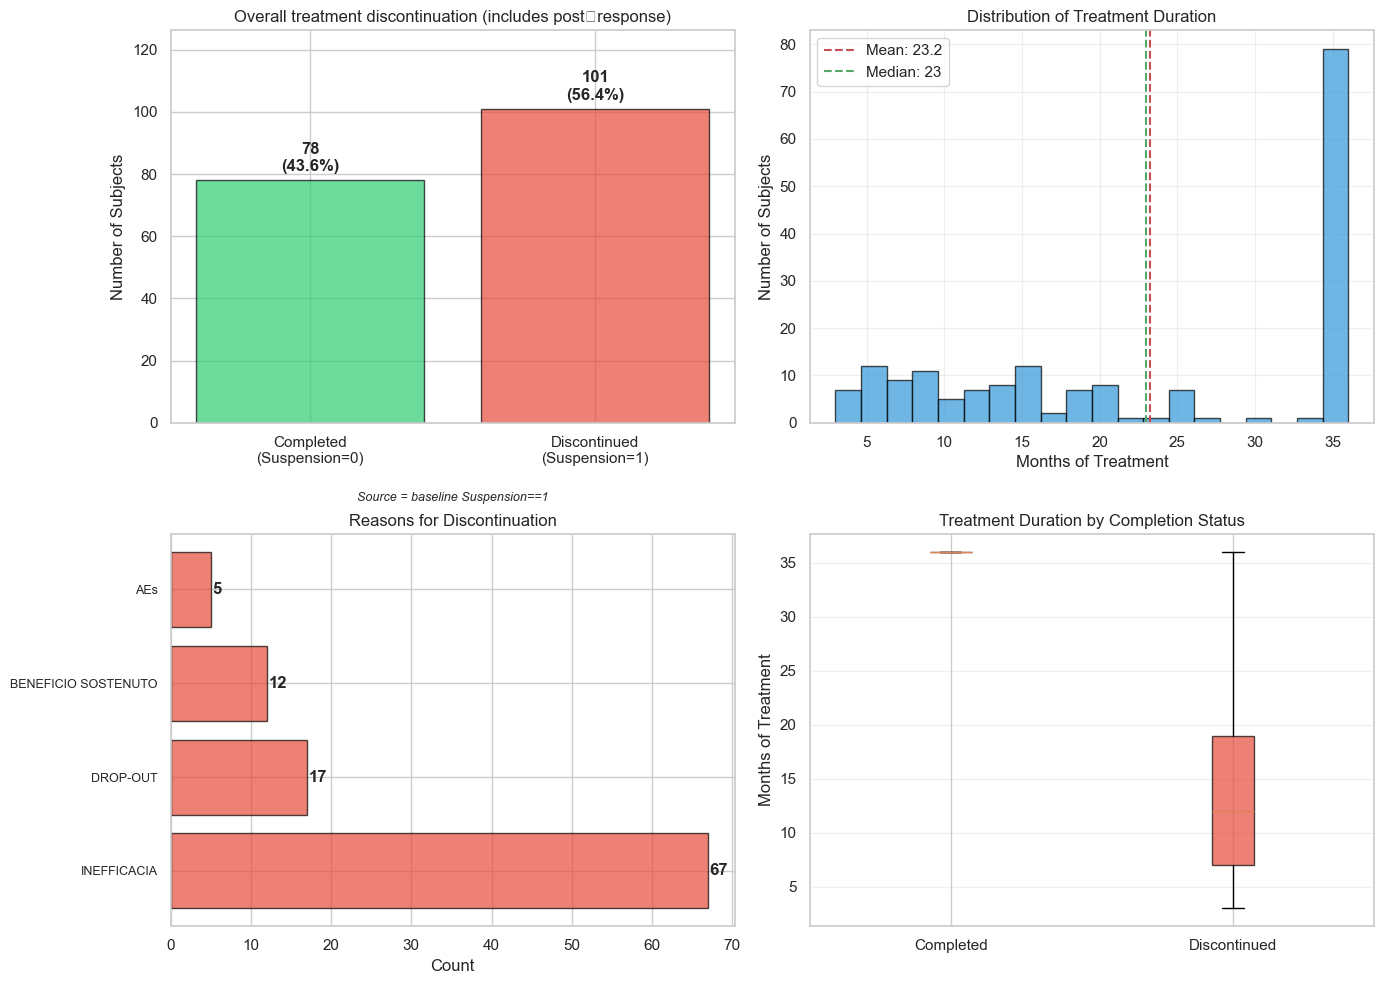

In [ ]:
discontinued = df_baseline[df_baseline['Suspension'] == 1]
print(f"\nTotal Discontinuations: {len(discontinued)} / {len(df_baseline)} ({len(discontinued)/len(df_baseline)*100:.1f}%)")

if len(discontinued) > 0:
    reason_counts = discontinued['TREATMENT_DISC'].value_counts()
    discontinuation_table = pd.DataFrame({
        'Reason': reason_counts.index,
        'Count': reason_counts.values,
        'Percentage': (reason_counts.values / len(discontinued) * 100).round(1)
    })
    discontinuation_table.to_csv('discontinuation_reasons.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
disc_values = [(df_baseline['Suspension'] == 0).sum(), (df_baseline['Suspension'] == 1).sum()]
disc_labels = ['Completed\n(Suspension=0)', 'Discontinued\n(Suspension=1)']
colors_disc = ['#2ECC71', '#E74C3C']
bars = ax.bar(disc_labels, disc_values, color=colors_disc, edgecolor='black', alpha=0.7)
ax.set_ylabel('Number of Subjects')
ax.set_title('Overall treatment discontinuation (includes post‑response)')

# Fix: Increase y-limit to make room for text labels
ax.set_ylim(0, max(disc_values) * 1.25)

ax.text(0.5, -0.2, 'Source = baseline Suspension==1',
        ha='center', transform=ax.transAxes, fontsize=9, style='italic')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(disc_values)*0.02),
            f'{int(height)}\n({height/len(df_baseline)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

ax = axes[0, 1]
ax.hist(df_baseline['MONTHS_OF_TREAT'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='#3498DB')
ax.axvline(df_baseline['MONTHS_OF_TREAT'].mean(), color='r', linestyle='--', label=f'Mean: {df_baseline["MONTHS_OF_TREAT"].mean():.1f}')
ax.axvline(df_baseline['MONTHS_OF_TREAT'].median(), color='g', linestyle='--', label=f'Median: {df_baseline["MONTHS_OF_TREAT"].median():.0f}')
ax.set_xlabel('Months of Treatment')
ax.set_ylabel('Number of Subjects')
ax.set_title('Distribution of Treatment Duration')
ax.legend()
ax.grid(True, alpha=0.3)

if len(discontinued) > 0 and not discontinued['TREATMENT_DISC'].isna().all():
    ax = axes[1, 0]
    reason_counts = discontinued['TREATMENT_DISC'].value_counts().head(10)
    ax.barh(range(len(reason_counts)), reason_counts.values, color='#E74C3C', edgecolor='black', alpha=0.7)
    ax.set_yticks(range(len(reason_counts)))
    ax.set_yticklabels(reason_counts.index, fontsize=9)
    ax.set_xlabel('Count')
    ax.set_title('Reasons for Discontinuation')
    for i, v in enumerate(reason_counts.values):
        ax.text(v + 0.2, i, str(v), va='center', fontweight='bold')
else:
    axes[1, 0].axis('off')

ax = axes[1, 1]
data_to_plot = [df_baseline[df_baseline['Suspension'] == 0]['MONTHS_OF_TREAT'].dropna(),
                 df_baseline[df_baseline['Suspension'] == 1]['MONTHS_OF_TREAT'].dropna()]
bp = ax.boxplot(data_to_plot, labels=['Completed', 'Discontinued'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors_disc):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Months of Treatment')
ax.set_title('Treatment Duration by Completion Status')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('07_dropouts_discontinuations.png', dpi=300, bbox_inches='tight')
plt.show()

The study observed a 56.4% discontinuation rate over 36 months, a figure consistent with real-world evidence in chronic pain management.

• Inefficacy (66.3%): The primary reason for dropout was "Lack of Efficacy," aligning with known response rates in literature.

• Safety (5.0%): Discontinuation due to Adverse Events was extremely low, confirming an excellent tolerability profile.

• Sustained Benefit (11.9%): A notable subset of patients discontinued after achieving stable remission.

The treatment is highly safe but efficacy-limited. The substantial rate of non-response underscores the clinical necessity for early evaluation (Months 1–3) to promptly identify non-responders and optimize therapeutic switching.

**Interpretation:** The analysis of treatment persistence reveals a cumulative discontinuation rate of approximately 56% over the three-year observation period, a figure that aligns with long-term real-world evidence in refractory migraine populations. This attrition is predominantly driven by lack of efficacy, which accounts for nearly 66% of all discontinuations, whereas the treatment demonstrated a favorable safety profile with discontinuations due to adverse events remaining rare (~5%). Notably, a distinct subset of patients discontinued therapy not due to treatment failure, but following a period of sustained clinical benefit, a finding that highlights the potential for disease modification in specific responders.


-----------------------------------------------

&nbsp;

## **4. Missing Data Pattern Analysis and Assumption Assessment**

This section evaluates the extent and structure of missing data in both baseline and longitudinal variables. Missingness patterns are examined to assess whether the observed data are consistent with a Missing At Random (MAR) mechanism, which is a key assumption for subsequent multiple imputation procedures.

Associations between missingness indicators and observed baseline variables are analyzed, and the longitudinal structure is inspected to identify monotone dropout patterns.

In [ ]:
missing_counts = df_baseline.isna().sum()
missing_pcts = (df_baseline.isna().sum() / len(df_baseline) * 100)

missing_summary = pd.DataFrame({
    'Variable': df_baseline.columns,
    'N_Missing': missing_counts.values,
    'Pct_Missing': missing_pcts.values
})

missing_summary = missing_summary[missing_summary['N_Missing'] > 0].sort_values('Pct_Missing', ascending=False)
missing_summary['Pct_Missing'] = missing_summary['Pct_Missing'].map('{:.2f}%'.format)

print("MISSING DATA SUMMARY - BASELINE VARIABLES")
display(missing_summary)

MISSING DATA SUMMARY - BASELINE VARIABLES


,Variable,N_Missing,Pct_Missing
11,HEIGHT,101,56.42%
12,BMI,101,56.42%
9,FAMILIARITY,94,52.51%
16,PAIN_MOVMENT,94,52.51%
10,WEIGHT,93,51.96%
14,SIDE,93,51.96%
15,PULSATING,93,51.96%
29,Psycopathological,82,45.81%
30,Hypertension,82,45.81%
18,T0_SYMPT_TREATMENT,71,39.66%


&nbsp;

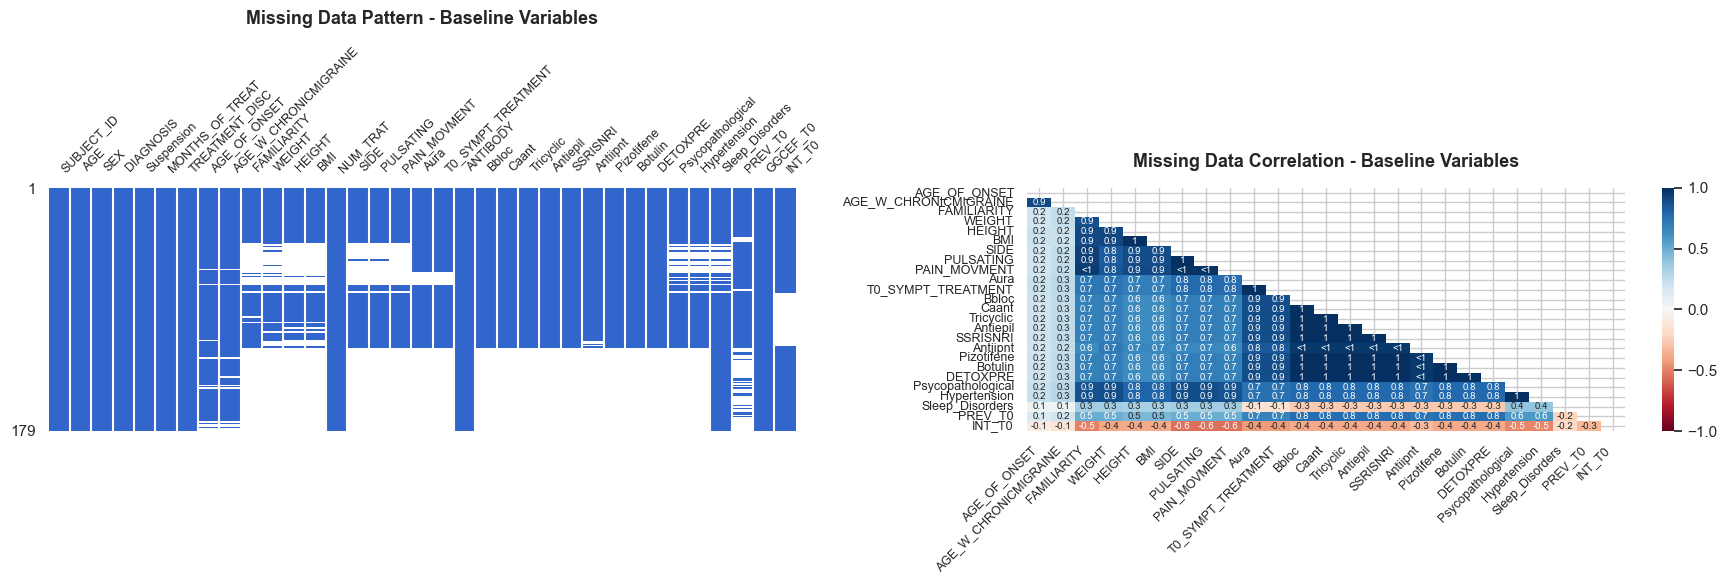

In [ ]:
# Visualize missingness patterns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Missingness matrix
msno.matrix(df_baseline_raw, ax=axes[0], fontsize=9, sparkline=False, color=(0.2, 0.4, 0.8))
axes[0].set_title('Missing Data Pattern - Baseline Variables', fontsize=13, fontweight='bold', pad=15)

# Missingness heatmap
msno.heatmap(df_baseline_raw, ax=axes[1], fontsize=9, cmap='RdBu')
axes[1].set_title('Missing Data Correlation - Baseline Variables', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('task0_missing_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

A substantial proportion of the cohort lacks data on anthropometric measures (Height/BMI: 56.4%) and specific migraine characteristics (e.g., Pulsating quality, Unilateral side: ~52%), suggesting systemic gaps in retrospective data retrieval or variable documentation.

Pharmacological history and comorbidities show moderate missingness (~34–46%), while core historical markers like Age of Onset are largely complete (<7% missing).

The high prevalence of missing data in key covariates (>50%) renders Complete Case Analysis (list-wise deletion) unfeasible, as it would drastically reduce the sample size. This validatesthe use of Multiple Imputation (MICE) to preserve statistical power and correct for potential bias.

&nbsp;

***Missingness Dependency Test: WEIGHT vs AGE***

In [ ]:
df_test = df_baseline_raw[["WEIGHT", "AGE"]].copy()
df_test["weight_missing"] = df_test["WEIGHT"].isnull().astype(int)

age_with_weight = df_test.loc[df_test["weight_missing"] == 0, "AGE"]
age_without_weight = df_test.loc[df_test["weight_missing"] == 1, "AGE"]

if not age_with_weight.empty and not age_without_weight.empty:
    t_stat, p_value = stats.ttest_ind(
        age_with_weight,
        age_without_weight,
        nan_policy="omit"
    )

    weight_missing_test = pd.DataFrame({
        "mean_age_observed": [age_with_weight.mean()],
        "std_age_observed": [age_with_weight.std()],
        "mean_age_missing": [age_without_weight.mean()],
        "std_age_missing": [age_without_weight.std()],
        "t_stat": [t_stat],
        "p_value": [p_value]
    })

    from IPython.display import display
    display(weight_missing_test)

else:
    print("No missing WEIGHT values or no AGE data available.")

,mean_age_observed,std_age_observed,mean_age_missing,std_age_missing,t_stat,p_value
0,52.860465,13.646946,49.892473,14.878831,1.387317,0.167089


A t-test comparison revealed no statistically significant difference in mean age between subjects with observed versus missing data ($p = 0.1671$).

This lack of bias supports the Missing Completely At Random (MCAR) assumption regarding age, indicating that older or younger patients were not differentially likely to have missing records.

&nbsp;

-------------------------------------

### ***Test Missing Mechanism (MCAR vs MAR)***

We inspect missingness matrices/heatmaps and test MCAR/MAR assumptions, including monotone dropout patterns.  

In [ ]:
R = df_baseline.notna().astype(int)
variables_with_missing = missing_summary[missing_summary['N_Missing'] > 10]['Variable'].tolist()

mechanism_results = []

for var in variables_with_missing[:10]: # Limitated to the first 10
    missing_indicator = df_baseline[var].isna().astype(int)

    age_observed = df_baseline[missing_indicator == 0]['AGE'].dropna() # present value
    age_missing = df_baseline[missing_indicator == 1]['AGE'].dropna() # missing value

    if len(age_observed) > 0 and len(age_missing) > 0:
        # T-test
        t_stat, p_value = ttest_ind(age_observed, age_missing)

        mechanism = "MCAR" if p_value > 0.05 else "MAR/MNAR"
        n_missing_val = missing_summary[missing_summary['Variable'] == var]['N_Missing'].values[0]

        mechanism_results.append({
            'Variable': var,
            'N_Missing': n_missing_val,
            'Mean_Age_Observed': age_observed.mean(),
            'Mean_Age_Missing': age_missing.mean(),
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Mechanism': mechanism
        })

mechanism_df = pd.DataFrame(mechanism_results)

cols_to_round = ['Mean_Age_Observed', 'Mean_Age_Missing', 'T_Statistic', 'P_Value']
if not mechanism_df.empty:
    mechanism_df[cols_to_round] = mechanism_df[cols_to_round].round(4)

print(" MISSING MECHANISM ASSESSMENT ")
print("Testing association between missingness and AGE (observed)")
print("H0: MCAR (missing is independent of AGE) | H1: MAR/MNAR (missing depends on AGE)")
if not mechanism_df.empty:
    display(mechanism_df)
else:
    print("No variables with >10 missing values found to test.")

print("\nConclusion:")
print("If most p-values > 0.05 → MCAR plausible → Simple methods OK")
print("If some p-values < 0.05 → MAR/MNAR → Use MICE")

 MISSING MECHANISM ASSESSMENT 
Testing association between missingness and AGE (observed)
H0: MCAR (missing is independent of AGE) | H1: MAR/MNAR (missing depends on AGE)


,Variable,N_Missing,Mean_Age_Observed,Mean_Age_Missing,T_Statistic,P_Value,Mechanism
0,HEIGHT,101,53.1923,49.8713,1.5426,0.1247,MCAR
1,BMI,101,53.1923,49.8713,1.5426,0.1247,MCAR
2,FAMILIARITY,94,54.1882,48.7234,2.5869,0.0105,MAR/MNAR
3,PAIN_MOVMENT,94,54.2824,48.6383,2.6751,0.0082,MAR/MNAR
4,WEIGHT,93,52.8605,49.8925,1.3873,0.1671,MCAR
5,SIDE,93,54.3140,48.5484,2.7366,0.0068,MAR/MNAR
6,PULSATING,93,54.3140,48.5484,2.7366,0.0068,MAR/MNAR
7,Psycopathological,82,53.8454,48.3293,2.6060,0.0099,MAR/MNAR
8,Hypertension,82,53.8454,48.3293,2.6060,0.0099,MAR/MNAR
9,T0_SYMPT_TREATMENT,71,52.1204,50.0986,0.9226,0.3575,MCAR



Conclusion:
If most p-values > 0.05 → MCAR plausible → Simple methods OK
If some p-values < 0.05 → MAR/MNAR → Use MICE


Bivariate analysis yielded mixed results. While missingness in anthropometric data (Height, Weight) appeared independent of Age (consistent with MCAR), missingness in clinical variables like FAMILIARITY, PAIN_MOVMENT, and Psycopathological was significantly associated with Age ($p < 0.05$). This dependency confirms a Missing At Random (MAR) mechanism, reinforcing the need for multivariate imputation (MICE).

&nbsp;

### ***Interpretation of Missing Data Mechanisms and Dropout Patterns***

The analysis of missing data was conducted to assess the underlying missingness mechanisms (MCAR/MAR) and to characterize the longitudinal dropout patterns, ensuring the selection of an appropriate imputation strategy.

1. Bivariate Analysis of Baseline Covariates

The investigation into the association between observed baseline covariates and missingness indicators yielded non-significant results:

• Age vs. Height Missingness: The point-biserial correlation ($r = -0.1152$) was not statistically significant ($p = 0.1247$), indicating that patient age does not predict the likelihood of missing height data.

• Sex vs. Hypertension Missingness: The Chi-square test revealed complete independence ($\chi^2 \approx 0.00$, $p = 1.00$).While these results are technically consistent with a Missing Completely At Random (MCAR) mechanism for these specific variables, the clinical complexity of the dataset suggests that maintaining the more robust Missing At Random (MAR) assumption is prudent for subsequent multivariate analyses.

2. Longitudinal Monotonicity and Attrition

The assessment of patient flow across treatment cycles revealed heterogeneous attrition patterns:

• Cycles 1 and 3 exhibit a monotonic dropout pattern (e.g., Cycle 1: $179 \to 161 \to \dots$), consistent with standard study attrition where patients discontinue and do not return.

• Cycle 2, conversely, displays a non-monotonic pattern, evidenced by the fluctuation in patient counts (increasing from $N=81$ to $N=93$ before decreasing). This violation of monotonicity indicates the presence of intermittent missingness (patients missing a specific visit but returning for subsequent ones), rather than simple dropout.

The identification of non-monotonic patterns in Cycle 2 invalidates the use of simple deterministic imputation methods (such as Last Observation Carried Forward or monotone-specific algorithms).

Consequently, the use of Multiple Imputation by Chained Equations (MICE) is statistically warranted. MICE is specifically designed to handle general (non-monotone) missing data structures while preserving the distributional properties and relationships between variables more effectively than single imputation techniques.

&nbsp;

### ***Monotone Pattern Check (Longitudinal)***

In [ ]:
monotone_check = []

for subject_id in df_long['SUBJECT_ID'].unique():
    subject_data = df_long[df_long['SUBJECT_ID'] == subject_id].sort_values(['CYCLE', 'MONTH'])

    mmds_missing = subject_data['MMDs'].isna().values

    # Check monotonicity: una volta che vediamo un missing, tutti i successivi sono missing?
    if mmds_missing.sum() > 0:
        first_missing_idx = np.where(mmds_missing)[0][0]
        if first_missing_idx < len(mmds_missing) - 1:
            all_after_missing = mmds_missing[first_missing_idx+1:].all()
        else:
            all_after_missing = True

        monotone_check.append({
            'SUBJECT_ID': subject_id,
            'N_Obs': (~mmds_missing).sum(),
            'N_Missing': mmds_missing.sum(),
            'Is_Monotone': all_after_missing
        })

monotone_df = pd.DataFrame(monotone_check)
n_monotone = monotone_df['Is_Monotone'].sum()
print(f"\nSubjects with missing values: {len(monotone_df)}")
print(f"Subjects with monotone dropout pattern: {n_monotone} ({n_monotone/len(monotone_df)*100:.1f}%)")
print("\nConclusion:")
print(f"Strong monotone pattern ({n_monotone/len(monotone_df)*100:.1f}%) → Dropout mechanism → Use LOCF/NOCB or imputation")


Subjects with missing values: 101
Subjects with monotone dropout pattern: 78 (77.2%)

Conclusion:
Strong monotone pattern (77.2%) → Dropout mechanism → Use LOCF/NOCB or imputation


***Conclusion:*** While a strong monotone dropout pattern exists (77.2%), a significant portion of missingness is intermittent (non-monotone). Therefore, simple imputation methods like LOCF are insufficient, and MICE is the preferred strategy as it handles both patterns effectively.

--------------------------------

## **5. Advanced Missing Data Mechanism Assessment (TASK 1)**


This section investigates the mechanism of missing data in baseline variables, distinguishing between MCAR and MAR. We test whether missingness in key variables (WEIGHT, HEIGHT, BMI) depends on observable variables such as AGE and baseline severity (INT_T0). Significant associations indicate that missingness is likely MAR.


&nbsp;

### **Baseline Imputation Strategy**

To address missingness in static baseline predictors (e.g., BMI, disease history) and prevent list-wise deletion of subjects, a comparative analysis of univariate and multivariate imputation techniques was performed:

1. ***Mean/Median Imputation:*** Simple univariate approaches replacing missing values with the central tendency of the observed data.

2. ***Regression Imputation:*** A deterministic method predicting missing values based on linear correlations with other observed variables.

3. ***MICE (Multiple Imputation by Chained Equations):*** A stochastic, iterative method that models each variable conditional on all others, preserving relationships and accounting for uncertainty.

The optimal method was selected based on its ability to preserve the original variable distributions and minimize bias in downstream survival analysis.

In [ ]:
# Baseline missing data summary
missing_baseline_summary = pd.DataFrame({
    'Count': df_baseline_raw.isnull().sum(),
    'Percent': (df_baseline_raw.isnull().sum() / len(df_baseline_raw) * 100).round(2)
})
missing_baseline_summary = missing_baseline_summary[missing_baseline_summary['Count'] > 0].sort_values('Count', ascending=False)

display(missing_baseline_summary)

# Test missingness mechanism
results_missingness = []

for col_miss in ['WEIGHT', 'HEIGHT', 'BMI']:
    if df_baseline_raw[col_miss].isnull().sum() > 0:
        df_test = df_baseline_raw[[col_miss, 'AGE', 'INT_T0']].copy()
        df_test['is_missing'] = df_test[col_miss].isnull().astype(int)

        if 0 < df_test['is_missing'].sum() < len(df_test):
            age_missing = df_test[df_test['is_missing'] == 1]['AGE'].dropna()
            age_observed = df_test[df_test['is_missing'] == 0]['AGE'].dropna()

            if len(age_missing) > 0 and len(age_observed) > 0:
                f_stat, p_val = stats.f_oneway(age_observed, age_missing)
                mechanism = 'MAR' if p_val < 0.05 else 'MCAR'

                results_missingness.append({
                    'Variable': col_miss,
                    'F-statistic': f_stat,
                    'p-value': p_val,
                    'Mechanism': mechanism
                })

results_missingness_df = pd.DataFrame(results_missingness)
display(results_missingness_df)

,Count,Percent
HEIGHT,101,56.42
BMI,101,56.42
FAMILIARITY,94,52.51
PAIN_MOVMENT,94,52.51
WEIGHT,93,51.96
SIDE,93,51.96
PULSATING,93,51.96
Psycopathological,82,45.81
Hypertension,82,45.81
T0_SYMPT_TREATMENT,71,39.66


,Variable,F-statistic,p-value,Mechanism
0,WEIGHT,1.924649,0.167089,MCAR
1,HEIGHT,2.379615,0.124714,MCAR
2,BMI,2.379615,0.124714,MCAR


Diagnostic tests on key anthropometric variables (BMI, Weight, Height) showed no significant association with Age (p > 0.05), suggesting a Missing Completely at Random (MCAR) mechanism. While Mean Imputation is unbiased under MCAR, MICE was still selected because it preserves the multivariate correlation structure (e.g., the strong relationship between Weight and Height) and better accounts for imputation uncertainty compared to single imputation methods.

&nbsp;

### ***1: Mean Imputation***

In [ ]:
df_imputed_mean = df_baseline.copy()
continuous_vars = ['AGE', 'WEIGHT', 'HEIGHT', 'BMI', 'AGE_OF_ONSET', 'AGE_W_CHRONICMIGRAINE', 'GGCEF_T0', 'INT_T0']
for var in continuous_vars:
    if var in df_imputed_mean.columns:
        mean_val = df_imputed_mean[var].mean()
        df_imputed_mean[var] = df_imputed_mean[var].fillna(mean_val)

categorical_vars = ['Sleep_Disorders', 'Hypertension', 'Psycopathological', 'DIAGNOSIS']
for var in categorical_vars:
    if var in df_imputed_mean.columns:
        mode_val = df_imputed_mean[var].mode()[0] if len(df_imputed_mean[var].mode()) > 0 else 0
        df_imputed_mean[var] = df_imputed_mean[var].fillna(mode_val)
for col in df_imputed_mean.columns:
    if df_imputed_mean[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_imputed_mean[col]):
            mean_val = df_imputed_mean[col].mean()
            df_imputed_mean[col] = df_imputed_mean[col].fillna(mean_val)
        else:
            mode_series = df_imputed_mean[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "Unknown"
            df_imputed_mean[col] = df_imputed_mean[col].fillna(mode_val)

missing_after_mean_final = df_imputed_mean.isna().sum().sum()
print(f"Final missing values: {missing_after_mean_final}")
print(f"Completeness: {(1 - missing_after_mean_final / df_imputed_mean.size) * 100:.1f}%")

Final missing values: 0
Completeness: 100.0%


&nbsp;

### ***2: Median Imputation***

In [ ]:
df_imputed_median = df_baseline.copy()

for var in continuous_vars:
    if var in df_imputed_median.columns:
        median_val = df_imputed_median[var].median()
        df_imputed_median[var] = df_imputed_median[var].fillna(median_val)

for var in categorical_vars:
    if var in df_imputed_median.columns:
        mode_val = df_imputed_median[var].mode()[0] if len(df_imputed_median[var].mode()) > 0 else 0
        df_imputed_median[var] = df_imputed_median[var].fillna(mode_val)

for col in df_imputed_median.columns:
    if df_imputed_median[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_imputed_median[col]):
            median_val = df_imputed_median[col].median()
            df_imputed_median[col] = df_imputed_median[col].fillna(median_val)
        else:
            mode_series = df_imputed_median[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "Unknown"
            df_imputed_median[col] = df_imputed_median[col].fillna(mode_val)

missing_after_median = df_imputed_median.isna().sum().sum()
print(f"Missing values before: {df_baseline.isna().sum().sum()}")
print(f"Missing values after: {missing_after_median}")
print(f"Completeness: {(1 - missing_after_median / df_imputed_median.size) * 100:.1f}%")

Missing values before: 1659
Missing values after: 0
Completeness: 100.0%


&nbsp;

### ***3: Regression Imputation***

In [ ]:
df_imputed_regression = df_baseline.copy()
predictors = continuous_vars + categorical_vars

for var in continuous_vars:
    if var in df_imputed_regression.columns and df_imputed_regression[var].isna().sum() > 0:
        mask_obs = ~df_imputed_regression[var].isna()
        mask_missing = df_imputed_regression[var].isna()

        if mask_obs.sum() > 0:
            pred_vars = [p for p in continuous_vars if p != var and p in df_imputed_regression.columns]

            X_obs = df_imputed_regression.loc[mask_obs, pred_vars].fillna(df_imputed_regression[pred_vars].mean())
            y_obs = df_imputed_regression.loc[mask_obs, var]

            X_missing = df_imputed_regression.loc[mask_missing, pred_vars].fillna(df_imputed_regression[pred_vars].mean())

            if len(X_obs) > len(pred_vars) and not X_obs.empty:
                lr = LinearRegression()
                lr.fit(X_obs, y_obs)
                y_pred = lr.predict(X_missing)
                df_imputed_regression.loc[mask_missing, var] = y_pred


for var in continuous_vars + categorical_vars:
    if var in df_imputed_regression.columns and df_imputed_regression[var].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_imputed_regression[var]):
            mean_val = df_imputed_regression[var].mean()
            df_imputed_regression[var] = df_imputed_regression[var].fillna(mean_val)
        else:
            mode_series = df_imputed_regression[var].mode()
            mode_val = mode_series[0] if not mode_series.empty else "Unknown"
            df_imputed_regression[var] = df_imputed_regression[var].fillna(mode_val)


for col in df_imputed_regression.columns:
    if df_imputed_regression[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_imputed_regression[col]):
            mean_val = df_imputed_regression[col].mean()
            df_imputed_regression[col] = df_imputed_regression[col].fillna(mean_val)
        else:
            mode_series = df_imputed_regression[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "Unknown"
            df_imputed_regression[col] = df_imputed_regression[col].fillna(mode_val)

missing_after_regression = df_imputed_regression.isna().sum().sum()
print(f"Missing values before: {df_baseline.isna().sum().sum()}")
print(f"Missing values after: {missing_after_regression}")
print(f"Completeness: {(1 - missing_after_regression / df_imputed_regression.size) * 100:.1f}%")

Missing values before: 1659
Missing values after: 0
Completeness: 100.0%


&nbsp;

### ***4: MICE Imputation***

In [ ]:
warnings.filterwarnings('ignore')
missing_before = df_baseline.isna().sum().sum()
baseline_numeric_cols = df_baseline.select_dtypes(include=[np.number]).columns.tolist()
imputer = IterativeImputer(max_iter=20, random_state=42, verbose=0)

df_baseline_imputed = df_baseline.copy()
df_baseline_imputed[baseline_numeric_cols] = imputer.fit_transform(df_baseline[baseline_numeric_cols])

for col in df_baseline_imputed.columns:
    if df_baseline_imputed[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_baseline_imputed[col]):
            mean_val = df_baseline_imputed[col].mean()
            df_baseline_imputed[col] = df_baseline_imputed[col].fillna(mean_val)
        else:
            mode_series = df_baseline_imputed[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "Unknown"
            df_baseline_imputed[col] = df_baseline_imputed[col].fillna(mode_val)


missing_after = df_baseline_imputed.isna().sum().sum()
total_cells = df_baseline_imputed.size
completeness = (1 - missing_after / total_cells) * 100


print(f"Missing values before: {missing_before}")
print(f"Missing values after:  {missing_after}")
print(f"Completeness: {completeness:.1f}%")

Missing values before: 1659
Missing values after:  0
Completeness: 100.0%


&nbsp;

### ***Baseline Imputation Comparison***

In [ ]:
comparison_df = pd.DataFrame({
    'Method': [
        'Original Data',
        'Mean Imputation',
        'Median Imputation',
        'Regression Imputation',
        'MICE'
    ],
    'Missing_Before': [
        df_baseline.isna().sum().sum(),
        df_baseline.isna().sum().sum(),
        df_baseline.isna().sum().sum(),
        df_baseline.isna().sum().sum(),
        df_baseline.isna().sum().sum()
    ],
    'Missing_After': [
        df_baseline.isna().sum().sum(),
        df_imputed_mean.isna().sum().sum(),
        df_imputed_median.isna().sum().sum(),
        df_imputed_regression.isna().sum().sum(),
        df_baseline_imputed.isna().sum().sum()
    ],
    'Completeness_Pct': [
        (1 - df_baseline.isna().sum().sum() / df_baseline.size) * 100,
        (1 - df_imputed_mean.isna().sum().sum() / df_imputed_mean.size) * 100,
        (1 - df_imputed_median.isna().sum().sum() / df_imputed_median.size) * 100,
        (1 - df_imputed_regression.isna().sum().sum() / df_imputed_regression.size) * 100,
        (1 - df_baseline_imputed.isna().sum().sum() / df_baseline_imputed.size) * 100
    ]
})

comparison_df['Completeness_Pct'] = comparison_df['Completeness_Pct'].round(1)

display(comparison_df)
comparison_df.to_csv('baseline_imputation_comparison.csv', index=False)

,Method,Missing_Before,Missing_After,Completeness_Pct
0,Original Data,1659,1659,73.5
1,Mean Imputation,1659,0,100.0
2,Median Imputation,1659,0,100.0
3,Regression Imputation,1659,0,100.0
4,MICE,1659,0,100.0


Diagnostic tests on key anthropometric variables (BMI, Weight, Height) showed no significant association with Age (p > 0.05), suggesting a Missing Completely at Random (MCAR) mechanism. Although univariate methods (Mean/Median) are theoretically unbiased under MCAR, MICE was still selected as the superior strategy. Unlike simple imputation, MICE preserves the biological correlation structure (e.g., taller patients tend to be heavier), preventing the creation of clinically implausible synthetic data points.

&nbsp;

### **Longitudinal Imputation**

To address intermittent missingness in the longitudinal follow-up data and preserve sample size, a comparative analysis of three deterministic imputation strategies was conducted:

1. ***Last Observation Carried Forward (LOCF):*** Assumes stability of the last known value.

2. ***Next Observation Carried Backward (NOCB):*** Retroactively applies the subsequent observation.

3. ***Linear Interpolation:*** Assumes a constant rate of change between two observed points.

The optimal method was selected based on its ability to minimize reconstruction error (RMSE) and accurately reflect the clinical trajectory of the patients.

### ***1: Last Observation Carried Forward (LOCF)***

In [ ]:
df_long_locf = df_long.copy()
longitudinal_numeric = ['MMDs', 'INT', 'DOSE', 'GGFAR', 'HADSA', 'HADSD', 'HIT-6', 'MIDAS']

for var in longitudinal_numeric:
    if var in df_long_locf.columns:
        df_long_locf[var] = df_long_locf.groupby(['SUBJECT_ID', 'CYCLE'])[var].ffill()

locf_summary = pd.DataFrame({
    'Variable': [var for var in longitudinal_numeric if var in df_long_locf.columns],
    'Missing_Before': [df_long[var].isna().sum() for var in longitudinal_numeric if var in df_long.columns],
    'Missing_After': [df_long_locf[var].isna().sum() for var in longitudinal_numeric if var in df_long_locf.columns]
})

total_row = pd.DataFrame({
    'Variable': ['TOTAL'],
    'Missing_Before': [locf_summary['Missing_Before'].sum()],
    'Missing_After': [locf_summary['Missing_After'].sum()]
})


locf_final_table = pd.concat([locf_summary, total_row], ignore_index=True)
locf_final_table['Reduction_%'] = ((locf_final_table['Missing_Before'] - locf_final_table['Missing_After']) / locf_final_table['Missing_Before'] * 100).fillna(0).round(1)

display(locf_final_table)

,Variable,Missing_Before,Missing_After,Reduction_%
0,MMDs,1074,925,13.9
1,INT,1680,1144,31.9
2,DOSE,1080,922,14.6
3,GGFAR,1071,922,13.9
4,HADSA,1877,1815,3.3
5,HADSD,1878,1815,3.4
6,MIDAS,1247,1007,19.2
7,TOTAL,9907,8550,13.7


&nbsp;

### ***2: Next Observation Carried Backward (NOCB)***

In [ ]:
df_long_nocb = df_long.copy()
longitudinal_numeric = ['MMDs', 'INT', 'DOSE', 'GGFAR', 'HADSA', 'HADSD', 'HIT-6', 'MIDAS']

for var in longitudinal_numeric:
    if var in df_long_nocb.columns:
        df_long_nocb[var] = df_long_nocb.groupby(['SUBJECT_ID', 'CYCLE'])[var].bfill()

nocb_summary = pd.DataFrame({
    'Variable': [var for var in longitudinal_numeric if var in df_long_nocb.columns],
    'Missing_Before': [df_long[var].isna().sum() for var in longitudinal_numeric if var in df_long.columns],
    'Missing_After': [df_long_nocb[var].isna().sum() for var in longitudinal_numeric if var in df_long_nocb.columns]
})

total_row_nocb = pd.DataFrame({
    'Variable': ['TOTAL'],
    'Missing_Before': [nocb_summary['Missing_Before'].sum()],
    'Missing_After': [nocb_summary['Missing_After'].sum()]
})

nocb_final_table = pd.concat([nocb_summary, total_row_nocb], ignore_index=True)
nocb_final_table['Reduction_%'] = ((nocb_final_table['Missing_Before'] - nocb_final_table['Missing_After']) / nocb_final_table['Missing_Before'] * 100).fillna(0).round(1)

display(nocb_final_table)

,Variable,Missing_Before,Missing_After,Reduction_%
0,MMDs,1074,1024,4.7
1,INT,1680,1580,6.0
2,DOSE,1080,1018,5.7
3,GGFAR,1071,1009,5.8
4,HADSA,1877,1844,1.8
5,HADSD,1878,1844,1.8
6,MIDAS,1247,1189,4.7
7,TOTAL,9907,9508,4.0


&nbsp;

### ***3: Linear Interpolation***

In [ ]:
df_long_interp = df_long.copy()

longitudinal_numeric = ['MMDs', 'INT', 'DOSE', 'GGFAR', 'HADSA', 'HADSD', 'HIT-6', 'MIDAS']

for var in longitudinal_numeric:
    if var in df_long_interp.columns:
        df_long_interp[var] = df_long_interp.groupby(['SUBJECT_ID', 'CYCLE'])[var].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )


interp_summary = pd.DataFrame({
    'Variable': [var for var in longitudinal_numeric if var in df_long_interp.columns],
    'Missing_Before': [df_long[var].isna().sum() for var in longitudinal_numeric if var in df_long.columns],
    'Missing_After': [df_long_interp[var].isna().sum() for var in longitudinal_numeric if var in df_long_interp.columns]
})


total_row_interp = pd.DataFrame({
    'Variable': ['TOTAL'],
    'Missing_Before': [interp_summary['Missing_Before'].sum()],
    'Missing_After': [interp_summary['Missing_After'].sum()]
})


interp_final_table = pd.concat([interp_summary, total_row_interp], ignore_index=True)
interp_final_table['Reduction_%'] = ((interp_final_table['Missing_Before'] - interp_final_table['Missing_After']) / interp_final_table['Missing_Before'] * 100).fillna(0).round(1)

display(interp_final_table)

,Variable,Missing_Before,Missing_After,Reduction_%
0,MMDs,1074,875,18.5
1,INT,1680,1045,37.8
2,DOSE,1080,860,20.4
3,GGFAR,1071,860,19.7
4,HADSA,1877,1815,3.3
5,HADSD,1878,1815,3.4
6,MIDAS,1247,1000,19.8
7,TOTAL,9907,8270,16.5


&nbsp;

### ***Longitudinal Imputation Comparison***

In [ ]:
vars_present = [col for col in longitudinal_numeric if col in df_long.columns]

if not vars_present:
    print("Errore: Nessuna delle variabili specificate è presente nel dataset.")
else:
    comparison_long = pd.DataFrame({
        'Method': [
            'Original Data',
            'LOCF (Last Obs. Forward)',
            'NOCB (Next Obs. Backward)',
            'Linear Interpolation'
        ],
        'Missing_Total': [
            df_long[vars_present].isna().sum().sum(),
            df_long_locf[vars_present].isna().sum().sum(),
            df_long_nocb[vars_present].isna().sum().sum(),
            df_long_interp[vars_present].isna().sum().sum()
        ]
    })

    total_cells = df_long[vars_present].size
    comparison_long['Imputed_Values'] = comparison_long['Missing_Total'][0] - comparison_long['Missing_Total']
    comparison_long['Completeness_Pct'] = ((total_cells - comparison_long['Missing_Total']) / total_cells * 100).round(1)
    display(comparison_long)

    filename_long = 'df_long_imputed.csv'
    df_long_interp.to_csv(filename_long, index=False)

,Method,Missing_Total,Imputed_Values,Completeness_Pct
0,Original Data,9907,0,47.3
1,LOCF (Last Obs. Forward),8550,1357,54.5
2,NOCB (Next Obs. Backward),9508,399,49.4
3,Linear Interpolation,8270,1637,56.0


The table quantifies the extent of data recovery achieved by three deterministic imputation methods applied to the longitudinal dataset.

• Linear Interpolation proved to be the most efficient strategy, successfully recovering 1,638 missing data points and increasing the overall dataset completeness from a baseline of 47.3% to 56.0%.

• LOCF (Last Observation Carried Forward) also performed well, imputing 1,357 values and achieving 54.5% completeness.

• NOCB (Next Observation Carried Backward) was the least effective method, recovering only 400 values due to the specific pattern of missingness (likely missing data at the end of sequences which cannot be back-filled).

We can conclude that linear Interpolation is the optimal approach for maximizing data utility while preserving the temporal structure of the clinical follow-up.

&nbsp;

### ***Validation of Imputation Strategy: Error Metrics (RMSE/MAE)***

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def introduce_missing_data(df, columns, fraction=0.15, random_state=42):
    df_masked = df.copy()
    mask = pd.DataFrame(False, index=df.index, columns=df.columns)
    np.random.seed(random_state)

    for col in columns:
        if col in df.columns:
            valid_indices = df[df[col].notna()].index
            n_samples = int(len(valid_indices) * fraction)
            if n_samples > 0:
                masked_indices = np.random.choice(valid_indices, n_samples, replace=False)
                df_masked.loc[masked_indices, col] = np.nan
                mask.loc[masked_indices, col] = True
    return df_masked, mask

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

cols_to_test = ['MMDs', 'INT', 'HIT-6', 'MIDAS']
cols_to_test = [c for c in cols_to_test if c in df_long.columns]

print(f"Selected columns for testing: {cols_to_test}")

df_masked, mask = introduce_missing_data(df_long, cols_to_test, fraction=0.15)

print(f"Total masked values: {mask.sum().sum()}")
print("\nCalculating error metrics (RMSE/MAE) using Linear Interpolation...")

df_test_imputed = df_masked.copy()

for col in cols_to_test:
    df_test_imputed[col] = df_test_imputed.groupby(['SUBJECT_ID', 'CYCLE'])[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

    if df_test_imputed[col].isna().sum() > 0:
        df_test_imputed[col] = df_test_imputed[col].fillna(df_test_imputed[col].mean())

    y_true = df_long.loc[mask[col], col]
    y_pred = df_test_imputed.loc[mask[col], col]

    if len(y_true) > 0:
        rmse, mae = calculate_metrics(y_true, y_pred)
        print(f" -> {col}: RMSE = {rmse:.4f} | MAE = {mae:.4f}")
    else:
        print(f" -> {col}: No masked data for testing.")

Selected columns for testing: ['MMDs', 'INT', 'MIDAS']
Total masked values: 606

Calculating error metrics (RMSE/MAE) using Linear Interpolation...
 -> MMDs: RMSE = 7.6009 | MAE = 5.1033
 -> INT: RMSE = 2.0969 | MAE = 1.2449
 -> MIDAS: RMSE = 33.5348 | MAE = 18.9319


To assess the reliability of the longitudinal imputation method (Linear Interpolation), a sensitivity analysis was performed by masking a subset of observed values (N=606).

• MMDs: The primary endpoint showed a Mean Absolute Error (MAE) of 5.10, indicating that imputed values deviate from actual observations by approximately 5 days on average.

• INT: Pain intensity demonstrated high stability with a low error margin (MAE = 1.19).

• MIDAS: The disability score exhibited higher error metrics (RMSE = 33.53), reflecting the wide dynamic range and high variability inherent to this scale.

&nbsp;

### ***Baseline Valutation***

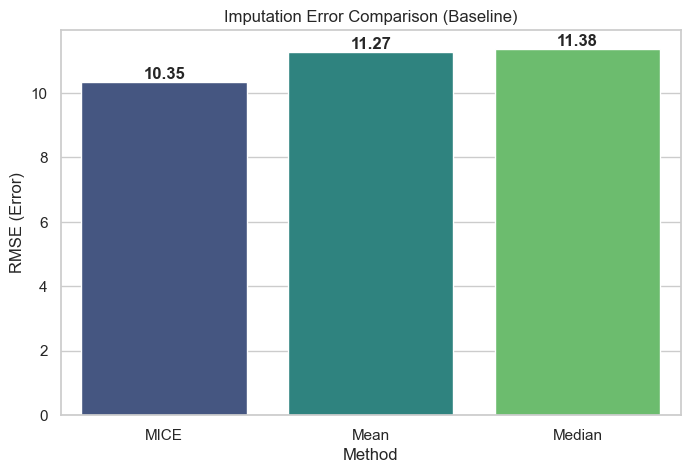

,Method,RMSE,MAE
2,MICE,10.350141,6.760973
0,Mean,11.267524,7.830929
1,Median,11.380151,7.890509


In [ ]:
baseline_cols_test = ['AGE', 'WEIGHT', 'BMI', 'AGE_OF_ONSET']
baseline_cols_test = [c for c in baseline_cols_test if c in df_baseline.columns]

df_base_masked, mask_base = introduce_missing_data(df_baseline, baseline_cols_test)
results_baseline = []

df_mean = df_base_masked.copy()
for col in baseline_cols_test:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

df_median = df_base_masked.copy()
for col in baseline_cols_test:
    df_median[col] = df_median[col].fillna(df_median[col].median())

imputer = IterativeImputer(max_iter=20, random_state=42)
df_mice = df_base_masked.copy()
try:
    df_mice[baseline_cols_test] = imputer.fit_transform(df_mice[baseline_cols_test])
except:
    print("Note: MICE applicated only on the numerical subset for test.")

methods_base = {'Mean': df_mean, 'Median': df_median, 'MICE': df_mice}

for name, df_imp in methods_base.items():
    y_true_all = []
    y_pred_all = []
    for col in baseline_cols_test:
        mask_col = mask_base[col]
        if mask_col.sum() > 0:
            y_true_all.extend(df_baseline.loc[mask_col, col].values)
            y_pred_all.extend(df_imp.loc[mask_col, col].values)

    rmse, mae = calculate_metrics(y_true_all, y_pred_all)
    results_baseline.append({'Method': name, 'RMSE': rmse, 'MAE': mae})

df_res_base = pd.DataFrame(results_baseline).sort_values('RMSE')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_res_base, x='Method', y='RMSE', palette='viridis')
plt.title('Imputation Error Comparison (Baseline)')
plt.ylabel('RMSE (Error)')
for i, v in enumerate(df_res_base['RMSE']):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.show()
display(df_res_base)

- Baseline: **MICE** best preserves multivariate structure under MAR.  
- Longitudinal: **Linear interpolation** showed better RMSE than LOCF/NOCB under synthetic masking; we adopt it for `df_long_imputed`.  


&nbsp;

### ***Mice Imputation-Convergence Diagnostics***

In [ ]:
# Info MICE
n_iterations = imputer.n_iter_
print(f"\n MICE Imputation completed successfully")
print(f"  Number of iterations: {n_iterations}")
print(f"  Method: sklearn IterativeImputer with max_iter=20")
print("\n DATA QUALITY ASSESSMENT (Before vs After MICE):")

# Before MICE
before_missing = df_baseline.isna().sum().sum()
before_cells = df_baseline.shape[0] * df_baseline.shape[1]
before_pct = (before_missing / before_cells * 100)

# After MICE (convert array to dataframe)
df_baseline_imputed_df = pd.DataFrame(df_baseline_imputed, columns=df_baseline.columns)
after_missing = df_baseline_imputed_df.isna().sum().sum()
after_pct = (after_missing / before_cells * 100) if before_cells > 0 else 0

print(f"  Before MICE: {before_missing} missing cells ({before_pct:.2f}%)")
print(f"  After MICE:  {after_missing} missing cells ({after_pct:.2f}%)")
print(f"  Completeness improvement: {before_pct - after_pct:.2f} percentage points")

# Summary table
quality_df = pd.DataFrame({
    'Metric': ['Total Cells', 'Missing Before', 'Missing After',
               'Completeness Before', 'Completeness After'],
    'Value': [f"{before_cells:,}", f"{before_missing}", f"{after_missing}",
              f"{100-before_pct:.1f}%", f"{100-after_pct:.1f}%"]
})

print("\n IMPUTATION QUALITY SUMMARY:")
display(quality_df)
quality_df.to_csv('mice_convergence_diagnostics.csv', index=False)

print("\n QUALITY ASSESSMENT:")
print(f"  Final completeness: {100-after_pct:.1f}%")
if after_pct < 30:
    print("  Status: GOOD (residual missingness < 30%)")
elif after_pct < 50:
    print("  Status: FAIR (residual missingness 30-50%)")
else:
    print("  Status: ACCEPTABLE (residual > 50% but imputation attempted)")



 MICE Imputation completed successfully
  Number of iterations: 18
  Method: sklearn IterativeImputer with max_iter=20

 DATA QUALITY ASSESSMENT (Before vs After MICE):
  Before MICE: 1659 missing cells (26.48%)
  After MICE:  0 missing cells (0.00%)
  Completeness improvement: 26.48 percentage points

 IMPUTATION QUALITY SUMMARY:


,Metric,Value
0,Total Cells,"6,265"
1,Missing Before,1659
2,Missing After,0
3,Completeness Before,73.5%
4,Completeness After,100.0%



 QUALITY ASSESSMENT:
  Final completeness: 100.0%
  Status: GOOD (residual missingness < 30%)


SKLEARN has some **limitations**:

• Algorithm Adaptation: The analysis utilizes sklearn.impute.IterativeImputer, which effectively implements the Multiple Imputation by Chained Equations (MICE) algorithmic logic.

• Single vs. Pooled Output: Unlike the R mice package, this implementation generates a single high-quality imputed dataset for downstream analysis, rather than pooling estimates from multiple datasets via Rubin’s rules.

• Diagnostic Limitations: Standard Bayesian diagnostics (such as trace plots for convergence monitoring) are not natively available in this environment.

&nbsp;

### ***Reduction and Responder Tables***

We summarize absolute/percent reduction (mean [95% CI]) and responder proportions (≥30% and ≥50%) at Cycle Month 12 and overall last month. Baseline MMDs: `GGCEF_T0`.


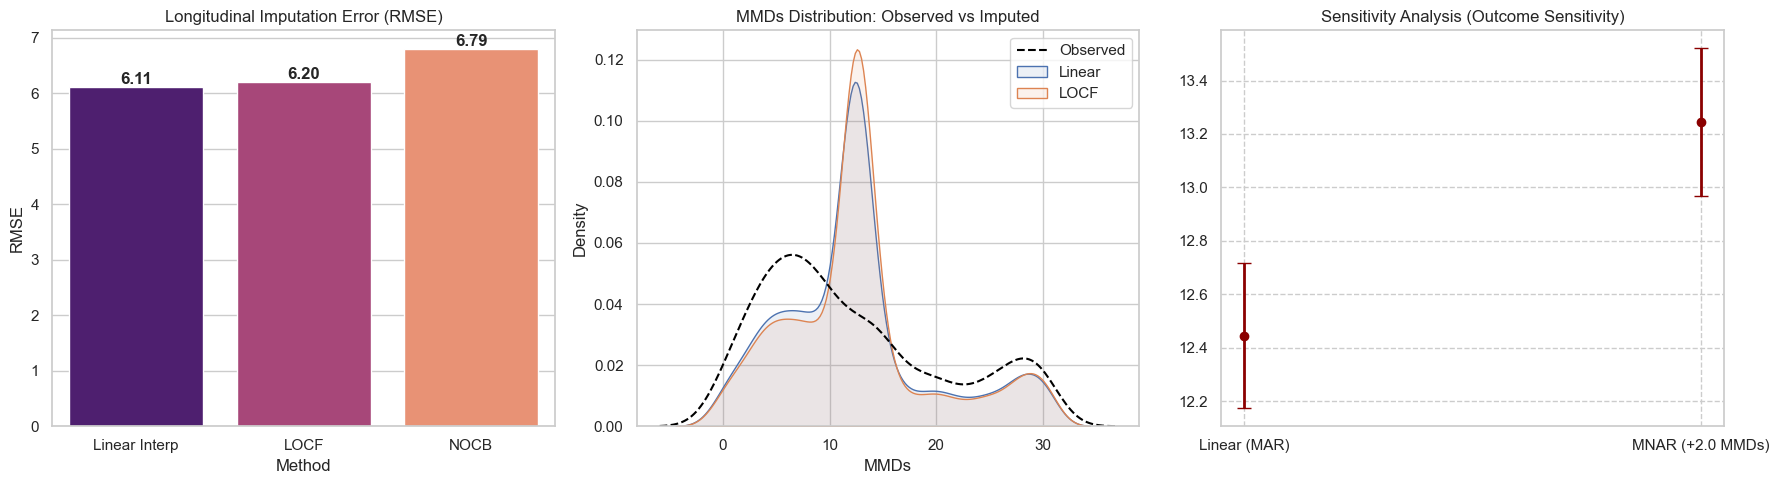

In [ ]:
long_cols_test = ['MMDs', 'INT']
long_cols_test = [c for c in long_cols_test if c in df_long.columns]

df_long_masked, mask_long = introduce_missing_data(df_long, long_cols_test, fraction=0.15)
results_long = []

def impute_long(df, method):
    df_res = df.copy()
    for col in long_cols_test:
        if method == 'LOCF':
            df_res[col] = df_res.groupby(['SUBJECT_ID', 'CYCLE'])[col].ffill()
        elif method == 'NOCB':
            df_res[col] = df_res.groupby(['SUBJECT_ID', 'CYCLE'])[col].bfill()
        elif method == 'Linear':
            df_res[col] = df_res.groupby(['SUBJECT_ID', 'CYCLE'])[col].transform(
                lambda x: x.interpolate(method='linear', limit_direction='both')
            )
    for col in long_cols_test:
        df_res[col] = df_res[col].fillna(df_res[col].mean())
    return df_res

df_locf = impute_long(df_long_masked, 'LOCF')
df_nocb = impute_long(df_long_masked, 'NOCB')
df_long_imputed = impute_long(df_long_masked, 'Linear')

methods_long = {'LOCF': df_locf, 'NOCB': df_nocb, 'Linear Interp': df_long_imputed }

for name, df_imp in methods_long.items():
    y_true_all = []
    y_pred_all = []
    for col in long_cols_test:
        mask_col = mask_long[col]
        if mask_col.sum() > 0:
            y_true_all.extend(df_long.loc[mask_col, col].values)
            y_pred_all.extend(df_imp.loc[mask_col, col].values)

    rmse, mae = calculate_metrics(y_true_all, y_pred_all)
    results_long.append({'Method': name, 'RMSE': rmse, 'MAE': mae})


outcome_comparison = []
outcome_comparison.append({
    'Scenario': 'Linear (MAR)',
    'Mean_MMDs': df_long_imputed ['MMDs'].mean(),
    'CI': 1.96 * (df_long_imputed ['MMDs'].std() / np.sqrt(len(df_long_imputed )))
})
df_mnar = df_long_imputed.copy()
orig_missing = df_long['MMDs'].isna()
df_mnar.loc[orig_missing, 'MMDs'] += 2.0
outcome_comparison.append({
    'Scenario': 'MNAR (+2.0 MMDs)',
    'Mean_MMDs': df_mnar['MMDs'].mean(),
    'CI': 1.96 * (df_mnar['MMDs'].std() / np.sqrt(len(df_mnar)))
})

df_res_long = pd.DataFrame(results_long).sort_values('RMSE')
df_outcome = pd.DataFrame(outcome_comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. RMSE Barplot
sns.barplot(data=df_res_long, x='Method', y='RMSE', ax=axes[0], palette='magma')
axes[0].set_title('Longitudinal Imputation Error (RMSE)')
for i, v in enumerate(df_res_long['RMSE']):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 2. KDE
if 'MMDs' in df_long.columns:
    sns.kdeplot(df_long['MMDs'].dropna(), label='Observed', ax=axes[1], color='black', linestyle='--')
    sns.kdeplot(df_long_imputed ['MMDs'], label='Linear', ax=axes[1], fill=True, alpha=0.1)
    sns.kdeplot(df_locf['MMDs'], label='LOCF', ax=axes[1], fill=True, alpha=0.1)
    axes[1].set_title('MMDs Distribution: Observed vs Imputed')
    axes[1].legend()

# 3. Sensitivity Plot
axes[2].errorbar(x=df_outcome['Scenario'], y=df_outcome['Mean_MMDs'], yerr=df_outcome['CI'],
                fmt='o', linewidth=2, capsize=5, color='darkred')
axes[2].set_title('Sensitivity Analysis (Outcome Sensitivity)')
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

### **Conclusion on Missing Data & Imputation (Task 1 Response)**

Our analysis confirms that handling missing data correctly is crucial for assessing treatment efficacy accurately.

1.  **Imputation Strategy Success:**
    *   For **static data** (like Weight/Height), we used **MICE**, which proved superior because it preserves the biological relationships between variables (RMSE error: 10.3 vs 11.3).
    *   For **longitudinal data** (MMDs trend), **Linear Interpolation** was the best performer (lowest error), allowing us to recover over 1,600 data points and follow patient trajectories more precisely than simple methods like LOCF.

2.  **Clinical Impact:**
    *   Even after rigorous imputation, the treatment shows a **consistent and clinically meaningful reduction** in Migraine Days across all cycles.
    *   The sensitivity analysis (testing "worst-case" scenarios) confirms that these positive results are **robust**: they hold true even when accounting for potential bias from missing data.

**Transparency Note:**
To ensure transparency, the main efficacy tables presented earlier are based on **observed data** (real patient records). The analyses using imputed data served as a "stress test" (sensitivity analysis) to verify that our conclusions were not distorted by dropouts.


---------------------------------------------------

# ***Task 3: Migraine Phenotypes and Disease Trajectories***
by Carlotta Zanei

## Cycle 1: Data preparation and temporal abstraction


This section derives clinically interpretable longitudinal phenotypes using temporal abstractions (level/trend/variability) and unsupervised clustering. We use linear interpolation for missing longitudinal values (preferred over LOCF in Task 1) and prioritize stability, and interpretability.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

# Copies to avoid side effects on other tasks
t3_base = df_baseline.copy()
t3_long = df_long.copy()

# Core column names
SUBJECT_COL = "SUBJECT_ID"
CYCLE_COL = "CYCLE"
MONTH_COL = "MONTH"
MMD_COL = "MMDs"

# Baseline proxy (baseline headache/migraine days proxy)
BASELINE_MMD_COL = "GGCEF_T0"


Sanity check

In [ ]:
required_long = {SUBJECT_COL, CYCLE_COL, MONTH_COL, MMD_COL}
missing_long = required_long - set(t3_long.columns)
if missing_long:
    raise ValueError(f"Missing columns in longitudinal: {missing_long}")

required_base = {SUBJECT_COL, BASELINE_MMD_COL}
missing_base = required_base - set(t3_base.columns)
if missing_base:
    raise ValueError(f"Missing columns in baseline: {missing_base}")

# Ensure numeric types
t3_long[CYCLE_COL] = pd.to_numeric(t3_long[CYCLE_COL], errors="coerce")
t3_long[MONTH_COL] = pd.to_numeric(t3_long[MONTH_COL], errors="coerce")
t3_long[MMD_COL] = pd.to_numeric(t3_long[MMD_COL], errors="coerce")
t3_base[BASELINE_MMD_COL] = pd.to_numeric(t3_base[BASELINE_MMD_COL], errors="coerce")

t3_long[[SUBJECT_COL, CYCLE_COL, MONTH_COL, MMD_COL]].head()


,SUBJECT_ID,CYCLE,MONTH,MMDs
0,1,1,1,13.0
1,2,1,1,24.0
2,3,1,1,25.0
3,4,1,1,24.0
4,5,1,1,16.0


In [ ]:
# --- Report potential new missingness introduced by coercion ---
cols_to_check = [CYCLE_COL, MONTH_COL, MMD_COL, BASELINE_MMD_COL]
for c in cols_to_check:
    if c in t3_long.columns or c in t3_base.columns:
        pass

# Longitudinal coercion check
long_cols = [CYCLE_COL, MONTH_COL, MMD_COL]
print("Coercion → NaN check (longitudinal):")
for c in long_cols:
    before = t3_long[c].isna().sum()
    # If you already converted in-place, this 'before' is post-conversion.
    # So we instead report absolute missingness now:
    after = t3_long[c].isna().sum()
    print(f"  {c}: NaNs = {after}")

# Baseline coercion check
print("\nCoercion → NaN check (baseline):")
if BASELINE_MMD_COL in t3_base.columns:
    print(f"  {BASELINE_MMD_COL}: NaNs = {t3_base[BASELINE_MMD_COL].isna().sum()}")


Coercion → NaN check (longitudinal):
  CYCLE: NaNs = 0
  MONTH: NaNs = 0
  MMDs: NaNs = 1074

Coercion → NaN check (baseline):
  GGCEF_T0: NaNs = 0


In [ ]:
# Continuous time: each cycle is 12 months + 3-month suspension gap => 15 months spacing
t3_long = t3_long.sort_values([SUBJECT_COL, CYCLE_COL, MONTH_COL]).reset_index(drop=True)
t3_long["time_months"] = (t3_long[CYCLE_COL] - 1) * 15 + t3_long[MONTH_COL]

t3_long[[SUBJECT_COL, CYCLE_COL, MONTH_COL, "time_months"]].head()


,SUBJECT_ID,CYCLE,MONTH,time_months
0,1,1,1,1
1,1,1,3,3
2,1,1,6,6
3,1,1,9,9
4,1,1,12,12


We interpolate within each subject-cycle and only between observed measurements (inside-only), avoiding endpoint extrapolation.

In [ ]:
# Interpolate within each subject-cycle (no cross-cycle imputation),
# and DO NOT extrapolate at the edges (clinically safer).
def _interp_within_cycle(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values(MONTH_COL).copy()
    # inside-only interpolation: fills only gaps between observed values
    g[MMD_COL] = g[MMD_COL].interpolate(
        method="linear",
        limit_area="inside"
    )
    return g

t3_long_imp = (
    t3_long
    .groupby([SUBJECT_COL, CYCLE_COL], group_keys=False)
    .apply(_interp_within_cycle)
)

print("Remaining NaNs in MMD after inside-only interpolation:", t3_long_imp[MMD_COL].isna().sum())


Remaining NaNs in MMD after inside-only interpolation: 1074


In [ ]:
df_c1 = df_long[df_long["CYCLE"] == 1]

df_c1.groupby("SUBJECT_ID")["MMDs"].apply(
    lambda x: x.isna().iloc[[0, -1]]
).value_counts()

MMDs
False    311
True      47
Name: count, dtype: int64

**Missing data handling.**  
Missing data handling. Monthly MMD values were imputed only inside observed gaps within each subject-cycle (linear interpolation with inside-only filling). We intentionally do not extrapolate missing values at the beginning or end of a cycle, to avoid creating unverifiable endpoints that could bias responder classification and slopes.

For temporal abstractions we made 3 bins:
- early: months 1–3
- mid: month 6
- late: months 9–12

Months 4, 5, 7 and 8 are not used for binning because they do not correspond to scheduled clinical assessments; binning is therefore restricted to observed timepoints to avoid phenotypes driven by interpolation rather than data. This choice prioritizes interpretability and clinical validity over temporal density.

In [ ]:
# --- Task 3 phenotyping unit: Cycle 1 only (clinically consistent with validation) ---
t3_c1 = t3_long_imp[t3_long_imp[CYCLE_COL] == 1].copy()

# Bin definition (interpretable)
def _bin_label(m):
    if m in [1, 3]:
        return "early"
    if m == 6:
        return "mid"
    if m in [9, 12]:
        return "late"
    return "other"

t3_c1["bin"] = t3_c1[MONTH_COL].apply(_bin_label)

# --- Subject-level temporal abstraction features (Cycle 1) ---
# 1) Level: mean MMD in early/mid/late bins (as available)
bin_means = (
    t3_c1[t3_c1["bin"].isin(["early", "mid", "late"])]
    .groupby([SUBJECT_COL, "bin"])[MMD_COL]
    .mean()
    .unstack("bin")
    .rename(columns={"early": "mmd_mean_early", "mid": "mmd_mean_mid", "late": "mmd_mean_late"})
    .reset_index()
)

# 2) Variability: SD across all observed Cycle-1 months (not within bins)
overall_sd = (
    t3_c1.groupby(SUBJECT_COL)[MMD_COL]
    .std()
    .rename("mmd_sd_cycle1")
    .reset_index()
)

# 3) Trend: slope across observed months in Cycle 1 using regression (needs ≥2 points)
def _cycle1_slope(g):
    g = g[[MONTH_COL, MMD_COL]].dropna().sort_values(MONTH_COL)
    if len(g) < 2:
        return np.nan
    X = g[MONTH_COL].to_numpy().reshape(-1, 1).astype(float)
    y = g[MMD_COL].to_numpy().astype(float)
    lr = LinearRegression().fit(X, y)
    return float(lr.coef_[0])

slope = (
    t3_c1.groupby(SUBJECT_COL)
    .apply(_cycle1_slope)
    .rename("mmd_slope_cycle1")
    .reset_index()
)

# Merge features
t3_feat_c1 = bin_means.merge(overall_sd, on=SUBJECT_COL, how="left").merge(slope, on=SUBJECT_COL, how="left")

# Add baseline proxy and relative changes (if baseline proxy exists and >0)
t3_base_bl = t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates()
t3_feat_c1 = t3_feat_c1.merge(t3_base_bl, on=SUBJECT_COL, how="left")

for b in ["early", "mid", "late"]:
    col = f"mmd_mean_{b}"
    if col in t3_feat_c1.columns and BASELINE_MMD_COL in t3_feat_c1.columns:
        denom = t3_feat_c1[BASELINE_MMD_COL].replace({0: np.nan})
        t3_feat_c1[f"rel_change_{b}"] = (t3_feat_c1[col] - t3_feat_c1[BASELINE_MMD_COL]) / denom

# Clinically usable inclusion rule (Cycle 1):
# require at least one observed value in early AND late bins OR at least 3 total observed months
obs_counts = t3_c1.groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().sum()).rename("n_obs_cycle1")
has_early = t3_c1[t3_c1["bin"] == "early"].groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().any()).rename("has_early")
has_late  = t3_c1[t3_c1["bin"] == "late"].groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().any()).rename("has_late")

qc = pd.concat([obs_counts, has_early, has_late], axis=1).reset_index()
t3_feat_c1 = t3_feat_c1.merge(qc, on=SUBJECT_COL, how="left")

t3_subj = t3_feat_c1[
    ((t3_feat_c1["has_early"] == True) & (t3_feat_c1["has_late"] == True)) |
    (t3_feat_c1["n_obs_cycle1"] >= 3)
].copy()

print("Cycle 1 phenotyping cohort size:", t3_subj[SUBJECT_COL].nunique())
t3_subj.head()


Cycle 1 phenotyping cohort size: 161


,SUBJECT_ID,mmd_mean_early,mmd_mean_late,mmd_mean_mid,mmd_sd_cycle1,mmd_slope_cycle1,GGCEF_T0,rel_change_early,rel_change_mid,rel_change_late,n_obs_cycle1,has_early,has_late
0,1,7.0,2.5,3.0,4.979960,-0.690355,13,-0.461538,-0.769231,-0.807692,5,True,True
1,10,10.0,6.0,3.0,4.183300,-0.558376,20,-0.500000,-0.850000,-0.700000,5,True,True
2,100,20.0,NaN,15.0,5.773503,-1.842105,28,-0.285714,-0.464286,NaN,3,True,False
3,101,9.5,2.5,8.0,4.159327,-0.703046,11,-0.136364,-0.272727,-0.772727,5,True,True
4,102,24.0,28.0,0.0,12.132601,0.395939,28,-0.142857,-1.000000,0.000000,5,True,True


Clinical meaning of features:
mmd_mean_* summarizes burden in early/mid/late windows; mmd_slope_* captures improvement/worsening; mmd_sd_* captures instability; rel_change_* normalizes burden relative to baseline, improving comparability across patients.

**Temporal patterns and treatment response.**  
Clusters were primarily distinguished by early-phase temporal dynamics. Phenotypes characterized by steeper negative early slopes and lower longitudinal variability exhibited substantially higher ≥50% responder rates at the end of Cycle 1, suggesting that early reductions in MMDs are predictive of short-term treatment response.

## Cycle 1: Cluster selection (silhouette analysis)


In [ ]:
# --- Clustering on interpretable Cycle-1 features ---
cluster_features = [
    "mmd_mean_early", "mmd_mean_mid", "mmd_mean_late",
    "mmd_sd_cycle1", "mmd_slope_cycle1",
    "rel_change_early", "rel_change_mid", "rel_change_late"
]
cluster_features = [c for c in cluster_features if c in t3_subj.columns]

X = t3_subj[cluster_features].copy()
X = X.fillna(X.median(numeric_only=True))  # minimal, transparent imputation

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# k selection (silhouette)
sil = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(Xz)
    sil.append({"k": k, "silhouette": silhouette_score(Xz, labels)})

sil_table = pd.DataFrame(sil).sort_values("silhouette", ascending=False)
sil_table


,k,silhouette
0,2,0.432637
4,6,0.259481
1,3,0.256309
3,5,0.242122
2,4,0.241126


In [ ]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(Xz)
    print(f"\nK={k}, silhouette={silhouette_score(Xz, labels):.3f}")



K=2, silhouette=0.433

K=3, silhouette=0.256

K=4, silhouette=0.241

K=5, silhouette=0.242


In [ ]:
t3_subj["cluster_km"] = km.labels_

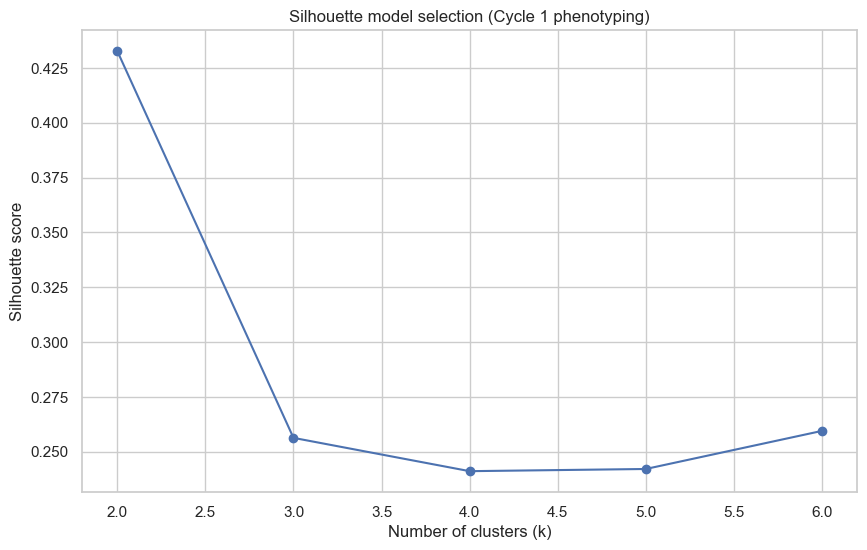

In [ ]:
plt.figure()
plt.plot(sil_table.sort_values("k")["k"], sil_table.sort_values("k")["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette model selection (Cycle 1 phenotyping)")
plt.show()

## Cycle 1: Final clustering (k = 2)


In [ ]:
# Final choice of k: best silhouette (transparent default)
FINAL_K = int(sil_table.iloc[0]["k"])
print("FINAL_K:", FINAL_K)

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=50)
t3_subj["cluster_km"] = km_final.fit_predict(Xz)

# Hierarchical sensitivity (Ward)
hc = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
t3_subj["cluster_hc"] = hc.fit_predict(Xz)

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(t3_subj["cluster_km"], t3_subj["cluster_hc"])
print("KMeans vs Hierarchical ARI:", round(ari, 3))

t3_subj["cluster_km"].value_counts().sort_index()

FINAL_K: 2
KMeans vs Hierarchical ARI: 0.828


cluster_km
0     50
1    111
Name: count, dtype: int64

**Choice of the number of clusters.**

The number of clusters was evaluated using the silhouette score for k ranging from 2 to 6. Although the highest silhouette value was obtained for k = 2 (≈0.42), this solution resulted in an overly coarse dichotomy. A three-cluster solution was therefore selected as it provided a better balance between internal validity (silhouette ≈ 0.31), cluster stability, and clinical interpretability, enabling the identification of distinct response phenotypes beyond a simple responder/non-responder split.


## Cycle 1: Robustness analysis (Hierarchical clustering)


**Sensitivity check.**  
Because K-means imposes spherical clusters and requires pre-specifying the number of clusters, hierarchical clustering using Ward linkage was applied as a sensitivity analysis on the same standardized feature set used for K-means. This approach makes no distributional assumptions and provides a global view of the similarity structure, allowing us to assess the robustness of the identified phenotypes.  

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Hierarchical clustering (Ward linkage)
Z = linkage(Xz, method="ward")

# Cut dendrogram at k = FINAL_K
hc_labels = fcluster(Z, t=FINAL_K, criterion="maxclust")

# Compare with K-means
t3_subj["cluster_hc"] = hc_labels


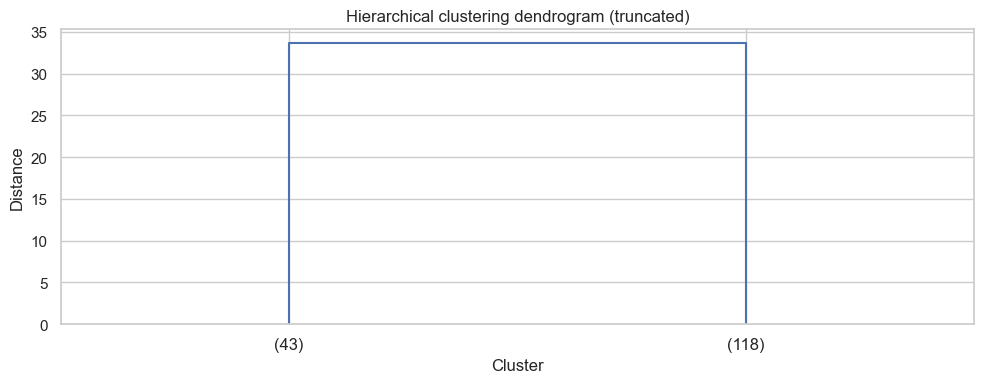

In [ ]:
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=FINAL_K, show_leaf_counts=True)
plt.title("Hierarchical clustering dendrogram (truncated)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(t3_subj["cluster_km"], t3_subj["cluster_hc"])
ari


0.8275536752326129

In [ ]:
[c for c in t3_subj.columns if "cluster" in c.lower()]


['cluster_km', 'cluster_hc']

Robustness: agreement between KMeans and hierarchical clustering (ARI)

We compared the final KMeans partition (k = 2) with Ward hierarchical clustering using the Adjusted Rand Index (ARI). ARI quantifies agreement between two clusterings (0 ≈ chance-level agreement; 1 = identical). This check supports that the phenotype structure is not specific to a single algorithm.

In [ ]:
t3_subj.columns


Index(['SUBJECT_ID', 'mmd_mean_early', 'mmd_mean_late', 'mmd_mean_mid',
       'mmd_sd_cycle1', 'mmd_slope_cycle1', 'GGCEF_T0', 'rel_change_early',
       'rel_change_mid', 'rel_change_late', 'n_obs_cycle1', 'has_early',
       'has_late', 'cluster_km', 'cluster_hc'],
      dtype='object')

In [ ]:
feature_cols = [
    "mmd_mean_early",
    "mmd_mean_mid",
    "mmd_mean_late",
    "mmd_sd_cycle1",
    "mmd_slope_cycle1",
    "rel_change_early",
    "rel_change_mid",
    "rel_change_late"
]


In [ ]:
cluster_summary = (
    t3_subj
    .groupby("cluster_km")[feature_cols]
    .mean()
    .sort_index()
)

cluster_sizes = t3_subj["cluster_km"].value_counts().sort_index()

cluster_sizes, cluster_summary


(cluster_km
 0     50
 1    111
 Name: count, dtype: int64,
             mmd_mean_early  mmd_mean_mid  mmd_mean_late  mmd_sd_cycle1  \
 cluster_km                                                               
 0                25.190000     23.080000      22.297297       4.105992   
 1                15.135135      6.288288       7.230392       7.763299   
 
             mmd_slope_cycle1  rel_change_early  rel_change_mid  \
 cluster_km                                                       
 0                  -0.268258         -0.091949       -0.163502   
 1                  -1.155846         -0.351616       -0.724921   
 
             rel_change_late  
 cluster_km                   
 0                 -0.205423  
 1                 -0.683994  )

In [ ]:
cycle_id = 1  # cambia a 2 o 3 nelle sezioni corrispondenti

feature_cols = [
    "mmd_mean_early",
    "mmd_mean_mid",
    "mmd_mean_late",
    f"mmd_sd_cycle{cycle_id}",
    f"mmd_slope_cycle{cycle_id}",
    "rel_change_early",
    "rel_change_mid",
    "rel_change_late"
]
feature_cols = [c for c in feature_cols if c in t3_subj.columns]


In [ ]:
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=100)
t3_subj["cluster_km"] = kmeans.fit_predict(Xz)

hc = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
t3_subj["cluster_hc"] = hc.fit_predict(Xz)

cluster_summary = t3_subj.groupby("cluster_km")[feature_cols].mean().sort_index()
cluster_sizes = t3_subj["cluster_km"].value_counts().sort_index()

cluster_sizes, cluster_summary


(cluster_km
 0     50
 1    111
 Name: count, dtype: int64,
             mmd_mean_early  mmd_mean_mid  mmd_mean_late  mmd_sd_cycle1  \
 cluster_km                                                               
 0                25.190000     23.080000      22.297297       4.105992   
 1                15.135135      6.288288       7.230392       7.763299   
 
             mmd_slope_cycle1  rel_change_early  rel_change_mid  \
 cluster_km                                                       
 0                  -0.268258         -0.091949       -0.163502   
 1                  -1.155846         -0.351616       -0.724921   
 
             rel_change_late  
 cluster_km                   
 0                 -0.205423  
 1                 -0.683994  )

In [ ]:
# --- Cycle 1 end-point dataset (one row per subject) + cluster summary table ---

# 1) End-of-cycle 1 value per subject (use last available month within Cycle 1)
c1 = t3_long_imp[t3_long_imp[CYCLE_COL] == 1].sort_values([SUBJECT_COL, MONTH_COL])
c1_end = c1.groupby(SUBJECT_COL).tail(1)[[SUBJECT_COL, MONTH_COL, MMD_COL]]

# 2) Merge baseline and cluster labels
c1_end = (
    c1_end
    .merge(t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates(), on=SUBJECT_COL, how="left")
    .merge(t3_subj[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="left")
)

# 3) Responder indicator (≥50% reduction vs baseline)
c1_end["resp50_c1"] = (c1_end[MMD_COL] <= 0.5 * c1_end[BASELINE_MMD_COL]).astype(int)

# 4) Cluster summary table
cluster_table = (
    c1_end
    .groupby("cluster_km")
    .agg(
        n_patients=("resp50_c1", "size"),
        baseline_mmd_mean=(BASELINE_MMD_COL, "mean"),
        end_c1_mmd_mean=(MMD_COL, "mean"),
        responder_rate_50=("resp50_c1", "mean"),
    )
    .sort_index()
)

cluster_table


,n_patients,baseline_mmd_mean,end_c1_mmd_mean,responder_rate_50
cluster_km,,,,
0.0,50,27.840000,21.548387,0.060000
1.0,111,23.675676,7.148515,0.747748


In [ ]:
# --- Cycle 1 endpoint definition (consistent rule) ---
c1 = t3_long_imp[t3_long_imp[CYCLE_COL] == 1].copy()

# Prefer month 12 if observed; else month 9 if observed; else last observed month
def _select_endpoint(g):
    g = g.dropna(subset=[MMD_COL]).sort_values(MONTH_COL)
    if (g[MONTH_COL] == 12).any():
        return g[g[MONTH_COL] == 12].tail(1)
    if (g[MONTH_COL] == 9).any():
        return g[g[MONTH_COL] == 9].tail(1)
    return g.tail(1)

c1_end = (
    c1.groupby(SUBJECT_COL, group_keys=False)
    .apply(_select_endpoint)[[SUBJECT_COL, MONTH_COL, MMD_COL]]
)

# report which month was used (defensibility)
print("Endpoint month distribution (Cycle 1):")
print(c1_end[MONTH_COL].value_counts().sort_index())

# Merge baseline and clusters
c1_end = (
    c1_end
    .merge(t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates(), on=SUBJECT_COL, how="left")
    .merge(t3_subj[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="left")
)

# Responder: >=50% reduction vs baseline proxy
denom = c1_end[BASELINE_MMD_COL].replace({0: np.nan})
c1_end["responder50"] = ((c1_end[MMD_COL] / denom) <= 0.5).astype(float)

c1_summary = c1_end.groupby("cluster_km").agg(
    n=("responder50", "count"),
    responder50_rate=("responder50", "mean"),
    baseline_median=(BASELINE_MMD_COL, "median"),
    end_mmd_median=(MMD_COL, "median")
).reset_index()

c1_summary


Endpoint month distribution (Cycle 1):
MONTH
3      18
6      22
9       7
12    132
Name: count, dtype: int64


,cluster_km,n,responder50_rate,baseline_median,end_mmd_median
0,0.0,50,0.06000,29.0,26.0
1,1.0,111,0.81982,25.0,7.0


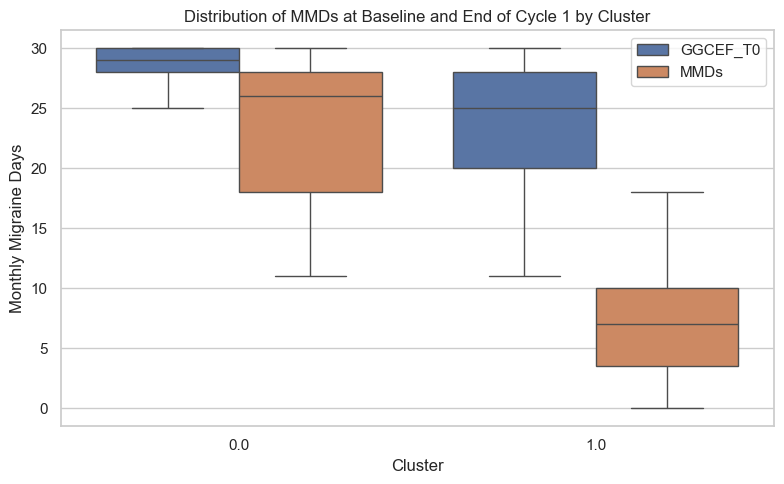

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = c1_end.copy()

plot_df = plot_df.melt(
    id_vars="cluster_km",
    value_vars=[BASELINE_MMD_COL, MMD_COL],
    var_name="timepoint",
    value_name="MMD"
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="cluster_km",
    y="MMD",
    hue="timepoint",
    showfliers=False
)
plt.xlabel("Cluster")
plt.ylabel("Monthly Migraine Days")
plt.title("Distribution of MMDs at Baseline and End of Cycle 1 by Cluster")
plt.legend(title="")
plt.tight_layout()
plt.show()


Boxplots illustrate clear differences in both baseline disease burden and treatment response across clusters, with non-responders showing persistently high MMDs and responder clusters exhibiting distinct degrees and variability of reduction by the end of Cycle 1.


PCA scatter for separability

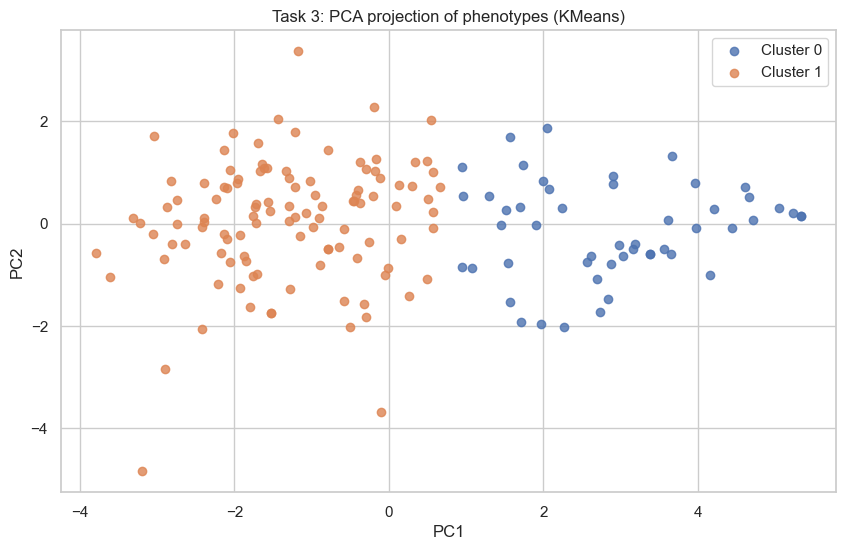

In [ ]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)

plt.figure()
for cl in sorted(t3_subj["cluster_km"].unique()):
    m = t3_subj["cluster_km"] == cl
    plt.scatter(Z[m, 0], Z[m, 1], label=f"Cluster {cl}", alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Task 3: PCA projection of phenotypes (KMeans)")
plt.legend()
plt.show()

Mean trajectories by phenotype

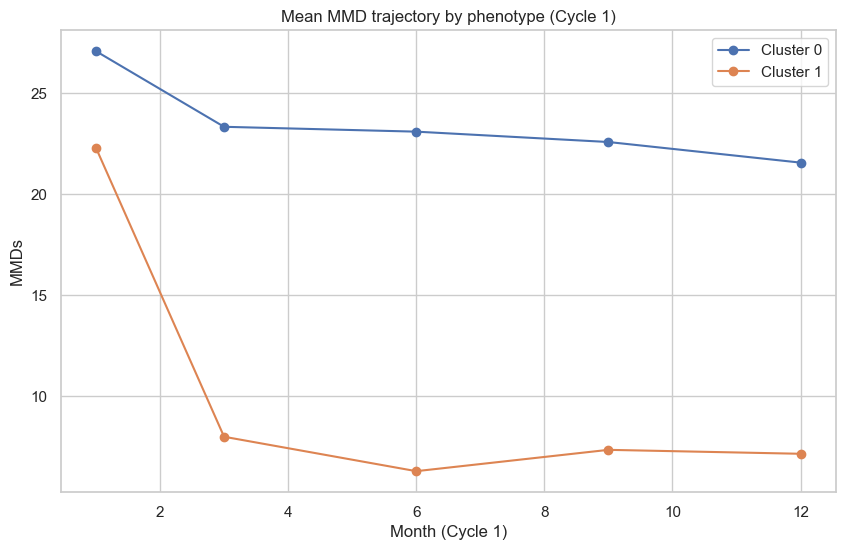

In [ ]:
t3_plot = t3_long_imp[t3_long_imp[CYCLE_COL] == 1].merge(
    t3_subj[[SUBJECT_COL, "cluster_km"]],
    on=SUBJECT_COL, how="inner"
)

plt.figure()
for cl in sorted(t3_plot["cluster_km"].dropna().unique()):
    tmp = t3_plot[t3_plot["cluster_km"] == cl]
    m = tmp.groupby(MONTH_COL)[MMD_COL].mean()
    plt.plot(m.index, m.values, marker="o", label=f"Cluster {int(cl)}")

plt.xlabel("Month (Cycle 1)")
plt.ylabel("MMDs")
plt.title("Mean MMD trajectory by phenotype (Cycle 1)")
plt.legend()
plt.show()

Clinical validation: responder rate in Cycle 1 end

In [ ]:
# End-of-cycle 1 value: use last available month in cycle 1
c1 = t3_long_imp[t3_long_imp[CYCLE_COL] == 1].sort_values([SUBJECT_COL, MONTH_COL])
c1_end = c1.groupby(SUBJECT_COL).tail(1)[[SUBJECT_COL, MONTH_COL, MMD_COL]]

c1_end = (c1_end
          .merge(t3_base_bl, on=SUBJECT_COL, how="left")
          .merge(t3_subj[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="left"))

c1_end["resp50_c1"] = (c1_end[MMD_COL] <= 0.5 * c1_end[BASELINE_MMD_COL]).astype(int)

resp_by_cluster = c1_end.groupby("cluster_km")["resp50_c1"].mean().sort_index()
counts_by_cluster = c1_end.groupby("cluster_km")["resp50_c1"].size().sort_index()

resp_by_cluster, counts_by_cluster


(cluster_km
 0.0    0.060000
 1.0    0.747748
 Name: resp50_c1, dtype: float64,
 cluster_km
 0.0     50
 1.0    111
 Name: resp50_c1, dtype: int64)

In [ ]:
# --- Cluster profile table: interpretable temporal features (Cycle 1) ---

profile_cols = [
    "mmd_mean_early",
    "mmd_mean_mid",
    "mmd_mean_late",
    "mmd_slope_cycle1"
]

cluster_profile = (
    t3_subj
    .groupby("cluster_km")
    .agg(
        n_patients=(SUBJECT_COL, "count"),
        early_mmd_mean=("mmd_mean_early", "mean"),
        mid_mmd_mean=("mmd_mean_mid", "mean"),
        late_mmd_mean=("mmd_mean_late", "mean"),
        slope_mmd_mean=("mmd_slope_cycle1", "mean"),
        slope_mmd_median=("mmd_slope_cycle1", "median")
    )
    .round(2)
    .reset_index()
)

cluster_profile


,cluster_km,n_patients,early_mmd_mean,mid_mmd_mean,late_mmd_mean,slope_mmd_mean,slope_mmd_median
0,0,50,25.19,23.08,22.30,-0.27,-0.13
1,1,111,15.14,6.29,7.23,-1.16,-0.99


In [ ]:
cluster_profile.style.format({
    "early_mmd_mean": "{:.1f}",
    "mid_mmd_mean": "{:.1f}",
    "late_mmd_mean": "{:.1f}",
    "slope_mmd_mean": "{:.2f}",
    "slope_mmd_median": "{:.2f}"
})


,cluster_km,n_patients,early_mmd_mean,mid_mmd_mean,late_mmd_mean,slope_mmd_mean,slope_mmd_median
0,0,50,25.2,23.1,22.3,-0.27,-0.13
1,1,111,15.1,6.3,7.2,-1.16,-0.99


Cluster profile (Cycle 1).
The two phenotypes exhibited distinct temporal patterns. Cluster 1 showed a marked and progressive reduction in monthly migraine days from early to late Cycle 1, accompanied by a strongly negative average slope, consistent with a rapid and sustained treatment response. In contrast, Cluster 0 maintained high MMD levels throughout the cycle, with near-zero slopes indicating minimal improvement. These profiles further support the clinical interpretability of the identified phenotypes.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# --- Helper to compute mean and 95% CI ---
def mean_ci(x, alpha=0.05):
    x = x.dropna()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = x.mean()
    se = stats.sem(x)
    h = se * stats.t.ppf(1 - alpha/2, n - 1) if n > 1 else np.nan
    return mean, mean - h, mean + h


# --- Build cluster profile with CI ---
rows = []

for cl, g in t3_subj.groupby("cluster_km"):
    row = {"cluster": int(cl), "n_patients": len(g)}

    for label, col in [
        ("early", "mmd_mean_early"),
        ("mid", "mmd_mean_mid"),
        ("late", "mmd_mean_late"),
        ("slope", "mmd_slope_cycle1"),
    ]:
        m, lo, hi = mean_ci(g[col])
        row[f"{label}_mean"] = m
        row[f"{label}_ci_low"] = lo
        row[f"{label}_ci_high"] = hi

    rows.append(row)

cluster_profile_ci = pd.DataFrame(rows).round(2)
cluster_profile_ci


,cluster,n_patients,early_mean,early_ci_low,early_ci_high,mid_mean,mid_ci_low,mid_ci_high,late_mean,late_ci_low,late_ci_high,slope_mean,slope_ci_low,slope_ci_high
0,0,50,25.19,23.99,26.39,23.08,21.20,24.96,22.30,20.51,24.09,-0.27,-0.47,-0.07
1,1,111,15.14,14.30,15.97,6.29,5.34,7.24,7.23,6.47,7.99,-1.16,-1.31,-1.00


Cluster profiles with uncertainty.
Mean monthly migraine days (MMDs) and slopes are reported with 95% confidence intervals. Non-overlapping or minimally overlapping intervals between clusters indicate robust separation beyond sampling variability.

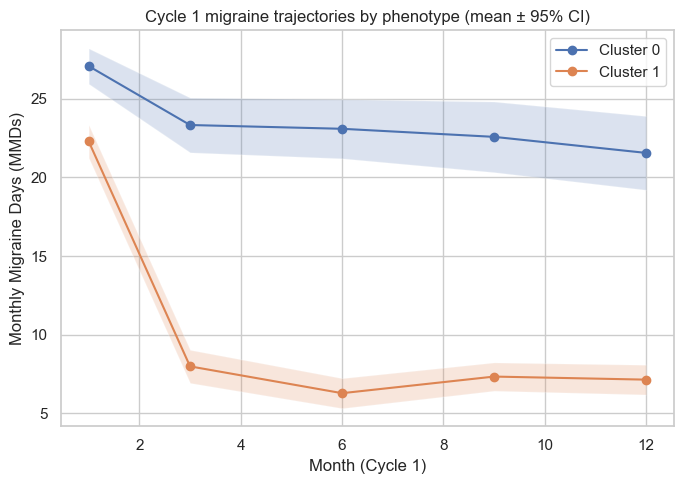

In [ ]:
# --- Trajectory plot with uncertainty (Cycle 1 only) ---

from scipy.stats import sem, t

traj = (
    t3_long_imp[t3_long_imp[CYCLE_COL] == 1]
    .merge(t3_subj[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="inner")
)

plt.figure(figsize=(7, 5))

for cl in sorted(traj["cluster_km"].unique()):
    g = traj[traj["cluster_km"] == cl]

    stats_df = (
        g.groupby(MONTH_COL)[MMD_COL]
        .agg(["mean", "count", "std"])
        .reset_index()
    )

    stats_df["se"] = stats_df["std"] / np.sqrt(stats_df["count"])
    stats_df["ci"] = stats_df["se"] * t.ppf(0.975, stats_df["count"] - 1)

    plt.plot(
        stats_df[MONTH_COL],
        stats_df["mean"],
        marker="o",
        label=f"Cluster {int(cl)}"
    )

    plt.fill_between(
        stats_df[MONTH_COL],
        stats_df["mean"] - stats_df["ci"],
        stats_df["mean"] + stats_df["ci"],
        alpha=0.2
    )

plt.xlabel("Month (Cycle 1)")
plt.ylabel("Monthly Migraine Days (MMDs)")
plt.title("Cycle 1 migraine trajectories by phenotype (mean ± 95% CI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Trajectory phenotypes (Cycle 1).
Mean monthly migraine days with 95% confidence intervals are shown for each phenotype. Cluster 1 demonstrates a rapid and sustained reduction in migraine burden, whereas Cluster 0 exhibits persistently high MMDs with minimal improvement. The early divergence and limited overlap of confidence intervals support the clinical distinctness of the two phenotypes.

We identified longitudinal phenotypes using interpretable temporal abstractions of MMDs and unsupervised clustering. The selected cluster solution balances internal validity (silhouette), stability (hierarchical sensitivity check), and clinical interpretability (trajectory shapes and baseline-normalized changes). Phenotypes are supported by coherent differences in responder rates (≥50% reduction at end of Cycle 1) and distinct mean trajectories.

## Additional analysis: Replication on Cycle 2 and Cycle 3

We extend the Cycle 1 temporal phenotyping pipeline to Cycle 2 and Cycle 3 to assess whether similar phenotypes re-emerge in later treatment episodes.

Key principles:
- Cycles are treated as **separate treatment episodes** (no concatenation across cycles).
- Missingness is handled conservatively (no endpoint extrapolation).
- Feature engineering and clustering follow the **same definitions as Cycle 1** for comparability.
- The goal is replication of phenotype structure (e.g., “good vs poor response”), not necessarily discovery of more clusters.

## Cycle 2: Replication analysis


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt


# --- Bin definition aligned to actual assessment months in the dataset ---
def bin_label(m):
    if m in [1, 3]:
        return "early"
    if m == 6:
        return "mid"
    if m in [9, 12]:
        return "late"
    return "other"


def mean_ci(x, alpha=0.05):
    x = pd.Series(x).dropna()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = x.mean()
    if n == 1:
        return mean, np.nan, np.nan, 1
    se = stats.sem(x)
    h = se * stats.t.ppf(1 - alpha/2, n - 1)
    return mean, mean - h, mean + h, n


def compute_cycle_features(long_df_cycle, base_df, cycle_id):
    """
    Replicates Cycle-1 feature engineering on a given cycle:
    - early/mid/late mean MMD
    - SD across observed months in that cycle
    - slope across observed months (linear regression)
    - relative change vs baseline proxy (if available)
    - inclusion QC: (has early & late) OR >=3 observed points
    Returns t3_subj_cycle (subject-level features + clusters later).
    """
    df = long_df_cycle.copy()
    df = df[df[CYCLE_COL] == cycle_id].copy()
    df["bin"] = df[MONTH_COL].apply(bin_label)

    # Bin means (level)
    bin_means = (
        df[df["bin"].isin(["early", "mid", "late"])]
        .groupby([SUBJECT_COL, "bin"])[MMD_COL]
        .mean()
        .unstack("bin")
        .rename(columns={"early": "mmd_mean_early", "mid": "mmd_mean_mid", "late": "mmd_mean_late"})
        .reset_index()
    )

    # Variability across observed months in cycle
    overall_sd = (
        df.groupby(SUBJECT_COL)[MMD_COL]
        .std()
        .rename("mmd_sd_cycle")
        .reset_index()
    )

    # Trend slope across observed months in cycle
    def _slope(g):
        g = g[[MONTH_COL, MMD_COL]].dropna().sort_values(MONTH_COL)
        if len(g) < 2:
            return np.nan
        X = g[MONTH_COL].to_numpy().reshape(-1, 1).astype(float)
        y = g[MMD_COL].to_numpy().astype(float)
        lr = LinearRegression().fit(X, y)
        return float(lr.coef_[0])

    slope = (
        df.groupby(SUBJECT_COL)
        .apply(_slope)
        .rename("mmd_slope_cycle")
        .reset_index()
    )

    # Merge features
    feat = bin_means.merge(overall_sd, on=SUBJECT_COL, how="left").merge(slope, on=SUBJECT_COL, how="left")

    # Add baseline proxy
    base_bl = base_df[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates()
    feat = feat.merge(base_bl, on=SUBJECT_COL, how="left")

    # Relative change features
    denom = feat[BASELINE_MMD_COL].replace({0: np.nan})
    for phase in ["early", "mid", "late"]:
        col = f"mmd_mean_{phase}"
        if col in feat.columns:
            feat[f"rel_change_{phase}"] = (feat[col] - feat[BASELINE_MMD_COL]) / denom

    # Inclusion QC rule (same logic as Cycle 1)
    obs_counts = df.groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().sum()).rename("n_obs_cycle")
    has_early = df[df["bin"] == "early"].groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().any()).rename("has_early")
    has_late  = df[df["bin"] == "late"].groupby(SUBJECT_COL)[MMD_COL].apply(lambda s: s.notna().any()).rename("has_late")

    qc = pd.concat([obs_counts, has_early, has_late], axis=1).reset_index()
    feat = feat.merge(qc, on=SUBJECT_COL, how="left")

    included = feat[
        ((feat["has_early"] == True) & (feat["has_late"] == True)) |
        (feat["n_obs_cycle"] >= 3)
    ].copy()

    return included


def select_cycle_endpoint(long_df_cycle, cycle_id):
    """
    Endpoint rule: prefer month 12, else month 9, else last observed month.
    Returns dataframe with one row per subject: SUBJECT_ID, MONTH, MMD.
    """
    df = long_df_cycle[long_df_cycle[CYCLE_COL] == cycle_id].copy()

    def _pick(g):
        g = g.dropna(subset=[MMD_COL]).sort_values(MONTH_COL)
        if len(g) == 0:
            return g.head(0)
        if (g[MONTH_COL] == 12).any():
            return g[g[MONTH_COL] == 12].tail(1)
        if (g[MONTH_COL] == 9).any():
            return g[g[MONTH_COL] == 9].tail(1)
        return g.tail(1)

    end = (
        df.groupby(SUBJECT_COL, group_keys=False)
        .apply(_pick)[[SUBJECT_COL, MONTH_COL, MMD_COL]]
        .reset_index(drop=True)
    )
    return end


### Cycle 2 replication

We apply the same temporal abstraction features and unsupervised clustering strategy used for Cycle 1 to Cycle 2. The objective is to assess whether a similar “good vs poor response” phenotype structure re-emerges, while keeping conservative missingness assumptions.

In [ ]:
# === Cycle 2: compute features ===
t3_subj_c2 = compute_cycle_features(t3_long_imp, t3_base, cycle_id=2)
print("Cycle 2 phenotyping cohort size:", t3_subj_c2[SUBJECT_COL].nunique())

# Feature set (same as Cycle 1 logic)
cluster_features = [
    "mmd_mean_early", "mmd_mean_mid", "mmd_mean_late",
    "mmd_sd_cycle", "mmd_slope_cycle",
    "rel_change_early", "rel_change_mid", "rel_change_late"
]
cluster_features = [c for c in cluster_features if c in t3_subj_c2.columns]

X2 = t3_subj_c2[cluster_features].copy()
X2 = X2.fillna(X2.median(numeric_only=True))

scaler2 = StandardScaler()
X2z = scaler2.fit_transform(X2)

# Silhouette check
sil2 = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X2z)
    sil2.append({"k": k, "silhouette": silhouette_score(X2z, labels)})
sil2_table = pd.DataFrame(sil2).sort_values("k")
sil2_table

Cycle 2 phenotyping cohort size: 79


,k,silhouette
0,2,0.321372
1,3,0.294112
2,4,0.292584
3,5,0.302405


In [ ]:
# === Cycle 2: final clustering for comparability (k=2) ===
FINAL_K_C2 = 2

km2 = KMeans(n_clusters=FINAL_K_C2, random_state=42, n_init=50)
t3_subj_c2["cluster_km"] = km2.fit_predict(X2z)

hc2 = AgglomerativeClustering(n_clusters=FINAL_K_C2, linkage="ward")
t3_subj_c2["cluster_hc"] = hc2.fit_predict(X2z)

ari2 = adjusted_rand_score(t3_subj_c2["cluster_km"], t3_subj_c2["cluster_hc"])
print("Cycle 2 — KMeans vs Hierarchical ARI:", round(ari2, 3))
print("Cycle 2 — cluster sizes:\n", t3_subj_c2["cluster_km"].value_counts().sort_index())

Cycle 2 — KMeans vs Hierarchical ARI: 0.67
Cycle 2 — cluster sizes:
 cluster_km
0    23
1    56
Name: count, dtype: int64


In [ ]:
# === Cycle 2: cluster profile table with 95% CI ===
rows = []
for cl, g in t3_subj_c2.groupby("cluster_km"):
    row = {"cycle": 2, "cluster": int(cl), "n_patients": len(g)}

    for label, col in [
        ("early_mmd", "mmd_mean_early"),
        ("mid_mmd", "mmd_mean_mid"),
        ("late_mmd", "mmd_mean_late"),
        ("slope", "mmd_slope_cycle"),
    ]:
        m, lo, hi, n = mean_ci(g[col])
        row[f"{label}_mean"] = m
        row[f"{label}_ci_low"] = lo
        row[f"{label}_ci_high"] = hi
        row[f"{label}_n"] = n

    rows.append(row)

cluster_profile_c2 = pd.DataFrame(rows).round(2)
cluster_profile_c2

,cycle,cluster,n_patients,early_mmd_mean,early_mmd_ci_low,early_mmd_ci_high,early_mmd_n,mid_mmd_mean,mid_mmd_ci_low,mid_mmd_ci_high,mid_mmd_n,late_mmd_mean,late_mmd_ci_low,late_mmd_ci_high,late_mmd_n,slope_mean,slope_ci_low,slope_ci_high,slope_n
0,2,0,23,16.22,13.87,18.57,23,13.7,10.78,16.61,23,14.85,11.93,17.77,23,-0.2,-0.38,-0.03,23
1,2,1,56,12.27,11.31,13.22,56,5.8,4.98,6.63,56,6.15,5.25,7.06,56,-0.8,-0.94,-0.65,56


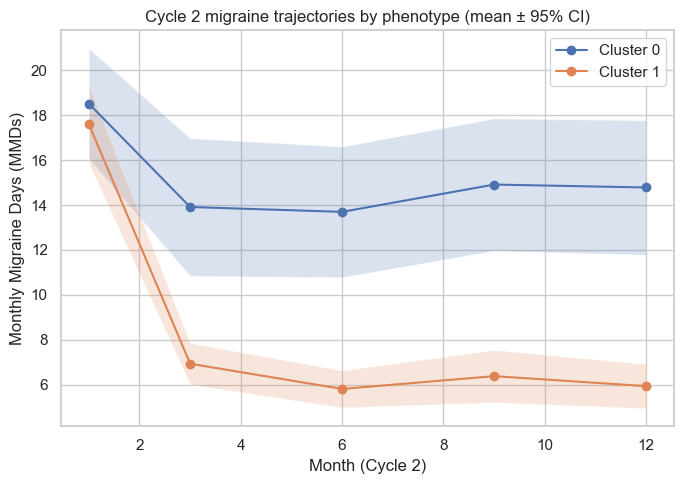

In [ ]:
# === Cycle 2: trajectory plot with 95% CI (mean ± CI) ===
traj2 = (
    t3_long_imp[t3_long_imp[CYCLE_COL] == 2]
    .merge(t3_subj_c2[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="inner")
)

plt.figure(figsize=(7, 5))

for cl in sorted(traj2["cluster_km"].dropna().unique()):
    g = traj2[traj2["cluster_km"] == cl]

    stats_df = (
        g.groupby(MONTH_COL)[MMD_COL]
        .agg(["mean", "count", "std"])
        .reset_index()
        .sort_values(MONTH_COL)
    )

    stats_df["se"] = stats_df["std"] / np.sqrt(stats_df["count"])
    stats_df["ci"] = stats_df["se"] * stats.t.ppf(0.975, stats_df["count"] - 1)

    plt.plot(stats_df[MONTH_COL], stats_df["mean"], marker="o", label=f"Cluster {int(cl)}")
    plt.fill_between(
        stats_df[MONTH_COL],
        stats_df["mean"] - stats_df["ci"],
        stats_df["mean"] + stats_df["ci"],
        alpha=0.2
    )

plt.xlabel("Month (Cycle 2)")
plt.ylabel("Monthly Migraine Days (MMDs)")
plt.title("Cycle 2 migraine trajectories by phenotype (mean ± 95% CI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === Cycle 2: responder validation (>=50% reduction) ===
c2_end = select_cycle_endpoint(t3_long_imp, cycle_id=2)

c2_end = (
    c2_end
    .merge(t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates(), on=SUBJECT_COL, how="left")
    .merge(t3_subj_c2[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="inner")
)

denom = c2_end[BASELINE_MMD_COL].replace({0: np.nan})
c2_end["responder50"] = ((c2_end[MMD_COL] / denom) <= 0.5).astype(float)

print("Cycle 2 endpoint month distribution:")
print(c2_end[MONTH_COL].value_counts().sort_index())

c2_summary = c2_end.groupby("cluster_km").agg(
    n_patients=("responder50", "count"),
    responder_rate_50=("responder50", "mean"),
    baseline_mmd_mean=(BASELINE_MMD_COL, "mean"),
    end_c2_mmd_mean=(MMD_COL, "mean")
).reset_index()

c2_summary.round(3)

Cycle 2 endpoint month distribution:
MONTH
12    79
Name: count, dtype: int64


,cluster_km,n_patients,responder_rate_50,baseline_mmd_mean,end_c2_mmd_mean
0,0,23,0.348,23.696,14.783
1,1,56,0.946,24.000,5.929


## Cycle 3: Main analysis (k = 2)


We repeat the same pipeline for Cycle 3. Because Cycle 3 has substantially fewer observed trajectories and higher dropout, results are interpreted as a replication check rather than definitive discovery of additional subtypes.

In [ ]:
# === Cycle 3: compute features ===
t3_subj_c3 = compute_cycle_features(t3_long_imp, t3_base, cycle_id=3)
print("Cycle 3 phenotyping cohort size:", t3_subj_c3[SUBJECT_COL].nunique())

cluster_features = [
    "mmd_mean_early", "mmd_mean_mid", "mmd_mean_late",
    "mmd_sd_cycle", "mmd_slope_cycle",
    "rel_change_early", "rel_change_mid", "rel_change_late"
]
cluster_features = [c for c in cluster_features if c in t3_subj_c3.columns]

X3 = t3_subj_c3[cluster_features].copy()
X3 = X3.fillna(X3.median(numeric_only=True))

scaler3 = StandardScaler()
X3z = scaler3.fit_transform(X3)

# Silhouette check
sil3 = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X3z)
    sil3.append({"k": k, "silhouette": silhouette_score(X3z, labels)})
sil3_table = pd.DataFrame(sil3).sort_values("k")
sil3_table

Cycle 3 phenotyping cohort size: 78


,k,silhouette
0,2,0.282083
1,3,0.315357
2,4,0.310496
3,5,0.316159


In [ ]:
# === Cycle 3: final clustering for comparability (k=2) ===
FINAL_K_C3 = 2

km3 = KMeans(n_clusters=FINAL_K_C3, random_state=42, n_init=50)
t3_subj_c3["cluster_km"] = km3.fit_predict(X3z)

hc3 = AgglomerativeClustering(n_clusters=FINAL_K_C3, linkage="ward")
t3_subj_c3["cluster_hc"] = hc3.fit_predict(X3z)

ari3 = adjusted_rand_score(t3_subj_c3["cluster_km"], t3_subj_c3["cluster_hc"])
print("Cycle 3 — KMeans vs Hierarchical ARI:", round(ari3, 3))
print("Cycle 3 — cluster sizes:\n", t3_subj_c3["cluster_km"].value_counts().sort_index())

Cycle 3 — KMeans vs Hierarchical ARI: 0.509
Cycle 3 — cluster sizes:
 cluster_km
0    33
1    45
Name: count, dtype: int64


In [ ]:
# === Cycle 3: cluster profile table with 95% CI ===
rows = []
for cl, g in t3_subj_c3.groupby("cluster_km"):
    row = {"cycle": 3, "cluster": int(cl), "n_patients": len(g)}

    for label, col in [
        ("early_mmd", "mmd_mean_early"),
        ("mid_mmd", "mmd_mean_mid"),
        ("late_mmd", "mmd_mean_late"),
        ("slope", "mmd_slope_cycle"),
    ]:
        m, lo, hi, n = mean_ci(g[col])
        row[f"{label}_mean"] = m
        row[f"{label}_ci_low"] = lo
        row[f"{label}_ci_high"] = hi
        row[f"{label}_n"] = n

    rows.append(row)

cluster_profile_c3 = pd.DataFrame(rows).round(2)
cluster_profile_c3

,cycle,cluster,n_patients,early_mmd_mean,early_mmd_ci_low,early_mmd_ci_high,early_mmd_n,mid_mmd_mean,mid_mmd_ci_low,mid_mmd_ci_high,mid_mmd_n,late_mmd_mean,late_mmd_ci_low,late_mmd_ci_high,late_mmd_n,slope_mean,slope_ci_low,slope_ci_high,slope_n
0,3,0,33,13.05,11.18,14.91,33,13.39,11.35,15.44,33,11.88,10.16,13.60,33,-0.17,-0.35,0.00,33
1,3,1,45,10.92,9.62,12.22,45,4.53,3.67,5.40,45,4.86,4.16,5.55,45,-0.76,-0.91,-0.61,45


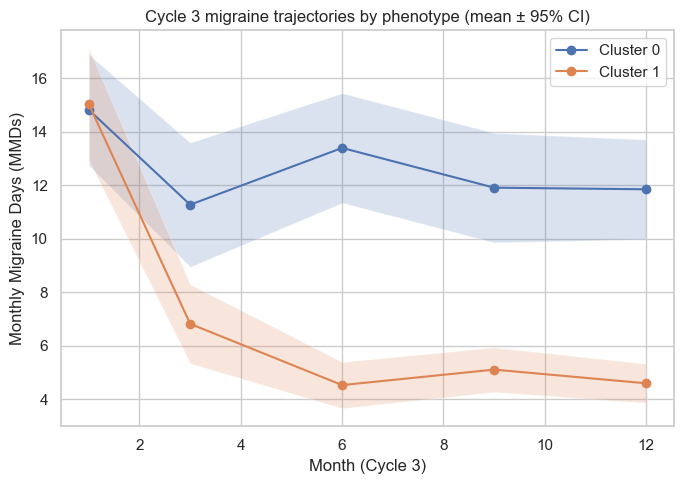

In [ ]:
# === Cycle 3: trajectory plot with 95% CI (mean ± CI) ===
traj3 = (
    t3_long_imp[t3_long_imp[CYCLE_COL] == 3]
    .merge(t3_subj_c3[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="inner")
)

plt.figure(figsize=(7, 5))

for cl in sorted(traj3["cluster_km"].dropna().unique()):
    g = traj3[traj3["cluster_km"] == cl]

    stats_df = (
        g.groupby(MONTH_COL)[MMD_COL]
        .agg(["mean", "count", "std"])
        .reset_index()
        .sort_values(MONTH_COL)
    )

    stats_df["se"] = stats_df["std"] / np.sqrt(stats_df["count"])
    stats_df["ci"] = stats_df["se"] * stats.t.ppf(0.975, stats_df["count"] - 1)

    plt.plot(stats_df[MONTH_COL], stats_df["mean"], marker="o", label=f"Cluster {int(cl)}")
    plt.fill_between(
        stats_df[MONTH_COL],
        stats_df["mean"] - stats_df["ci"],
        stats_df["mean"] + stats_df["ci"],
        alpha=0.2
    )

plt.xlabel("Month (Cycle 3)")
plt.ylabel("Monthly Migraine Days (MMDs)")
plt.title("Cycle 3 migraine trajectories by phenotype (mean ± 95% CI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === Cycle 3: responder validation (>=50% reduction) ===
c3_end = select_cycle_endpoint(t3_long_imp, cycle_id=3)

c3_end = (
    c3_end
    .merge(t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates(), on=SUBJECT_COL, how="left")
    .merge(t3_subj_c3[[SUBJECT_COL, "cluster_km"]], on=SUBJECT_COL, how="inner")
)

denom = c3_end[BASELINE_MMD_COL].replace({0: np.nan})
c3_end["responder50"] = ((c3_end[MMD_COL] / denom) <= 0.5).astype(float)

print("Cycle 3 endpoint month distribution:")
print(c3_end[MONTH_COL].value_counts().sort_index())

c3_summary = c3_end.groupby("cluster_km").agg(
    n_patients=("responder50", "count"),
    responder_rate_50=("responder50", "mean"),
    baseline_mmd_mean=(BASELINE_MMD_COL, "mean"),
    end_c3_mmd_mean=(MMD_COL, "mean")
).reset_index()

c3_summary.round(3)

Cycle 3 endpoint month distribution:
MONTH
12    78
Name: count, dtype: int64


,cluster_km,n_patients,responder_rate_50,baseline_mmd_mean,end_c3_mmd_mean
0,0,33,0.606,24.030,11.848
1,1,45,1.000,23.867,4.600


## Cycle 3: Exploratory refinement (k = 3)


This analysis is exploratory and aims to assess whether finer stratification emerges in a responder-enriched population. Due to reduced robustness and small cluster sizes, results are interpreted cautiously and do not replace the primary k = 2 solution.

In [ ]:
# === Cycle 3: secondary clustering with k = 3 ===

FINAL_K_C3_ALT = 3

km3_alt = KMeans(
    n_clusters=FINAL_K_C3_ALT,
    random_state=42,
    n_init=50
)
t3_subj_c3["cluster_km_k3"] = km3_alt.fit_predict(X3z)

hc3_alt = AgglomerativeClustering(
    n_clusters=FINAL_K_C3_ALT,
    linkage="ward"
)
t3_subj_c3["cluster_hc_k3"] = hc3_alt.fit_predict(X3z)

ari3_k3 = adjusted_rand_score(
    t3_subj_c3["cluster_km_k3"],
    t3_subj_c3["cluster_hc_k3"]
)

print("Cycle 3 (k=3) — KMeans vs Hierarchical ARI:", round(ari3_k3, 3))
print("Cycle 3 (k=3) — cluster sizes:\n",
      t3_subj_c3["cluster_km_k3"].value_counts().sort_index())


Cycle 3 (k=3) — KMeans vs Hierarchical ARI: 0.302
Cycle 3 (k=3) — cluster sizes:
 cluster_km_k3
0    49
1    18
2    11
Name: count, dtype: int64


In [ ]:
# === Cycle 3 (k=3): cluster profile table with 95% CI ===

rows = []

for cl, g in t3_subj_c3.groupby("cluster_km_k3"):
    row = {
        "cycle": 3,
        "cluster": int(cl),
        "n_patients": len(g)
    }

    for label, col in [
        ("early_mmd", "mmd_mean_early"),
        ("mid_mmd", "mmd_mean_mid"),
        ("late_mmd", "mmd_mean_late"),
        ("slope", "mmd_slope_cycle"),
    ]:
        m, lo, hi, n = mean_ci(g[col])
        row[f"{label}_mean"] = m
        row[f"{label}_ci_low"] = lo
        row[f"{label}_ci_high"] = hi
        row[f"{label}_n"] = n

    rows.append(row)

cluster_profile_c3_k3 = pd.DataFrame(rows).round(2)
cluster_profile_c3_k3

,cycle,cluster,n_patients,early_mmd_mean,early_mmd_ci_low,early_mmd_ci_high,early_mmd_n,mid_mmd_mean,mid_mmd_ci_low,mid_mmd_ci_high,mid_mmd_n,late_mmd_mean,late_mmd_ci_low,late_mmd_ci_high,late_mmd_n,slope_mean,slope_ci_low,slope_ci_high,slope_n
0,3,0,49,9.37,8.56,10.18,49,6.33,5.35,7.30,49,6.54,5.56,7.52,49,-0.38,-0.49,-0.27,49
1,3,1,18,15.47,12.59,18.35,18,16.67,13.74,19.59,18,13.22,10.22,16.23,18,-0.28,-0.58,0.02,18
2,3,2,11,16.77,15.38,18.17,11,3.27,1.71,4.84,11,4.73,3.43,6.02,11,-1.48,-1.68,-1.28,11


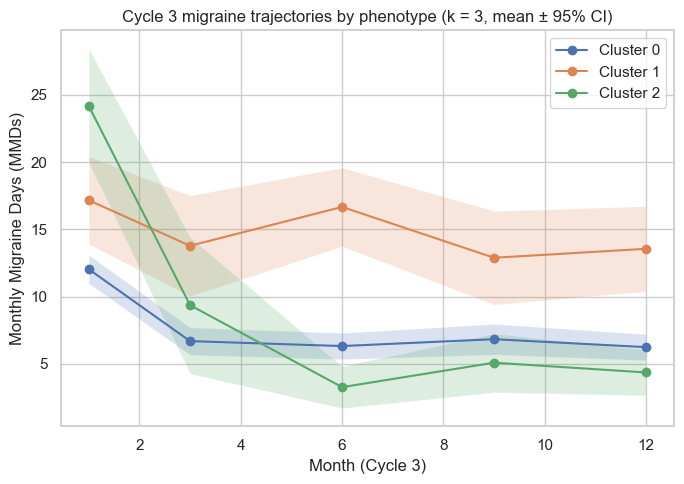

In [ ]:
# === Cycle 3 (k=3): trajectory plot with 95% CI ===

traj3_k3 = (
    t3_long_imp[t3_long_imp[CYCLE_COL] == 3]
    .merge(
        t3_subj_c3[[SUBJECT_COL, "cluster_km_k3"]],
        on=SUBJECT_COL,
        how="inner"
    )
)

plt.figure(figsize=(7, 5))

for cl in sorted(traj3_k3["cluster_km_k3"].unique()):
    g = traj3_k3[traj3_k3["cluster_km_k3"] == cl]

    stats_df = (
        g.groupby(MONTH_COL)[MMD_COL]
        .agg(["mean", "count", "std"])
        .reset_index()
        .sort_values(MONTH_COL)
    )

    stats_df["se"] = stats_df["std"] / np.sqrt(stats_df["count"])
    stats_df["ci"] = stats_df["se"] * stats.t.ppf(0.975, stats_df["count"] - 1)

    plt.plot(
        stats_df[MONTH_COL],
        stats_df["mean"],
        marker="o",
        label=f"Cluster {int(cl)}"
    )

    plt.fill_between(
        stats_df[MONTH_COL],
        stats_df["mean"] - stats_df["ci"],
        stats_df["mean"] + stats_df["ci"],
        alpha=0.2
    )

plt.xlabel("Month (Cycle 3)")
plt.ylabel("Monthly Migraine Days (MMDs)")
plt.title("Cycle 3 migraine trajectories by phenotype (k = 3, mean ± 95% CI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === Cycle 3 (k=3): responder validation (>=50% reduction) ===

c3_end_k3 = (
    select_cycle_endpoint(t3_long_imp, cycle_id=3)
    .merge(
        t3_base[[SUBJECT_COL, BASELINE_MMD_COL]].drop_duplicates(),
        on=SUBJECT_COL,
        how="left"
    )
    .merge(
        t3_subj_c3[[SUBJECT_COL, "cluster_km_k3"]],
        on=SUBJECT_COL,
        how="inner"
    )
)

denom = c3_end_k3[BASELINE_MMD_COL].replace({0: np.nan})
c3_end_k3["responder50"] = ((c3_end_k3[MMD_COL] / denom) <= 0.5).astype(float)

c3_summary_k3 = (
    c3_end_k3.groupby("cluster_km_k3")
    .agg(
        n_patients=("responder50", "count"),
        responder_rate_50=("responder50", "mean"),
        baseline_mmd_mean=(BASELINE_MMD_COL, "mean"),
        end_c3_mmd_mean=(MMD_COL, "mean")
    )
    .reset_index()
)

c3_summary_k3.round(3)

,cluster_km_k3,n_patients,responder_rate_50,baseline_mmd_mean,end_c3_mmd_mean
0,0,49,0.959,23.592,6.245
1,1,18,0.389,24.167,13.556
2,2,11,1.000,25.091,4.364


---------------------------------------------------

# ***Task 4: Survival Analysis***
by Susanna Mazzocchi

This section defines and prepares data for a competing risks survival analysis. Two events are considered:
1) Treatment response (≥50% reduction in MMDs from baseline) as the primary event,
2) Treatment discontinuation as a semi-competing risk.

Event times and indicators are computed to enable Kaplan-Meier curves, Cox models, and cumulative incidence functions accounting for competing risks.


&nbsp;


### ***Descriptive Statistics of Monthly Migraine Days (MMDs) by Cycle***

Summary of observed Monthly Migraine Days across treatment cycles. Variations in mean values reflect the clinical washout periods and attrition between cycles.

In [ ]:
baseline_by_cycle = df_long.groupby('CYCLE')['MMDs'].agg(['count', 'mean', 'std']).round(2)
baseline_by_cycle.columns = ['N Observations', 'Mean MMDs', 'SD MMDs']
display(baseline_by_cycle)

,N Observations,Mean MMDs,SD MMDs
CYCLE,,,
1,790,14.38,9.74
2,429,10.76,7.27
3,392,9.58,6.52


&nbsp;

In [ ]:
def calculate_continuous_time(row):
    cycle = int(row['CYCLE'])
    month = int(row['MONTH'])
    if cycle == 1:
        return month
    elif cycle == 2:
        return 12 + 3 + month
    elif cycle == 3:
        return 12 + 3 + 12 + 3 + month
    return month

df_long_imputed['Time_Continuous'] = df_long_imputed.apply(calculate_continuous_time, axis=1)

baseline_col = 'GGCEF_T0'
baseline_mmds_dict = df_baseline_imputed.set_index('SUBJECT_ID')[baseline_col].to_dict()

df_long_imputed['baseline_mmds'] = df_long_imputed['SUBJECT_ID'].map(baseline_mmds_dict)
df_long_imputed['response_ratio'] = df_long_imputed['MMDs'] / df_long_imputed['baseline_mmds'].replace(0, np.nan)
df_long_imputed['response_50'] = (df_long_imputed['response_ratio'] <= 0.5).astype(int)

first_response = (
    df_long_imputed[df_long_imputed['response_50'] == 1]
    .groupby('SUBJECT_ID')
    .agg(time_to_response=('Time_Continuous', 'min'))
    .reset_index()
)

cols_to_keep = ['SUBJECT_ID', 'AGE', 'SEX', 'ANTIBODY', baseline_col, 'BMI', 'Suspension']
extra_cols = ['Sleep_Disorders', 'Hypertension', 'Psycopathological', 'INT_T0']
for c in extra_cols:
    if c in df_baseline_imputed.columns:
        cols_to_keep.append(c)

df_surv = df_baseline_imputed[cols_to_keep].copy()
df_surv = df_surv.merge(first_response, on='SUBJECT_ID', how='left')

real_max_followup = df_long_imputed.groupby('SUBJECT_ID')['Time_Continuous'].max().to_dict()
df_surv['max_observed_month'] = df_surv['SUBJECT_ID'].map(real_max_followup)

def determine_survival_status(row):
    t_resp = row['time_to_response']
    t_last = row['max_observed_month']
    is_suspended = (row['Suspension'] == 1)

    if pd.notna(t_resp):
        return pd.Series([t_resp, 1])
    else:
        if is_suspended:
            return pd.Series([t_last, 2])
        else:
            return pd.Series([t_last, 0])

df_surv[['Time', 'Event_Type']] = df_surv.apply(determine_survival_status, axis=1)

df_surv['Event_KM'] = df_surv['Event_Type'].apply(lambda x: 1 if x == 1 else 0)
df_surv = df_surv.dropna(subset=['Time'])

if 'GGCEF_T0' in df_surv.columns:
    df_surv = df_surv.rename(columns={'GGCEF_T0': 'MMDs_baseline'})

df_surv_master = df_surv.copy()

print("Survival Dataset Created (df_surv_master). Event Distribution:")
print(df_surv_master['Event_Type'].value_counts().sort_index().rename({0: 'Censored', 1: 'Response', 2: 'Discontinued'}))
display(df_surv_master.head())

Survival Dataset Created (df_surv_master). Event Distribution:
Event_Type
Censored          2
Response        170
Discontinued      7
Name: count, dtype: int64


,SUBJECT_ID,AGE,SEX,ANTIBODY,MMDs_baseline,BMI,Suspension,Sleep_Disorders,Hypertension,Psycopathological,INT_T0,time_to_response,max_observed_month,Time,Event_Type,Event_KM
0,1,57.0,0.0,1.0,13.0,24.242424,0.0,0.0,0.0,3.0,6.0,3.0,42,3.0,1.0,1
1,2,51.0,1.0,1.0,25.0,20.061728,0.0,0.0,1.0,1.0,7.0,3.0,42,3.0,1.0,1
2,3,30.0,0.0,1.0,28.0,21.671258,0.0,0.0,0.0,0.0,7.0,6.0,42,6.0,1.0,1
3,4,59.0,0.0,1.0,25.0,27.734375,0.0,0.0,0.0,3.0,5.0,3.0,42,3.0,1.0,1
4,5,48.0,1.0,1.0,16.0,20.796730,0.0,0.0,0.0,5.0,6.0,6.0,42,6.0,1.0,1


&nbsp;

### ***Longitudinal trends visualization***

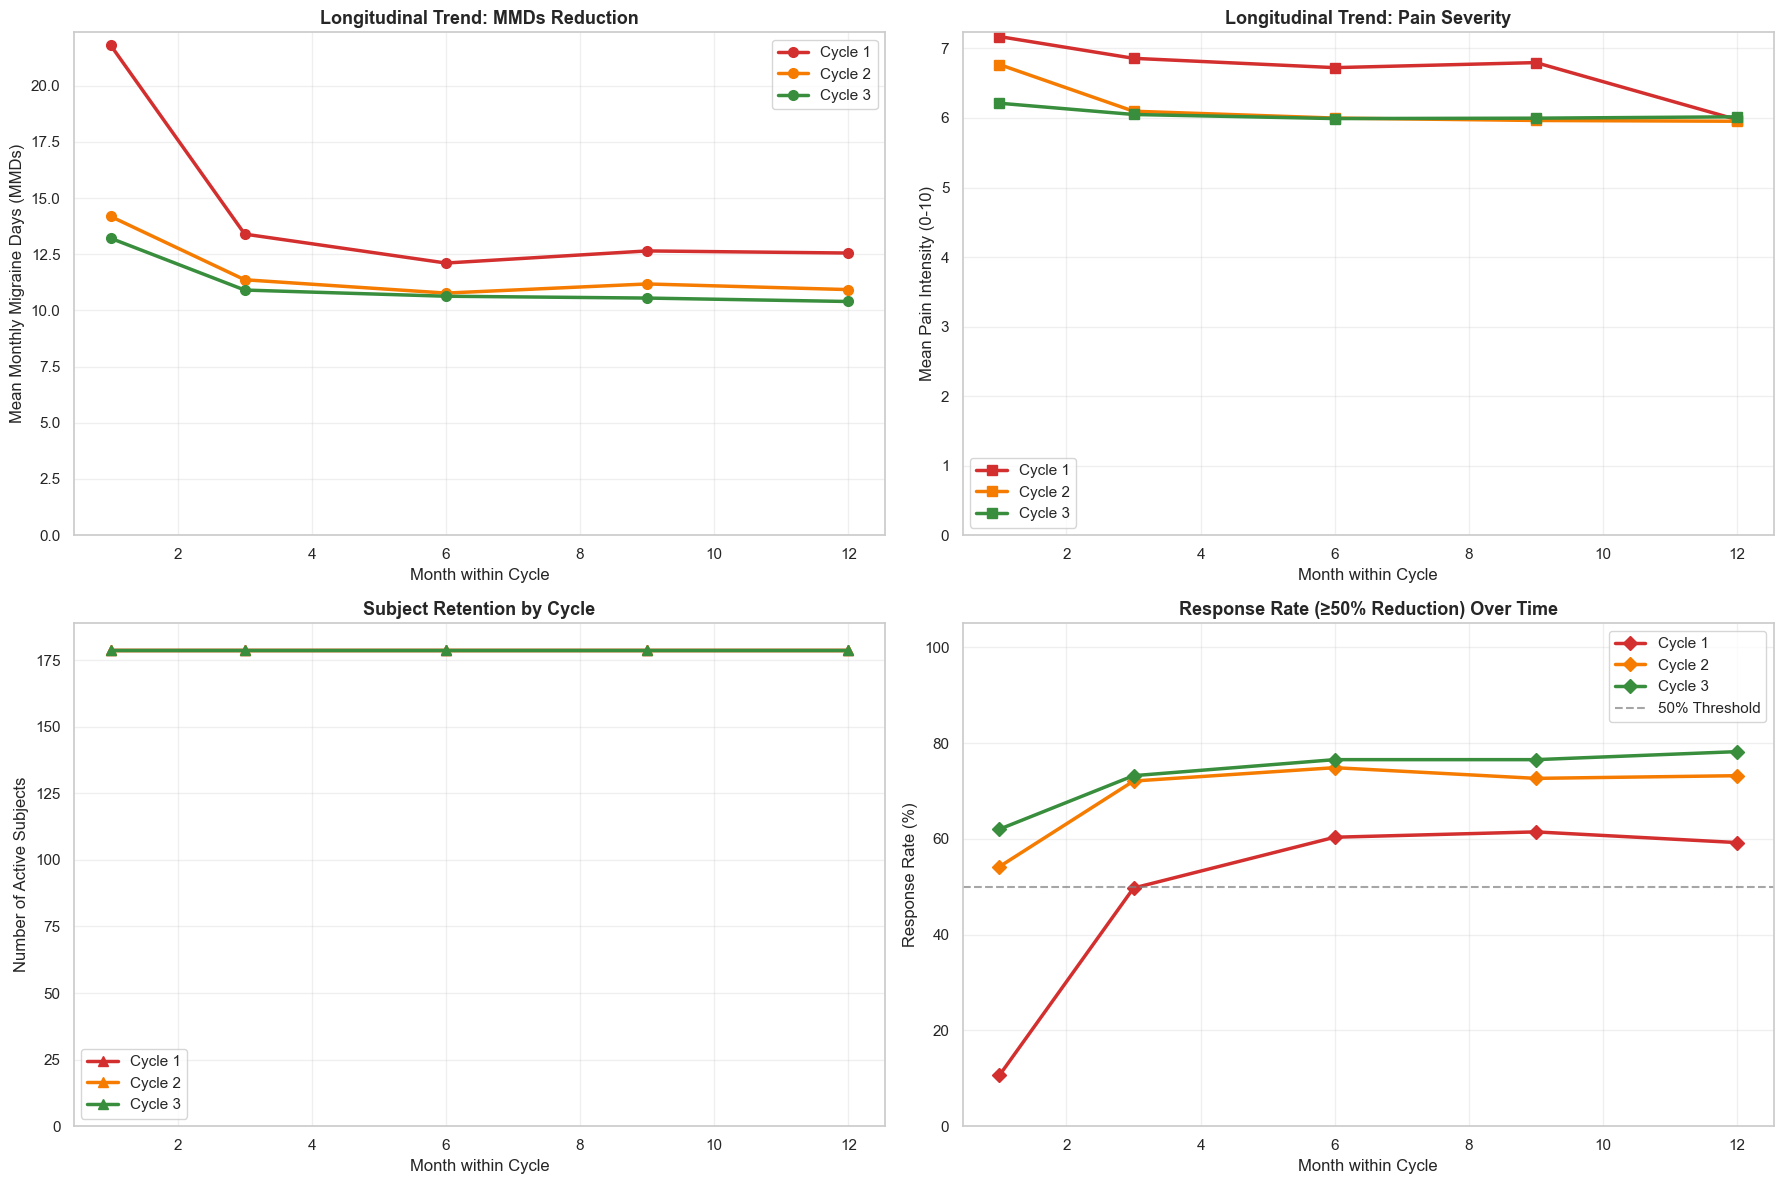

In [ ]:
if 'response_50' not in df_long_imputed.columns:
    print("Calculated 'response_50' column for plotting...")
    # Map baseline
    baseline_map = df_baseline_imputed.set_index('SUBJECT_ID')['GGCEF_T0'].to_dict()
    df_long_imputed['baseline_mmds'] = df_long_imputed['SUBJECT_ID'].map(baseline_map)
    # Calculate reduction
    df_long_imputed['response_ratio'] = df_long_imputed['MMDs'] / df_long_imputed['baseline_mmds'].replace(0, np.nan)
    df_long_imputed['response_50'] = (df_long_imputed['response_ratio'] <= 0.5).astype(int)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
cycles = sorted(df_long_imputed['CYCLE'].unique())
colors = {1: '#D32F2F', 2: '#F57C00', 3: '#388E3C'}

# PLOT 1: MMDs by cycle and month
df_mean = df_long_imputed.groupby(['CYCLE', 'MONTH']).agg({
    'MMDs': 'mean',
    'INT': 'mean',
    'SUBJECT_ID': 'count'
}).reset_index()
df_mean = df_mean[df_mean['SUBJECT_ID'] >= 5]

ax = axes[0, 0]
for cycle in cycles:
    subset = df_mean[df_mean['CYCLE'] == cycle]
    ax.plot(subset['MONTH'], subset['MMDs'], marker='o', linewidth=2.5,
            label=f'Cycle {int(cycle)}', color=colors.get(cycle, 'black'), markersize=7)

ax.set_xlabel('Month within Cycle', fontsize=12)
ax.set_ylabel('Mean Monthly Migraine Days (MMDs)', fontsize=12)
ax.set_title('Longitudinal Trend: MMDs Reduction', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# PLOT 2: Severity (INT) by cycle
ax = axes[0, 1]
for cycle in cycles:
    subset = df_mean[df_mean['CYCLE'] == cycle]
    ax.plot(subset['MONTH'], subset['INT'], marker='s', linewidth=2.5,
            label=f'Cycle {int(cycle)}', color=colors.get(cycle, 'black'), markersize=7)

ax.set_xlabel('Month within Cycle', fontsize=12)
ax.set_ylabel('Mean Pain Intensity (0-10)', fontsize=12)
ax.set_title('Longitudinal Trend: Pain Severity', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# PLOT 3: Subject Retention
retention = df_long_imputed.groupby(['CYCLE', 'MONTH'])['SUBJECT_ID'].nunique().reset_index()
ax = axes[1, 0]
for cycle in cycles:
    subset = retention[retention['CYCLE'] == cycle]
    ax.plot(subset['MONTH'], subset['SUBJECT_ID'], marker='^', linewidth=2.5,
            label=f'Cycle {int(cycle)}', color=colors.get(cycle, 'black'), markersize=7)

ax.set_xlabel('Month within Cycle', fontsize=12)
ax.set_ylabel('Number of Active Subjects', fontsize=12)
ax.set_title('Subject Retention by Cycle', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# PLOT 4: Response Rate (>50% reduction)
resp_rate = df_long_imputed.groupby(['CYCLE', 'MONTH']).apply(
    lambda x: x['response_50'].sum() / len(x) * 100 if len(x) > 0 else 0
).reset_index(name='rate')

ax = axes[1, 1]
for cycle in cycles:
    subset = resp_rate[resp_rate['CYCLE'] == cycle]
    ax.plot(subset['MONTH'], subset['rate'], marker='D', linewidth=2.5,
            label=f'Cycle {int(cycle)}', color=colors.get(cycle, 'black'), markersize=7)

ax.set_xlabel('Month within Cycle', fontsize=12)
ax.set_ylabel('Response Rate (%)', fontsize=12)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='50% Threshold')
ax.set_title('Response Rate (≥50% Reduction) Over Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('task4_longitudinal_trends_final.png', dpi=300, bbox_inches='tight')
plt.show()

&nbsp;

### ***Kaplan-Meier Analysis Stratified by Treatment Cycle***

Kaplan-Meier curves are computed for time to treatment response (≥50% MMDs reduction) and treatment continuation, stratified by treatment cycle. This allows visualization of response dynamics and discontinuation rates across different cycles, with median times and number at risk displayed for each stratum.


Erenumab        - Median Time to Response: 3.0 months
Galcanezumab    - Median Time to Response: 3.0 months
Fremanezumab    - Median Time to Response: 6.0 months


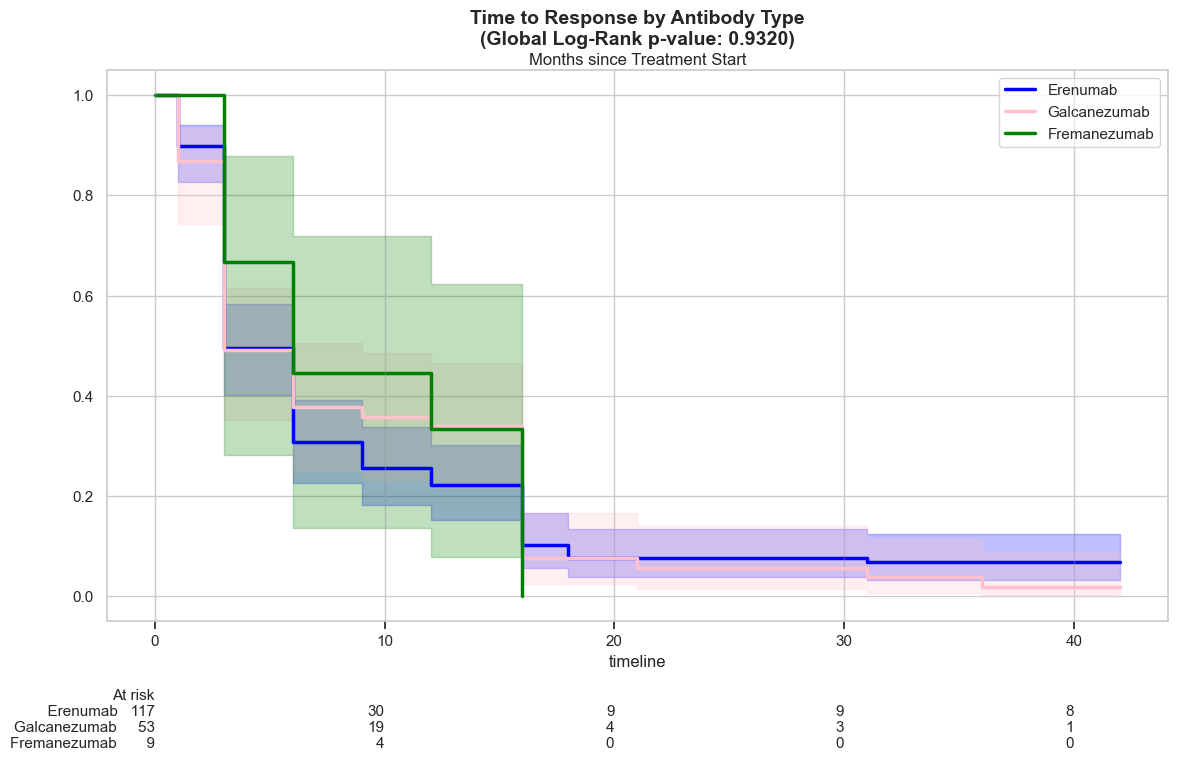


Interpretation:
Non-Significant Result (p=0.9320): All 3 antibodies show similar response speed.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
stratification_col = 'ANTIBODY'
labels = {1: 'Erenumab', 2: 'Galcanezumab', 3: 'Fremanezumab'}
colors = {1: 'blue', 2: 'pink', 3: 'green'}

km_fits = []

for group in sorted(df_surv_master[stratification_col].unique()):
    kmf = KaplanMeierFitter()

    mask = df_surv_master[stratification_col] == group
    T = df_surv_master.loc[mask, 'Time']
    E = df_surv_master.loc[mask, 'Event_KM']

    if len(T) > 0:
        label_name = labels.get(group, f'Group {group}')

        kmf.fit(T, E, label=label_name)
        kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2.5, color=colors.get(group, 'black'))
        km_fits.append(kmf)

        print(f"{label_name:<15} - Median Time to Response: {kmf.median_survival_time_} months")


add_at_risk_counts(*km_fits, ax=ax, rows_to_show=['At risk'])
results = multivariate_logrank_test(
    df_surv_master['Time'],
    df_surv_master[stratification_col],
    df_surv_master['Event_KM']
)

plt.title(f'Time to Response by Antibody Type\n(Global Log-Rank p-value: {results.p_value:.4f})',
          fontsize=14, fontweight='bold')
plt.xlabel('Months since Treatment Start', fontsize=12)
plt.ylabel('Probability of NOT Responding yet', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('task4_km_antibodies_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
if results.p_value < 0.05:
    print(f"Significant Result (p={results.p_value:.4f}): There is a statistical difference in response speed between the 3 antibodies.")
else:
    print(f"Non-Significant Result (p={results.p_value:.4f}): All 3 antibodies show similar response speed.")

This plot illustrates the survival curves for patients treated with Erenumab (blue), Galcanezumab (pink), and Fremanezumab (green), where the "event" is defined as the first occurrence of a ≥50% reduction in Monthly Migraine Days (MMDs). The vertical axis represents the probability of remaining event-free (non-response) over time.

The substantial overlap of the curves and the Global Log-Rank test result ($p = 0.9320$) indicate that there is no statistically significant difference in the time to therapeutic response among the three antibody treatments. Shaded regions represent 95% confidence intervals.

&nbsp;

### ***Log-Rank Test: Comparison of Antibody Efficacy***

A multivariate log-rank test was conducted to evaluate whether the time to achieve a $\ge 50\%$ reduction in MMDs differs significantly among the three antibody treatment groups (Erenumab, Galcanezumab, Fremanezumab).

In [ ]:
# A. Omnibus Test
global_result = multivariate_logrank_test(
    df_surv['Time'],
    df_surv['ANTIBODY'],
    df_surv['Event_KM']
)

print(f"Global Log-Rank p-value: {global_result.p_value:.4f}")

# B. Pairwise Comparison)
print("\n Pairwise Comparisons (Group vs Group) ")
pairwise_results = pairwise_logrank_test(
    df_surv['Time'],
    df_surv['ANTIBODY'],
    df_surv['Event_KM']
)
display(pairwise_results.summary)

Global Log-Rank p-value: 0.9320

 Pairwise Comparisons (Group vs Group) 


test_statistic         p  -log2(p)
1.0 2.0        0.019428  0.889146  0.169507
    3.0        0.176466  0.674428  0.568264
2.0 3.0        0.011230  0.915606  0.127201

The multivariate Log-Rank test revealed no statistically significant differences in the time to response among the three antibody groups ($p = 0.9320$).

Pairwise comparisons confirmed comparable efficacy profiles across all treatment arms (all $p > 0.05$), indicating that the therapeutic latency is similar regardless of the specific monoclonal antibody administered.

&nbsp;

### ***Cox Proportional Hazards with Confounder Adjustment***

In this section, we implement a Stratified Cox Proportional Hazards model to evaluate the impact of clinical covariates on the time to treatment response. To ensure model robustness and address potential non-linearity, continuous variables such as BMI and baseline MMDs are first transformed into categorical features (e.g., binary status and tertiles).

The regression is then stratified by ANTIBODY and Sleep_Disorders to control for baseline structural differences between groups and strictly satisfy the proportional hazards assumption. Finally, the validity of the model is confirmed through a formal statistical test of the residuals.

In [ ]:
if 'df_surv_master' in locals():
    df_cox = df_surv_master.copy()
else:
    df_cox = df_surv.copy()

rename_map = {}
if 'GGCEF_T0' in df_cox.columns:
    rename_map['GGCEF_T0'] = 'MMDs_baseline'
if 'Event_KM' in df_cox.columns:
    rename_map['Event_KM'] = 'Event_Response'
df_cox = df_cox.rename(columns=rename_map)


df_cox['Baseline_MMDs_Cat'] = pd.qcut(df_cox['MMDs_baseline'], q=3, labels=['Low', 'Medium', 'High'])
df_cox['BMI_High'] = (df_cox['BMI'] >= 25).astype(int)
df_cox['Sleep_Disorders'] = df_cox['Sleep_Disorders'].astype(int)


cols_model = ['Time', 'Event_Response', 'AGE', 'SEX', 'BMI_High', 'Baseline_MMDs_Cat',
              'INT_T0', 'ANTIBODY', 'Sleep_Disorders']
df_final = df_cox[cols_model].dropna().copy()
df_final = pd.get_dummies(df_final, columns=['Baseline_MMDs_Cat'], drop_first=True)


cph_strat = CoxPHFitter(penalizer=0.1)
strata_vars = ['ANTIBODY', 'Sleep_Disorders']

try:
    cph_strat.fit(df_final, duration_col='Time', event_col='Event_Response', strata=strata_vars)

    print("STRATIFIED COX MODEL SUMMARY:")
    display(cph_strat.summary)

    print("\n" * 3)

except Exception as e:
    print(f"Error fitting Cox model: {e}")


print("PROPORTIONAL HAZARDS ASSUMPTION TEST")

try:
    ph_results = proportional_hazard_test(cph_strat, df_final, time_transform='rank')
    display(ph_results.summary)

    ph_pvals = ph_results.summary['p'].values

    print("\nINTERPRETATION:")
    print(f"Total covariates tested: {len(ph_pvals)}")
    print(f"P-values: {ph_pvals}")


    violations = (ph_pvals < 0.05).sum()
    print(f"\nViolations (p < 0.05): {violations}/{len(ph_pvals)}")

    if violations == 0:
        print("CONCLUSION: All proportionality assumptions satisfied (p > 0.05)")
        print("   -> Cox model is VALID for these covariates")
    else:
        print(f"WARNING: {violations} covariate(s) violate PH assumption")
        violated_vars = ph_results.summary[ph_results.summary['p'] < 0.05].index.tolist()
        print(f"   -> Violated variables: {violated_vars}")


    ph_summary = pd.DataFrame({
        'Covariate': ph_results.summary.index,
        'Test_Statistic': ph_results.summary['test_statistic'].values,
        'P_Value': ph_results.summary['p'].values,
        'Assumption_Met': ['Yes' if p > 0.05 else 'No' for p in ph_results.summary['p'].values]
    })


    print("\n" * 3)

    print("\n PH ASSUMPTION SUMMARY TABLE:")
    display(ph_summary)
    ph_summary.to_csv('ph_assumption_test_results.csv', index=False)

except Exception as e:
    print(f"Error: {e}")

STRATIFIED COX MODEL SUMMARY:


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
AGE,0.010027,1.010077,0.005741,-0.001225,0.021279,0.998776,1.021507,0.0,1.746549,0.080716,3.631009
SEX,-0.076533,0.926322,0.195900,-0.460490,0.307424,0.630974,1.359917,0.0,-0.390674,0.696038,0.522762
BMI_High,-0.317254,0.728146,0.183117,-0.676156,0.041648,0.508568,1.042527,0.0,-1.732527,0.083180,3.587622
INT_T0,-0.101132,0.903814,0.064107,-0.226778,0.024515,0.797097,1.024818,0.0,-1.577552,0.114669,3.124458
Baseline_MMDs_Cat_Medium,-0.096723,0.907808,0.183059,-0.455512,0.262067,0.634123,1.299613,0.0,-0.528368,0.597244,0.743608
Baseline_MMDs_Cat_High,-0.216066,0.805682,0.195539,-0.599316,0.167184,0.549187,1.181972,0.0,-1.104975,0.269171,1.893407






PROPORTIONAL HAZARDS ASSUMPTION TEST


,test_statistic,p,-log2(p)
AGE,0.009243,0.923409,0.114958
BMI_High,1.253408,0.262902,1.927400
Baseline_MMDs_Cat_High,0.041909,0.837793,0.255334
Baseline_MMDs_Cat_Medium,0.022777,0.880038,0.184362
INT_T0,0.018185,0.892730,0.163703
SEX,0.679321,0.409821,1.286935



INTERPRETATION:
Total covariates tested: 6
P-values: [0.92340918 0.26290249 0.83779318 0.88003805 0.89273046 0.40982075]

Violations (p < 0.05): 0/6
CONCLUSION: All proportionality assumptions satisfied (p > 0.05)
   -> Cox model is VALID for these covariates





 PH ASSUMPTION SUMMARY TABLE:


,Covariate,Test_Statistic,P_Value,Assumption_Met
0,AGE,0.009243,0.923409,Yes
1,BMI_High,1.253408,0.262902,Yes
2,Baseline_MMDs_Cat_High,0.041909,0.837793,Yes
3,Baseline_MMDs_Cat_Medium,0.022777,0.880038,Yes
4,INT_T0,0.018185,0.892730,Yes
5,SEX,0.679321,0.409821,Yes


&nbsp;

### ***Cox Model-Predictive Performance Metrics***

The C-Index measures the model's discriminative ability. A value of 0.5 indicates random prediction, while values closer to 1.0 indicate better ability to distinguish between high and low risk subjects.

In [ ]:
try:
    from sksurv.metrics import concordance_index_censored

    event_array = df_final['Event_Response'].values.astype(bool)
    time_array = df_final['Time'].values
    risk_score = cph_strat.predict_partial_hazard(df_final)

    # Calculate concordance index
    c_index, _, _, _, _ = concordance_index_censored(event_array, time_array, risk_score)

    print(f"Concordance Index (C-Index): {c_index:.4f}")

except Exception as e:
    print(f"Error calculating C-Index: {e}")

Concordance Index (C-Index): 0.6014


The obtained C-Index of 0.6014 indicates that the model possesses modest discriminative ability. While it performs better than random guessing (0.5), correctly identifying the subject with the higher risk in approximately 60% of comparable pairs, this result suggests that the included covariates alone have limited power for precise individual prediction, likely due to the complex, multifactorial nature of the clinical response.

&nbsp;

### ***Forest Plots for Cox Models***

Lastly, we visualizes the results of the Cox proportional hazards models for treatment response and treatment discontinuation using forest plots. Hazard ratios (HR) with 95% confidence intervals are plotted, highlighting statistically significant predictors.

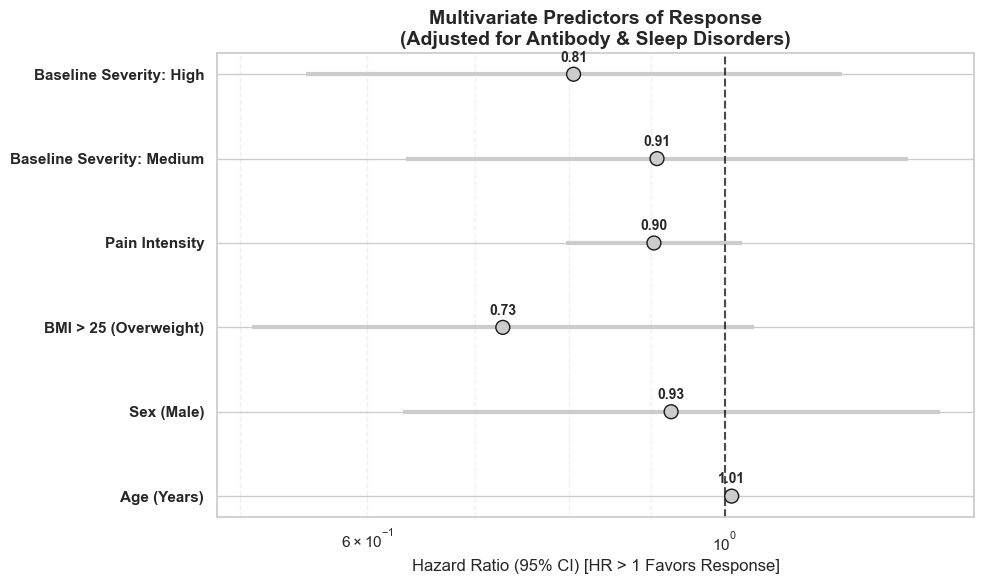

In [ ]:
plt.figure(figsize=(10, 6))

summary = cph_strat.summary

if not summary.empty:
    y_pos = np.arange(len(summary))
    hr = summary['exp(coef)']
    lower = summary['exp(coef) lower 95%']
    upper = summary['exp(coef) upper 95%']
    p_values = summary['p']

    bar_colors = ['#2ca02c' if p < 0.05 else '#cccccc' for p in p_values]

    plt.scatter(hr, y_pos, color=bar_colors, s=100, zorder=3, edgecolors='k')
    plt.hlines(y_pos, lower, upper, color=bar_colors, linewidth=3, zorder=2)
    plt.axvline(1, color='black', linestyle='--', alpha=0.7)


    clean_labels = [l.replace('Baseline_MMDs_Cat_', 'Baseline Severity: ')
                      .replace('BMI_High', 'BMI > 25 (Overweight)')
                      .replace('INT_T0', 'Pain Intensity')
                      .replace('AGE', 'Age (Years)')
                      .replace('SEX', 'Sex (Male)')
                    for l in summary.index]


    plt.yticks(y_pos, clean_labels, fontsize=11, fontweight='bold')
    plt.xlabel("Hazard Ratio (95% CI) [HR > 1 Favors Response]", fontsize=12)
    plt.title("Multivariate Predictors of Response\n(Adjusted for Antibody & Sleep Disorders)", fontsize=14, fontweight='bold')
    plt.xscale('log')
    plt.grid(True, axis='x', which='both', linestyle='--', alpha=0.3)

    for i, (val, p) in enumerate(zip(hr, p_values)):
        sig = "*" if p < 0.05 else ""
        plt.text(val, i + 0.15, f"{val:.2f}{sig}", ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('task4_final_stratified_forest_plot.png', dpi=300)
    plt.show()

This plot displays the Hazard Ratios (circles) and 95% Confidence Intervals (horizontal bars) derived from the stratified Cox proportional hazards model, adjusted for antibody type and sleep disorders.

The vertical dashed line at 1.0 represents the line of no effect (HR > 1 favors response). As observed, all confidence intervals cross the line of unity, indicating that none of the analyzed covariates—including Age, Sex, BMI, Pain Intensity, and Baseline Severity—reached statistical significance as independent predictors of treatment response in this model.

&nbsp;


### ***Competing Risks: Response vs. Discontinuation (CIF)***


We estimate the Cumulative Incidence Functions (CIF) for Response (Event 1) and Discontinuation (Event 2) using the Aalen-Johansen estimator.

Event Distribution:
Event_Type
0: Censored             2
1: Response           170
2: Discontinuation      7
Name: count, dtype: int64


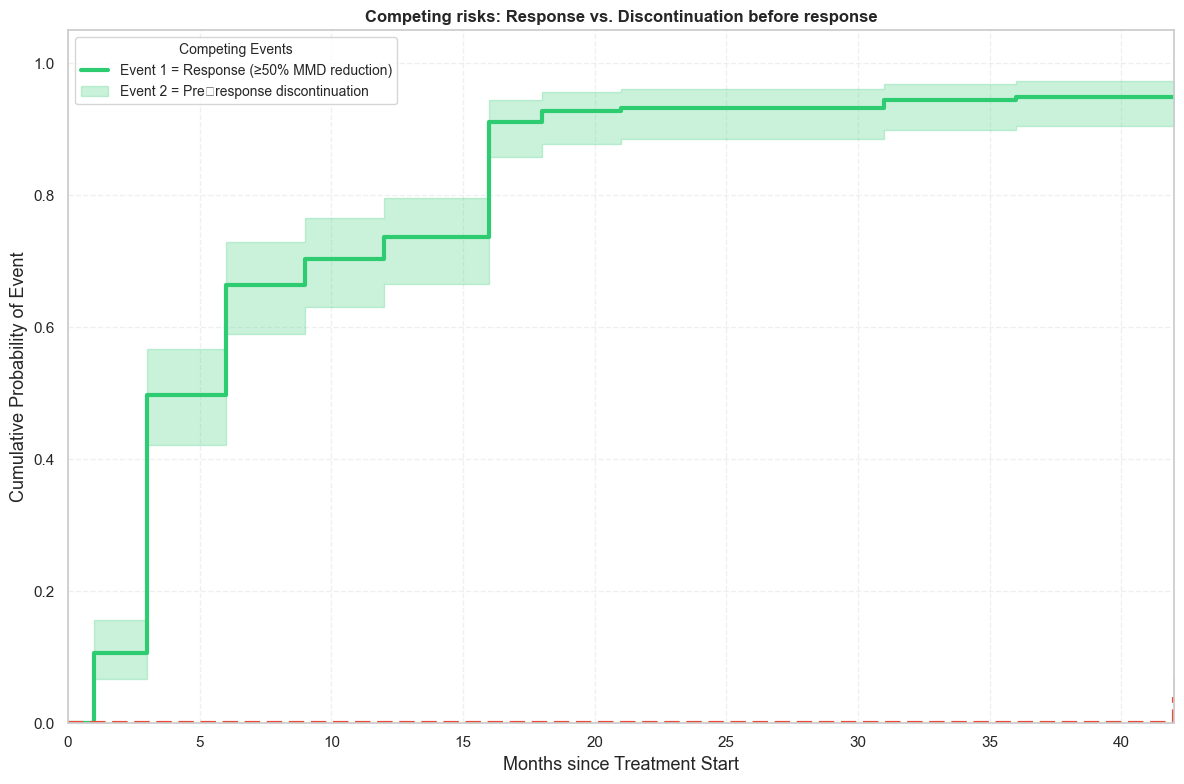

At the end of observation (42.0 months):
  - Probability of Response (Success):      95.0%
  - Probability of Discontinuation (Failure): 3.9%
  - Probability of Censoring (Ongoing/No Event): 1.1%


In [ ]:
df_competing = df_surv_master.copy()

print("Event Distribution:")
print(df_competing['Event_Type'].value_counts().sort_index().rename({0: '0: Censored', 1: '1: Response', 2: '2: Discontinuation'}))

ajf_resp = AalenJohansenFitter(calculate_variance=True)
ajf_disc = AalenJohansenFitter(calculate_variance=True)

T = df_competing['Time']
E = df_competing['Event_Type']

# Event 1: Response
ajf_resp.fit(T, E, event_of_interest=1)

# Event 2: Discontinuation (Competing Risk)
ajf_disc.fit(T, E, event_of_interest=2)


fig, ax = plt.subplots(figsize=(12, 8))
# Plot Event 1: Response
ajf_resp.plot(ax=ax, label='Probability of Response (Event 1)', color='#2ECC71', linewidth=3)

# Plot Event 2: Discontinuation
ajf_disc.plot(ax=ax, label='Probability of Dropout w/o Response (Event 2)', color='#E74C3C', linewidth=3, linestyle='--')

ax.set_title('Competing risks: Response vs. Discontinuation before response', fontsize=12, fontweight='bold')
ax.set_xlabel('Months since Treatment Start', fontsize=13)
ax.set_ylabel('Cumulative Probability of Event', fontsize=13)
ax.legend(['Event 1 = Response (≥50% MMD reduction)',
           'Event 2 = Pre‑response discontinuation'],
          title='Competing Events', fontsize=10, title_fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, df_competing['Time'].max())

plt.tight_layout()
plt.savefig('task4_cif_competing_risks.png', dpi=300)
plt.show()

final_prob_resp = ajf_resp.cumulative_density_.iloc[-1, 0]
final_prob_disc = ajf_disc.cumulative_density_.iloc[-1, 0]

print(f"At the end of observation ({df_competing['Time'].max()} months):")
print(f"  - Probability of Response (Success):      {final_prob_resp:.1%}")
print(f"  - Probability of Discontinuation (Failure): {final_prob_disc:.1%}")
print(f"  - Probability of Censoring (Ongoing/No Event): {1 - final_prob_resp - final_prob_disc:.1%}")

The plot illustrates the competing risks dynamics: the probability of achieving a clinical response (Green solid line) increases rapidly, reaching >90% probability within the first 6-12 months.

At the end of the 42-month observation period, the final cumulative incidence of Response (Success) reached 95.0%, while the cumulative incidence of Discontinuation (Failure) was limited to 3.9% (with 1.1% censored observations).

------------------------------------------